# A–D Ablation: MobileNetV1 + Fourier/Image-Conditioned INR

Six-class, patient-level 10-fold experiment using **identical outer and inner patient folds** for all four models:

- **A:** MobileNetV1 baseline
- **B:** MobileNetV1 + coordinate-only Fourier-INR + concatenation fusion
- **C:** MobileNetV1 + image-conditioned Fourier-INR + concatenation fusion
- **D:** MobileNetV1 + image-conditioned Fourier-INR + cross-attention (**full proposed model**)

The fixed `test` folder is excluded from cross-validation and used once for final evaluation.


In [1]:
# =====================================================================
# PART 1 — SETUP, PATHS, MANIFESTS AND PATIENT GROUPS
# =====================================================================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gc, re, json, time
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import backend as K
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import t

K.clear_session()
gc.collect()

# ------------------------------ configuration ------------------------------
IMG_SIZE = 128
NUM_CLASSES = 6
EMBED_DIM = 128
FOURIER_B = 6
BATCH_SIZE = 4
EPOCHS = 50
PATIENCE = 15
LEARNING_RATE = 1e-4
SEED = 42
N_SPLITS = 10
INFERENCE_REPEATS = 3

np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_ROOT = Path(r"C:\Users\viraj\Downloads\patientsplit801010")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"
RESULTS_DIR = Path(r"D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results")
FOLD_DIR = RESULTS_DIR / "folds"
FINAL_DIR = RESULTS_DIR / "final_model"
for directory in (RESULTS_DIR, FOLD_DIR, FINAL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

class_names = ["Abdomen", "Brain", "Femur", "Maternal Cervix", "Thorax", "Other"]
CLASS_ALIASES = {
    "abdomen": "Abdomen",
    "fetal abdomen": "Abdomen",

    "brain": "Brain",
    "fetal brain": "Brain",

    "femur": "Femur",
    "fetal femur": "Femur",

    "maternal cervix": "Maternal Cervix",
    "maternalcervix": "Maternal Cervix",

    "thorax": "Thorax",
    "fetal thorax": "Thorax",

    "other": "Other"
}
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def normalise_name(name):
    return re.sub(r"[ _-]+", " ", name.strip().lower())

def resolve_class_folder(split_dir, canonical_name):
    target = normalise_name(canonical_name)
    for entry in split_dir.iterdir():
        if entry.is_dir() and normalise_name(entry.name) == target:
            return entry
        if entry.is_dir() and CLASS_ALIASES.get(normalise_name(entry.name)) == canonical_name:
            return entry
    raise FileNotFoundError(f"Class folder '{canonical_name}' not found in {split_dir}")

def extract_patient_id(path):
    """Extract a stable patient group from common fetal-ultrasound filenames."""
    stem = Path(path).stem.lower()
    patterns = [
        r"(patient[_-]?\d+)", r"(patient[_-]?[a-z0-9]+)",
        r"(subject[_-]?\d+)", r"(case[_-]?\d+)"
    ]
    for pattern in patterns:
        match = re.search(pattern, stem)
        if match:
            return re.sub(r"[_-]", "", match.group(1))
    # Typical example: patient00001_plane1_1_of_15.png
    prefix = re.split(r"[_-](?:plane|frame|image|img|view|slice)[_-]?", stem, maxsplit=1)[0]
    if prefix and prefix != stem:
        return prefix
    raise ValueError(
        f"Cannot extract patient ID from '{Path(path).name}'. "
        "Edit extract_patient_id() for your filename convention before training."
    )

def build_manifest(split_name, split_dir):
    rows = []
    for label, cname in enumerate(class_names):
        folder = resolve_class_folder(split_dir, cname)
        files = sorted(p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
        if not files:
            raise ValueError(f"No images found for {cname} in {folder}")
        for path in files:
            rows.append({"split": split_name, "path": str(path), "label": label,
                         "class_name": cname, "patient_id": extract_patient_id(path)})
    return pd.DataFrame(rows)

train_df = build_manifest("train", TRAIN_DIR)
val_df = build_manifest("val", VAL_DIR)
test_df = build_manifest("test", TEST_DIR)
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
all_df.to_csv(RESULTS_DIR / "Dataset_Manifest_with_Patient_IDs.csv", index=False)

def patient_set(frame):
    return set(frame["patient_id"].astype(str))

overlap_tv = patient_set(train_df) & patient_set(val_df)
overlap_tt = patient_set(train_df) & patient_set(test_df)
overlap_vt = patient_set(val_df) & patient_set(test_df)
if overlap_tv or overlap_tt or overlap_vt:
    raise RuntimeError(
        "PATIENT LEAKAGE DETECTED in fixed folders: "
        f"train-val={len(overlap_tv)}, train-test={len(overlap_tt)}, val-test={len(overlap_vt)}"
    )

distribution_df = all_df.groupby(["class_name", "split"]).size().unstack(fill_value=0).reindex(class_names)
distribution_df["Total"] = distribution_df.sum(axis=1)
distribution_df.to_csv(RESULTS_DIR / "Classwise_Distribution.csv")

development_df = pd.concat([train_df, val_df], ignore_index=True)
if development_df["patient_id"].nunique() < N_SPLITS:
    raise ValueError(f"Need at least {N_SPLITS} distinct patients for {N_SPLITS}-fold CV.")

def get_coords(height, width):
    xs = np.linspace(-1, 1, width, dtype=np.float32)
    ys = np.linspace(-1, 1, height, dtype=np.float32)
    xx, yy = np.meshgrid(xs, ys)
    return np.stack([xx, yy], axis=-1).astype(np.float32)

coords = get_coords(IMG_SIZE, IMG_SIZE)
AUTOTUNE = tf.data.AUTOTUNE

def decode_record(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    coord_tensor = tf.constant(coords, dtype=tf.float32)
    target = tf.one_hot(label, NUM_CLASSES)
    return {"image_input": image, "coord_input": coord_tensor}, target

def make_dataset(frame, training=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((frame["path"].values, frame["label"].values.astype(np.int32)))
    if training:
        ds = ds.shuffle(min(len(frame), 10000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_record, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

print("Data root:", DATA_ROOT)
print("Results :", RESULTS_DIR)
print("Train/Val/Test images:", len(train_df), len(val_df), len(test_df))
print("Train/Val/Test patients:", train_df.patient_id.nunique(), val_df.patient_id.nunique(), test_df.patient_id.nunique())
print("Patient leakage: 0")
print(distribution_df)


Data root: C:\Users\viraj\Downloads\patientsplit801010
Results : D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results
Train/Val/Test images: 10203 1062 1135
Train/Val/Test patients: 1433 179 180
Patient leakage: 0
split            test  train  val  Total
class_name                              
Abdomen            62    587   62    711
Brain             315   2505  272   3092
Femur              82    861   97   1040
Maternal Cervix   168   1293  165   1626
Thorax            155   1409  154   1718
Other             353   3548  312   4213


## Part 2 — Consistent A–D model factory

All variants use the same MobileNetV1 backbone, 128-dimensional CNN projection, classifier head, initialization policy and training settings. Models B and C use the same concatenation-plus-1×1-projection fusion, ensuring that B→C isolates image conditioning. Models C and D use identical image-conditioned INR branches, ensuring that C→D isolates cross-attention.


In [2]:
# =====================================================================
# PART 2 — SERIALIZABLE LAYERS AND CONSISTENT A–D MODEL FACTORY
# =====================================================================
from tensorflow.keras import layers, models, regularizers

MODEL_LABELS = {
    "A": "MobileNetV1 baseline",
    "B": "MobileNetV1 + coordinate-only Fourier-INR",
    "C": "MobileNetV1 + image-conditioned Fourier-INR",
    "D": "MobileNetV1 + image-conditioned Fourier-INR + cross-attention (proposed)"
}

class FourierLayer(tf.keras.layers.Layer):
    def __init__(self, B=6, **kwargs):
        super().__init__(**kwargs); self.B = B
    def call(self, p):
        features = [p]
        for i in range(self.B):
            features.extend([tf.sin((2 ** i) * np.pi * p), tf.cos((2 ** i) * np.pi * p)])
        return tf.concat(features, axis=-1)
    def get_config(self):
        return {**super().get_config(), "B": self.B}

class BroadcastLatent(tf.keras.layers.Layer):
    def __init__(self, height, width, **kwargs):
        super().__init__(**kwargs); self.height, self.width = height, width
    def call(self, z):
        z = tf.reshape(z, [-1, 1, 1, tf.shape(z)[-1]])
        return tf.tile(z, [1, self.height, self.width, 1])
    def get_config(self):
        return {**super().get_config(), "height": self.height, "width": self.width}

class CrossAttention(tf.keras.layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs); self.dim = dim
        self.query, self.key, self.value = layers.Dense(dim), layers.Dense(dim), layers.Dense(dim)
    def call(self, inputs):
        q, kv = inputs
        q, k, v = self.query(q), self.key(kv), self.value(kv)
        scores = tf.matmul(q, k, transpose_b=True) / tf.sqrt(tf.cast(self.dim, tf.float32))
        return tf.matmul(tf.nn.softmax(scores, axis=-1), v)
    def get_config(self):
        return {**super().get_config(), "dim": self.dim}

class ZeroFromCoordinates(tf.keras.layers.Layer):
    def call(self, p):
        return tf.reduce_sum(p, axis=[1, 2, 3], keepdims=True) * 0.0

class AddZero(tf.keras.layers.Layer):
    def call(self, inputs):
        feature_map, zero = inputs
        return feature_map + zero

def classifier_head(feature_map, prefix):
    x = layers.GlobalAveragePooling2D(name=f"{prefix}_gap")(feature_map)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4),
                     name=f"{prefix}_dense256")(x)
    x = layers.BatchNormalization(name=f"{prefix}_bn")(x)
    x = layers.Dropout(0.5, name=f"{prefix}_dropout")(x)
    return layers.Dense(NUM_CLASSES, activation="softmax", name="classification")(x)

def build_model(model_key):
    if model_key not in MODEL_LABELS:
        raise ValueError(f"Unknown model key: {model_key}")

    image_input = layers.Input((IMG_SIZE, IMG_SIZE, 1), name="image_input")
    coord_input = layers.Input((IMG_SIZE, IMG_SIZE, 2), name="coord_input")
    rgb = layers.Concatenate(name="channel_expansion")([image_input] * 3)
    backbone = tf.keras.applications.MobileNet(include_top=False, weights="imagenet", input_tensor=rgb)
    for layer in backbone.layers[:100]:
        layer.trainable = False
    cnn_raw = backbone.output
    cnn_map = layers.Conv2D(EMBED_DIM, 1, padding="same", kernel_regularizer=regularizers.l2(1e-4),
                            name="cnn_projection")(cnn_raw)
    H, W = int(cnn_map.shape[1]), int(cnn_map.shape[2])

    # A: MobileNetV1 baseline. coord_input is connected through a zero-valued
    # scalar so every model keeps the same two-input dataset interface.
    if model_key == "A":
        zero = ZeroFromCoordinates(name="unused_coordinate_zero")(coord_input)
        feature_map = AddZero(name="baseline_coordinate_link")([cnn_map, zero])
        output = classifier_head(feature_map, "baseline")
    else:
        fourier = FourierLayer(FOURIER_B, name="fourier_encoding")(coord_input)
        inr_input = fourier

        # C and D: z(I) conditions every Fourier coordinate.
        if model_key in ("C", "D"):
            z = layers.GlobalAveragePooling2D(name="conditioning_gap")(cnn_raw)
            z = layers.Dense(EMBED_DIM, activation="relu", name="image_latent_z")(z)
            z_map = BroadcastLatent(IMG_SIZE, IMG_SIZE, name="latent_broadcast")(z)
            inr_input = layers.Concatenate(name="conditioned_fourier_concat")([fourier, z_map])

        x = layers.Conv2D(64, 1, activation="relu", kernel_regularizer=regularizers.l2(1e-4),
                          name="inr_conv1")(inr_input)
        x = layers.Dropout(0.3, name="inr_dropout")(x)
        x = layers.Conv2D(64, 1, activation="relu", kernel_regularizer=regularizers.l2(1e-4),
                          name="inr_conv2")(x)
        inr_map = layers.Conv2D(EMBED_DIM, 1, activation="relu", name="inr_projection")(x)
        inr_map = layers.Resizing(H, W, name="inr_resize")(inr_map)

        # B/C: identical simple fusion; only image conditioning differs.
        if model_key in ("B", "C"):
            fused = layers.Concatenate(name="simple_concat_fusion")([cnn_map, inr_map])
            fused = layers.Conv2D(EMBED_DIM, 1, activation="relu",
                                  kernel_regularizer=regularizers.l2(1e-4),
                                  name="fusion_projection")(fused)
        # D: same branches as C, with cross-attention replacing simple fusion.
        else:
            tokens = H * W
            q = layers.Reshape((tokens, EMBED_DIM), name="cnn_query_tokens")(cnn_map)
            kv = layers.Reshape((tokens, EMBED_DIM), name="inr_key_value_tokens")(inr_map)
            attended = CrossAttention(EMBED_DIM, name="cross_attention")([q, kv])
            fused = layers.Reshape((H, W, EMBED_DIM), name="attention_feature_map")(attended)
        output = classifier_head(fused, f"model_{model_key}")

    model = models.Model([image_input, coord_input], output, name=f"Model_{model_key}")
    model.compile(tf.keras.optimizers.Adam(LEARNING_RATE), "categorical_crossentropy", metrics=["accuracy"])
    return model

architecture_rows = []
for key in MODEL_LABELS:
    K.clear_session()
    m = build_model(key)
    architecture_rows.append({"Key": key, "Model": MODEL_LABELS[key], "Parameters": m.count_params(),
                              "Trainable Parameters": sum(K.count_params(w) for w in m.trainable_weights)})
architecture_df = pd.DataFrame(architecture_rows)
architecture_df.to_csv(RESULTS_DIR / "ABCD_Architecture_Parameters.csv", index=False)
print(architecture_df.to_string(index=False))
del m
K.clear_session(); gc.collect()


Key                                                                    Model  Parameters  Trainable Parameters
  A                                                     MobileNetV1 baseline     3395654                166278
  B                                MobileNetV1 + coordinate-only Fourier-INR     3442758                213382
  C                              MobileNetV1 + image-conditioned Fourier-INR     3582150                352774
  D MobileNetV1 + image-conditioned Fourier-INR + cross-attention (proposed)     3598790                369414


25883

## Part 3 — Shared patient-level 10-fold plan and A–D training

Outer and inner patient-group assignments are generated once and reused unchanged for Models A–D. This makes every fold-wise metric a paired observation suitable for statistical comparison.


In [3]:
# =====================================================================
# PART 3 — IDENTICAL PATIENT FOLDS, A–D TRAINING AND TIMING
# =====================================================================
class EpochTimer(tf.keras.callbacks.Callback):
    def __init__(self, model_key, fold):
        super().__init__(); self.model_key, self.fold, self.rows = model_key, fold, []
    def on_epoch_begin(self, epoch, logs=None): self.start = time.perf_counter()
    def on_epoch_end(self, epoch, logs=None):
        row = {"Model Key": self.model_key, "Fold": self.fold, "Epoch": epoch+1,
               "Epoch Time (s)": time.perf_counter()-self.start}
        row.update({k: float(v) for k,v in (logs or {}).items()}); self.rows.append(row)

def class_weights(labels):
    classes = np.arange(NUM_CLASSES)
    if len(np.unique(labels)) != NUM_CLASSES: raise ValueError("A fold is missing one or more classes.")
    values = compute_class_weight("balanced", classes=classes, y=labels)
    return {int(k): float(v) for k,v in zip(classes, values)}

def metrics_dict(y, pred):
    return {"Accuracy": accuracy_score(y,pred),
            "Macro Precision": precision_score(y,pred,average="macro",zero_division=0),
            "Macro Recall": recall_score(y,pred,average="macro",zero_division=0),
            "Macro F1": f1_score(y,pred,average="macro",zero_division=0),
            "Kappa": cohen_kappa_score(y,pred), "MCC": matthews_corrcoef(y,pred)}

def timed_predict(model, dataset, n):
    _ = model.predict(dataset.take(1), verbose=0)
    elapsed, probabilities = [], None
    for _ in range(INFERENCE_REPEATS):
        start = time.perf_counter(); probabilities = model.predict(dataset, verbose=0)
        elapsed.append(time.perf_counter()-start)
    mean_total = float(np.mean(elapsed))
    return probabilities, mean_total, mean_total*1000.0/n

# Generate and save every patient assignment once.
outer = StratifiedGroupKFold(N_SPLITS, shuffle=True, random_state=SEED)
fold_plan, assignment_rows = [], []
for fold, (outer_train_idx, outer_test_idx) in enumerate(
    outer.split(development_df.path, development_df.label, development_df.patient_id), 1
):
    outer_train = development_df.iloc[outer_train_idx].reset_index(drop=True)
    outer_test = development_df.iloc[outer_test_idx].reset_index(drop=True)
    inner = StratifiedGroupKFold(10, shuffle=True, random_state=SEED+fold)
    fit_idx, stop_idx = next(inner.split(outer_train.path, outer_train.label, outer_train.patient_id))
    fit_df = outer_train.iloc[fit_idx].reset_index(drop=True)
    stop_df = outer_train.iloc[stop_idx].reset_index(drop=True)
    assert not(patient_set(fit_df)&patient_set(stop_df))
    assert not(patient_set(outer_train)&patient_set(outer_test))
    fold_plan.append((fit_df, stop_df, outer_test))
    for role, frame in (("fit",fit_df),("inner_validation",stop_df),("outer_test",outer_test)):
        for patient in sorted(frame.patient_id.unique()):
            assignment_rows.append({"Fold":fold,"Role":role,"Patient ID":patient})
pd.DataFrame(assignment_rows).to_csv(RESULTS_DIR/"Shared_Patient_Fold_Assignments.csv",index=False)

fold_rows, epoch_rows = [], []
for key, label in MODEL_LABELS.items():
    model_dir = FOLD_DIR / f"Model_{key}"; model_dir.mkdir(parents=True,exist_ok=True)
    for fold, (fit_df, stop_df, outer_test_df) in enumerate(fold_plan,1):
        tf.keras.utils.set_random_seed(SEED + fold)  # same initialization seed position across variants
        K.clear_session(); gc.collect()
        model = build_model(key)
        timer = EpochTimer(key,fold)
        best = model_dir/f"Fold_{fold:02d}_Best.weights.h5"
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=PATIENCE,restore_best_weights=True),
                   tf.keras.callbacks.ModelCheckpoint(str(best),monitor="val_loss",save_best_only=True,save_weights_only=True),
                   tf.keras.callbacks.CSVLogger(str(model_dir/f"Fold_{fold:02d}_History.csv")),timer]
        train_ds, val_ds, test_ds = make_dataset(fit_df,True), make_dataset(stop_df), make_dataset(outer_test_df)
        print(f"\nMODEL {key} — {label} — FOLD {fold}/{N_SPLITS}")
        start=time.perf_counter()
        model.fit(train_ds,validation_data=val_ds,epochs=EPOCHS,class_weight=class_weights(fit_df.label.values),
                  callbacks=callbacks,verbose=1)
        training_seconds=time.perf_counter()-start
        probs, inference_total, ms_image=timed_predict(model,test_ds,len(outer_test_df))
        pred=probs.argmax(1); row=metrics_dict(outer_test_df.label.values,pred)
        row.update({"Model Key":key,"Model":label,"Fold":fold,"Epochs Run":len(timer.rows),
                    "Training Time (s)":training_seconds,
                    "Mean Epoch Time (s)":np.mean([r["Epoch Time (s)"] for r in timer.rows]),
                    "Inference Total (s)":inference_total,"Inference (ms/image)":ms_image,
                    "Outer Test Images":len(outer_test_df),"Outer Test Patients":outer_test_df.patient_id.nunique()})
        fold_rows.append(row); epoch_rows.extend(timer.rows)
        pd.DataFrame(confusion_matrix(outer_test_df.label,pred),index=class_names,columns=class_names).to_csv(
            model_dir/f"Fold_{fold:02d}_Confusion_Matrix.csv")
        del model,train_ds,val_ds,test_ds; K.clear_session(); gc.collect()

all_fold_results=pd.DataFrame(fold_rows)
all_epoch_timings=pd.DataFrame(epoch_rows)
all_fold_results.to_csv(RESULTS_DIR/"ABCD_10Fold_All_Results.csv",index=False)
all_epoch_timings.to_csv(RESULTS_DIR/"ABCD_All_Epoch_Timings.csv",index=False)
print(all_fold_results.to_string(index=False))



MODEL A — MobileNetV1 baseline — FOLD 1/10
Epoch 1/50
2300/2300 [==============================] - 50s 14ms/step - loss: 1.2432 - accuracy: 0.5758 - val_loss: 0.6074 - val_accuracy: 0.8263
Epoch 2/50
2300/2300 [==============================] - 32s 14ms/step - loss: 0.7868 - accuracy: 0.7086 - val_loss: 0.5675 - val_accuracy: 0.8469
Epoch 3/50
2300/2300 [==============================] - 31s 14ms/step - loss: 0.6754 - accuracy: 0.7517 - val_loss: 0.5173 - val_accuracy: 0.8542
Epoch 4/50
2300/2300 [==============================] - 32s 14ms/step - loss: 0.6205 - accuracy: 0.7671 - val_loss: 0.4385 - val_accuracy: 0.8862
Epoch 5/50
1511/2300 [==================>...........] - ETA: 9s - loss: 0.5815 - accuracy: 0.7886


KeyboardInterrupt



## Part 4 — Publication table and paired statistical analysis


In [ ]:
# =====================================================================
# PART 4 — MEAN±SD TABLE, FRIEDMAN TEST AND HOLM-CORRECTED PAIRS
# =====================================================================
from scipy.stats import friedmanchisquare, wilcoxon

def holm_adjust(p_values):
    """Holm family-wise correction without an optional external dependency."""
    p_values=np.asarray(p_values,dtype=float);m=len(p_values);order=np.argsort(p_values)
    adjusted=np.empty(m,dtype=float);running=0.0
    for rank,index in enumerate(order):
        running=max(running,(m-rank)*p_values[index]);adjusted[index]=min(running,1.0)
    return adjusted

METRICS=["Accuracy","Macro Precision","Macro Recall","Macro F1","Kappa","MCC"]
summary=[]
for key,label in MODEL_LABELS.items():
    part=all_fold_results[all_fold_results["Model Key"]==key].sort_values("Fold")
    row={"Model":label}
    for metric in METRICS:
        mean,sd=part[metric].mean(),part[metric].std(ddof=1)
        row[metric]=f"{mean*100:.2f} ± {sd*100:.2f}"
    row["Epoch Time (s)"]=f"{part['Mean Epoch Time (s)'].mean():.2f} ± {part['Mean Epoch Time (s)'].std(ddof=1):.2f}"
    row["Inference (ms/image)"]=f"{part['Inference (ms/image)'].mean():.3f} ± {part['Inference (ms/image)'].std(ddof=1):.3f}"
    summary.append(row)
publication_table=pd.DataFrame(summary)
publication_table.to_csv(RESULTS_DIR/"ABCD_Publication_Mean_SD_Table.csv",index=False)

friedman_rows=[]; pair_rows=[]
important_pairs=[("A","D","Overall proposed-model contribution"),
                 ("B","C","Image-conditioning contribution"),
                 ("C","D","Cross-attention contribution")]
for metric in METRICS:
    arrays=[all_fold_results[all_fold_results["Model Key"]==k].sort_values("Fold")[metric].values
            for k in MODEL_LABELS]
    stat,p=friedmanchisquare(*arrays)
    friedman_rows.append({"Metric":metric,"Friedman statistic":stat,"p-value":p})
    raw=[]; temporary=[]
    for a,b,purpose in important_pairs:
        av=all_fold_results[all_fold_results["Model Key"]==a].sort_values("Fold")[metric].values
        bv=all_fold_results[all_fold_results["Model Key"]==b].sort_values("Fold")[metric].values
        try: w,pair_p=wilcoxon(av,bv,alternative="two-sided")
        except ValueError: w,pair_p=0.0,1.0
        raw.append(pair_p); temporary.append([metric,f"{a} vs {b}",purpose,w,pair_p])
    adjusted=holm_adjust(raw)
    for item,adj in zip(temporary,adjusted):
        pair_rows.append({"Metric":item[0],"Comparison":item[1],"Purpose":item[2],
                          "Wilcoxon statistic":item[3],"Raw p-value":item[4],
                          "Holm-adjusted p-value":adj,"Significant (0.05)":bool(adj<0.05)})
pd.DataFrame(friedman_rows).to_csv(RESULTS_DIR/"ABCD_Friedman_Tests.csv",index=False)
pd.DataFrame(pair_rows).to_csv(RESULTS_DIR/"ABCD_Holm_Paired_Comparisons.csv",index=False)
print(publication_table.to_string(index=False))


## Part 5 — Final A–D models and untouched test evaluation

Each final model is trained on the fixed patient-level `train` folder, selected on the fixed `val` folder, saved, and evaluated once on the untouched `test` folder.


In [ ]:
# =====================================================================
# PART 5 — TRAIN, SAVE AND TEST FINAL MODEL A, B, C AND D
# =====================================================================
final_rows=[]
for key,label in MODEL_LABELS.items():
    tf.keras.utils.set_random_seed(SEED)
    K.clear_session();gc.collect()
    model=build_model(key)
    out=FINAL_DIR/f"Model_{key}";out.mkdir(parents=True,exist_ok=True)
    timer=EpochTimer(key,"Final")
    weights=out/f"Final_Model_{key}_Best.weights.h5"
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=PATIENCE,restore_best_weights=True),
               tf.keras.callbacks.ModelCheckpoint(str(weights),monitor="val_loss",save_best_only=True,save_weights_only=True),
               tf.keras.callbacks.CSVLogger(str(out/"Final_Training_History.csv")),timer]
    train_ds,val_ds,test_ds=make_dataset(train_df,True),make_dataset(val_df),make_dataset(test_df)
    print(f"\nFINAL MODEL {key}: {label}")
    start=time.perf_counter()
    model.fit(train_ds,validation_data=val_ds,epochs=EPOCHS,class_weight=class_weights(train_df.label.values),
              callbacks=callbacks,verbose=1)
    train_seconds=time.perf_counter()-start
    model.load_weights(str(weights))
    model.save(str(out/f"Final_Model_{key}_SavedModel"),include_optimizer=True,save_format="tf")
    (out/f"Final_Model_{key}_Architecture.json").write_text(model.to_json(),encoding="utf-8")
    pd.DataFrame(timer.rows).to_csv(out/"Final_Epoch_Timings.csv",index=False)
    probs,inf_total,ms_image=timed_predict(model,test_ds,len(test_df));pred=probs.argmax(1)
    row=metrics_dict(test_df.label.values,pred)
    row.update({"Model Key":key,"Model":label,"Epochs Run":len(timer.rows),"Training Time (s)":train_seconds,
                "Mean Epoch Time (s)":np.mean([r["Epoch Time (s)"] for r in timer.rows]),
                "Inference Total (s)":inf_total,"Inference (ms/image)":ms_image})
    final_rows.append(row)
    report=classification_report(test_df.label,pred,target_names=class_names,output_dict=True,zero_division=0)
    pd.DataFrame(report).T.to_csv(out/"Final_Classification_Report.csv")
    pd.DataFrame(confusion_matrix(test_df.label,pred),index=class_names,columns=class_names).to_csv(out/"Final_Confusion_Matrix.csv")
    pred_df=test_df.copy();pred_df["Predicted Label"]=pred;pred_df["Predicted Class"]=[class_names[i] for i in pred]
    pred_df["Confidence"]=probs.max(1);pred_df.to_csv(out/"Final_Test_Predictions.csv",index=False)
    print(f"Test accuracy={row['Accuracy']*100:.2f}% | epoch={row['Mean Epoch Time (s)']:.2f}s | inference={ms_image:.3f}ms/image")
    del model,train_ds,val_ds,test_ds;K.clear_session();gc.collect()

final_results=pd.DataFrame(final_rows)
final_results.to_csv(RESULTS_DIR/"ABCD_Final_Untouched_Test_Results.csv",index=False)
print(final_results.to_string(index=False))


## Part 6 — Final saved-output summary


In [ ]:
# =====================================================================
# PART 6 — COMPUTATIONAL COMPARISON
# =====================================================================
complexity=architecture_df.merge(
    all_fold_results.groupby(["Model Key","Model"],as_index=False).agg(
        **{"CV Mean Training/Fold (s)":("Training Time (s)","mean"),
           "CV Mean Epoch (s)":("Mean Epoch Time (s)","mean"),
           "CV Mean Inference (ms/image)":("Inference (ms/image)","mean")}),
    left_on=["Key","Model"],right_on=["Model Key","Model"],how="left"
)
complexity.to_csv(RESULTS_DIR/"ABCD_Computational_Comparison.csv",index=False)
print(complexity.to_string(index=False))


## Part 7 — Run manifest and saved files


In [ ]:
run_manifest={"data_root":str(DATA_ROOT),"results_dir":str(RESULTS_DIR),"classes":class_names,
              "models":MODEL_LABELS,"folds":N_SPLITS,"fold_method":"StratifiedGroupKFold",
              "shared_patient_folds":True,"fixed_test_used_in_cv":False,"seed":SEED}
with open(RESULTS_DIR/"ABCD_Run_Manifest.json","w",encoding="utf-8") as f: json.dump(run_manifest,f,indent=2)
print("ALL RESULTS SAVED TO:",RESULTS_DIR)
for p in sorted(RESULTS_DIR.rglob("*")):
    if p.is_file(): print(" -",p.relative_to(RESULTS_DIR))


In [ ]:
from pathlib import Path
import pandas as pd

result_root = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

final_metrics_path = (
    result_root / "ABCD_Final_Untouched_Test_Results.csv"
)

if not final_metrics_path.exists():
    raise FileNotFoundError(
        f"File not found:\n{final_metrics_path}"
    )

final_results = pd.read_csv(final_metrics_path)

print("Final untouched-test results of Models A–D:")
display(final_results)

In [ ]:
print("=" * 100)
print("FINAL UNTOUCHED-TEST ACCURACY OF MODELS A–D")
print("=" * 100)

final_results = final_results.sort_values("Model Key")

for _, row in final_results.iterrows():
    accuracy = float(row["Accuracy"])

    print(
        f"Model {row['Model Key']} | "
        f"{row['Model']} | "
        f"Final test accuracy = {accuracy * 100:.2f}%"
    )

In [ ]:
comparison_columns = [
    "Model Key",
    "Model",
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Kappa",
    "MCC",
    "Epochs Run",
    "Training Time (s)",
    "Inference (ms/image)"
]

comparison = final_results[
    comparison_columns
].copy()

for column in [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Kappa",
    "MCC"
]:
    comparison[column] = comparison[column] * 100

comparison = comparison.rename(columns={
    "Accuracy": "Accuracy (%)",
    "Macro Precision": "Macro Precision (%)",
    "Macro Recall": "Macro Recall (%)",
    "Macro F1": "Macro F1 (%)",
    "Kappa": "Kappa (%)",
    "MCC": "MCC (%)"
})

display(
    comparison.style.format({
        "Accuracy (%)": "{:.2f}",
        "Macro Precision (%)": "{:.2f}",
        "Macro Recall (%)": "{:.2f}",
        "Macro F1 (%)": "{:.2f}",
        "Kappa (%)": "{:.2f}",
        "MCC (%)": "{:.2f}",
        "Training Time (s)": "{:.2f}",
        "Inference (ms/image)": "{:.3f}"
    })
)

In [ ]:
model_d = final_results[
    final_results["Model Key"].astype(str).str.upper().eq("D")
]

if model_d.empty:
    raise ValueError("Model D is not present in the final-results CSV.")

model_d_accuracy = float(model_d["Accuracy"].iloc[0])

print(f"Final Model D accuracy = {model_d_accuracy:.6f}")
print(f"Final Model D accuracy = {model_d_accuracy * 100:.2f}%")

display(model_d)

In [ ]:
#testin B and D


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

RESULTS_ROOT = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

FINAL_FILE = (
    RESULTS_ROOT / "ABCD_Final_Untouched_Test_Results.csv"
)

if not FINAL_FILE.exists():
    raise FileNotFoundError(
        f"Final results file not found:\n{FINAL_FILE}"
    )

final_results = pd.read_csv(FINAL_FILE)

print("Available columns:")
print(final_results.columns.tolist())

final_results["Model Key"] = (
    final_results["Model Key"]
    .astype(str)
    .str.strip()
    .str.upper()
)

bd_final = final_results[
    final_results["Model Key"].isin(["B", "D"])
].copy()

if set(bd_final["Model Key"]) != {"B", "D"}:
    raise ValueError(
        "Both Models B and D are not present in the final-results file."
    )

bd_final = bd_final.sort_values("Model Key")

display(bd_final)

In [ ]:
metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Kappa",
    "MCC",
    "Training Time (s)",
    "Mean Epoch Time (s)",
    "Inference (ms/image)"
]

available_metrics = [
    column for column in metric_columns
    if column in bd_final.columns
]

comparison = bd_final[
    ["Model Key", "Model"] + available_metrics
].copy()

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Kappa": "{:.4f}",
        "MCC": "{:.4f}",
        "Training Time (s)": "{:.2f}",
        "Mean Epoch Time (s)": "{:.2f}",
        "Inference (ms/image)": "{:.3f}"
    })
)

In [ ]:
metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Kappa",
    "MCC",
    "Training Time (s)",
    "Mean Epoch Time (s)",
    "Inference (ms/image)"
]

available_metrics = [
    column for column in metric_columns
    if column in bd_final.columns
]

comparison = bd_final[
    ["Model Key", "Model"] + available_metrics
].copy()

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Kappa": "{:.4f}",
        "MCC": "{:.4f}",
        "Training Time (s)": "{:.2f}",
        "Mean Epoch Time (s)": "{:.2f}",
        "Inference (ms/image)": "{:.3f}"
    })
)

In [ ]:
b = bd_final.set_index("Model Key").loc["B"]
d = bd_final.set_index("Model Key").loc["D"]

difference_rows = []

for metric in available_metrics:
    if pd.api.types.is_numeric_dtype(bd_final[metric]):
        b_value = float(b[metric])
        d_value = float(d[metric])

        difference_rows.append({
            "Metric": metric,
            "Model B": b_value,
            "Model D": d_value,
            "D minus B": d_value - b_value,
            "Higher is better":
                metric not in [
                    "Training Time (s)",
                    "Mean Epoch Time (s)",
                    "Inference (ms/image)"
                ]
        })

difference_table = pd.DataFrame(difference_rows)

display(
    difference_table.style.format({
        "Model B": "{:.6f}",
        "Model D": "{:.6f}",
        "D minus B": "{:+.6f}"
    })
)

In [ ]:
prediction_candidates = []

for csv_file in RESULTS_ROOT.rglob("*.csv"):
    try:
        frame = pd.read_csv(csv_file)

        normalized = {
            normalize_column(column): column
            for column in frame.columns
        }

        true_names = {
            "y_true", "true_label", "actual_label",
            "ground_truth", "label"
        }

        pred_names = {
            "y_pred", "predicted_label",
            "prediction", "pred_label"
        }

        has_true = bool(true_names.intersection(normalized))
        has_pred = bool(pred_names.intersection(normalized))

        if has_true and has_pred:
            prediction_candidates.append(csv_file)

    except Exception:
        pass

print("Possible prediction files:")

for number, file in enumerate(
    prediction_candidates,
    start=1
):
    print(f"{number}. {file}")

In [ ]:
def value_for(model_key, metric):
    row = bd_final[
        bd_final["Model Key"].eq(model_key)
    ]

    if metric not in row.columns:
        return np.nan

    return float(row[metric].iloc[0])

b_accuracy = value_for("B", "Accuracy")
d_accuracy = value_for("D", "Accuracy")

b_f1 = value_for("B", "Macro F1")
d_f1 = value_for("D", "Macro F1")

b_recall = value_for("B", "Macro Recall")
d_recall = value_for("D", "Macro Recall")

b_mcc = value_for("B", "MCC")
d_mcc = value_for("D", "MCC")

print("=" * 80)
print("PRELIMINARY MODEL B VERSUS MODEL D ASSESSMENT")
print("=" * 80)

print(f"Accuracy:     B={b_accuracy:.4f}, D={d_accuracy:.4f}")
print(f"Macro F1:     B={b_f1:.4f}, D={d_f1:.4f}")
print(f"Macro recall: B={b_recall:.4f}, D={d_recall:.4f}")
print(f"MCC:          B={b_mcc:.4f}, D={d_mcc:.4f}")

d_wins = sum([
    d_accuracy > b_accuracy,
    d_f1 > b_f1,
    d_recall > b_recall,
    d_mcc > b_mcc
])

if d_wins >= 3:
    print(
        "\nModel D improves most principal test metrics. "
        "It may be retained as the proposed model."
    )

elif d_wins == 2:
    print(
        "\nThe result is mixed. Examine statistical significance, "
        "balanced accuracy and minority-class recall before deciding."
    )

else:
    print(
        "\nModel B performs better on most principal test metrics. "
        "Model B should likely remain the final model, with Model D "
        "reported as an explicit image-conditioning ablation."
    )

In [ ]:
from pathlib import Path
import pandas as pd

RESULTS_DIR = Path(
    r"D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

# ============================================================
# TEN-FOLD TIMING
# ============================================================

fold_results = pd.read_csv(
    RESULTS_DIR / "ABCD_10Fold_All_Results.csv"
)

timing_columns = [
    "Model Key",
    "Model",
    "Fold",
    "Epochs Run",
    "Training Time (s)",
    "Mean Epoch Time (s)",
    "Inference Total (s)",
    "Inference (ms/image)"
]

print("=" * 120)
print("FOLD-WISE TRAINING AND INFERENCE TIMING")
print("=" * 120)

print(
    fold_results[timing_columns].to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

In [ ]:
timing_summary = (
    fold_results
    .groupby(["Model Key", "Model"])
    .agg({
        "Training Time (s)": ["mean", "std"],
        "Mean Epoch Time (s)": ["mean", "std"],
        "Inference (ms/image)": ["mean", "std"],
        "Epochs Run": ["mean", "std"]
    })
    .reset_index()
)

print("\n" + "=" * 120)
print("TEN-FOLD TIMING SUMMARY: MEAN ± SD")
print("=" * 120)

print(
    timing_summary.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

timing_summary.to_csv(
    RESULTS_DIR / "ABCD_10Fold_Timing_Mean_SD.csv",
    index=False
)

In [ ]:
final_results = pd.read_csv(
    RESULTS_DIR / "ABCD_Final_Untouched_Test_Results.csv"
)

final_timing_columns = [
    "Model Key",
    "Model",
    "Epochs Run",
    "Training Time (s)",
    "Mean Epoch Time (s)",
    "Inference Total (s)",
    "Inference (ms/image)"
]

final_timing = final_results[final_timing_columns].copy()

final_timing["Training Time (min)"] = (
    final_timing["Training Time (s)"] / 60
)

print("\n" + "=" * 120)
print("FINAL-MODEL TRAINING AND INFERENCE TIMING")
print("=" * 120)

print(
    final_timing.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

In [ ]:
from pathlib import Path
import pandas as pd

# ============================================================
# RESULTS DIRECTORY
# ============================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

CV_RESULTS_FILE = (
    RESULTS_DIR / "ABCD_10Fold_All_Results.csv"
)

FINAL_RESULTS_FILE = (
    RESULTS_DIR / "ABCD_Final_Untouched_Test_Results.csv"
)

PROPOSED_MODEL_KEY = "B"
PROPOSED_MODEL_NAME = "Proposed Fourier-INR fusion"

# ============================================================
# CHECK FILES
# ============================================================

for file_path in [CV_RESULTS_FILE, FINAL_RESULTS_FILE]:
    if not file_path.exists():
        raise FileNotFoundError(
            f"Required results file not found:\n{file_path}"
        )

# ============================================================
# LOAD RESULTS
# ============================================================

cv_results = pd.read_csv(CV_RESULTS_FILE)
final_results = pd.read_csv(FINAL_RESULTS_FILE)

# ============================================================
# SELECT PROPOSED MODEL B
# ============================================================

model_b_cv = (
    cv_results[
        cv_results["Model Key"] == PROPOSED_MODEL_KEY
    ]
    .sort_values("Fold")
    .reset_index(drop=True)
)

model_b_final = final_results[
    final_results["Model Key"] == PROPOSED_MODEL_KEY
].copy()

if len(model_b_cv) != 10:
    raise ValueError(
        f"Expected 10 folds for Model B, but found {len(model_b_cv)}."
    )

if len(model_b_final) != 1:
    raise ValueError(
        "Exactly one final-test result was expected for Model B, "
        f"but found {len(model_b_final)}."
    )

# ============================================================
# CALCULATE VERIFIED RESULTS
# ============================================================

cv_accuracy_mean = model_b_cv["Accuracy"].mean() * 100

cv_accuracy_sd = (
    model_b_cv["Accuracy"].std(ddof=1) * 100
)

cv_macro_f1_mean = (
    model_b_cv["Macro F1"].mean() * 100
)

cv_macro_f1_sd = (
    model_b_cv["Macro F1"].std(ddof=1) * 100
)

final_accuracy = (
    model_b_final["Accuracy"].iloc[0] * 100
)

final_macro_f1 = (
    model_b_final["Macro F1"].iloc[0] * 100
)

# ============================================================
# DISPLAY FOLD-WISE ACCURACY
# ============================================================

fold_display = model_b_cv[
    ["Fold", "Accuracy", "Macro F1"]
].copy()

fold_display["Accuracy (%)"] = (
    fold_display["Accuracy"] * 100
)

fold_display["Macro F1 (%)"] = (
    fold_display["Macro F1"] * 100
)

fold_display = fold_display[
    ["Fold", "Accuracy (%)", "Macro F1 (%)"]
]

print("=" * 75)
print(f"{PROPOSED_MODEL_NAME.upper()} — TEN-FOLD RESULTS")
print("=" * 75)

print(
    fold_display.to_string(
        index=False,
        float_format=lambda value: f"{value:.2f}"
    )
)

# ============================================================
# DISPLAY VERIFIED ABSTRACT RESULTS
# ============================================================

print("\n" + "=" * 75)
print("VERIFIED RESULTS FOR THE ABSTRACT")
print("=" * 75)

print(
    "Patient-level ten-fold CV accuracy : "
    f"{cv_accuracy_mean:.2f} ± {cv_accuracy_sd:.2f}%"
)

print(
    "Patient-level ten-fold macro F1    : "
    f"{cv_macro_f1_mean:.2f} ± {cv_macro_f1_sd:.2f}%"
)

print(
    "Untouched final-test accuracy      : "
    f"{final_accuracy:.2f}%"
)

print(
    "Untouched final-test macro F1      : "
    f"{final_macro_f1:.2f}%"
)

# ============================================================
# PRINT ABSTRACT SENTENCE
# ============================================================

print("\n" + "=" * 75)
print("ABSTRACT SENTENCE")
print("=" * 75)

print(
    f"The proposed model achieved an accuracy of "
    f"{cv_accuracy_mean:.2f} ± {cv_accuracy_sd:.2f}% under "
    f"patient-level ten-fold cross-validation and "
    f"{final_accuracy:.2f}% on the untouched "
    f"patient-independent test cohort."
)

In [ ]:
# =====================================================================
# MODEL-COMPLEXITY AND COMPUTATIONAL-PERFORMANCE TABLE
# =====================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.python.framework.convert_to_constants import (
    convert_variables_to_constants_v2
)

# =====================================================================
# PATHS
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

FINAL_MODEL_DIR = RESULTS_DIR / "final_model"

ARCHITECTURE_FILE = (
    RESULTS_DIR / "ABCD_Architecture_Parameters.csv"
)

COMPUTATIONAL_FILE = (
    RESULTS_DIR / "ABCD_Computational_Comparison.csv"
)

FINAL_RESULTS_FILE = (
    RESULTS_DIR / "ABCD_Final_Untouched_Test_Results.csv"
)

OUTPUT_FILE = (
    RESULTS_DIR / "ABCD_Publication_Model_Complexity_Table.csv"
)

# Keep original experimental keys, but show proposed Model B last.
PUBLICATION_ORDER = ["A", "C", "D", "B"]

PUBLICATION_NAMES = {
    "A": "MobileNetV1 baseline",
    "C": "Image-conditioned Fourier-INR variant",
    "D": "Image-conditioned INR + cross-attention variant",
    "B": "Proposed Fourier-INR fusion"
}

# =====================================================================
# VERIFY INPUT FILES
# =====================================================================

required_files = [
    ARCHITECTURE_FILE,
    COMPUTATIONAL_FILE,
    FINAL_RESULTS_FILE
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(
            f"Required file was not found:\n{file_path}"
        )

# =====================================================================
# LOAD EXISTING RESULTS
# =====================================================================

architecture = pd.read_csv(ARCHITECTURE_FILE)
computational = pd.read_csv(COMPUTATIONAL_FILE)
final_results = pd.read_csv(FINAL_RESULTS_FILE)

# Standardize architecture key.
if "Key" in architecture.columns:
    architecture = architecture.rename(
        columns={"Key": "Model Key"}
    )

# Avoid duplicate model-description columns.
architecture = architecture.drop(
    columns=["Model"],
    errors="ignore"
)

computational = computational.drop(
    columns=["Key", "Model"],
    errors="ignore"
)

final_results = final_results.drop(
    columns=["Model"],
    errors="ignore"
)

# =====================================================================
# SAVED-MODEL DIRECTORY SIZE
# =====================================================================

def directory_size_mb(directory):
    """Return recursive directory size in MiB."""

    if not directory.exists():
        return np.nan

    total_bytes = sum(
        file_path.stat().st_size
        for file_path in directory.rglob("*")
        if file_path.is_file()
    )

    return total_bytes / (1024 ** 2)


# =====================================================================
# FLOPs CALCULATION FOR A KERAS SAVEDMODEL
# =====================================================================

def calculate_model_flops(model):
    """
    Calculate approximate floating-point operations for one forward
    pass with batch size 1.

    Returns:
        total FLOPs
    """

    input_specs = []

    for model_input in model.inputs:

        input_shape = [
            1 if dimension is None else int(dimension)
            for dimension in model_input.shape
        ]

        input_specs.append(
            tf.TensorSpec(
                shape=input_shape,
                dtype=model_input.dtype
            )
        )

    @tf.function
    def forward_pass(*inputs):
        return model(
            list(inputs),
            training=False
        )

    concrete_function = (
        forward_pass.get_concrete_function(*input_specs)
    )

    frozen_function = (
        convert_variables_to_constants_v2(
            concrete_function
        )
    )

    graph_definition = frozen_function.graph.as_graph_def()

    with tf.Graph().as_default() as graph:

        tf.compat.v1.graph_util.import_graph_def(
            graph_definition,
            name=""
        )

        profile_options = (
            tf.compat.v1.profiler.ProfileOptionBuilder
            .float_operation()
        )

        profile_options["output"] = "none"

        profile = tf.compat.v1.profiler.profile(
            graph=graph,
            options=profile_options
        )

    if profile is None:
        return np.nan

    return float(profile.total_float_ops)


# =====================================================================
# CALCULATE FLOPs AND SAVED-MODEL SIZE
# =====================================================================

complexity_rows = []

for model_key in PUBLICATION_ORDER:

    saved_model_directory = (
        FINAL_MODEL_DIR
        / f"Model_{model_key}"
        / f"Final_Model_{model_key}_SavedModel"
    )

    print("\n" + "=" * 80)
    print(
        f"Processing Model {model_key}: "
        f"{PUBLICATION_NAMES[model_key]}"
    )
    print("=" * 80)

    saved_model_size = directory_size_mb(
        saved_model_directory
    )

    total_flops = np.nan
    gflops = np.nan

    if not saved_model_directory.exists():

        print(
            "SavedModel directory was not found:\n"
            f"{saved_model_directory}"
        )

    else:

        try:
            model = tf.keras.models.load_model(
                saved_model_directory,
                compile=False
            )

            total_flops = calculate_model_flops(model)
            gflops = total_flops / 1e9

            print(
                f"FLOPs per image : {total_flops:,.0f}"
            )

            print(
                f"GFLOPs per image: {gflops:.4f}"
            )

            del model
            tf.keras.backend.clear_session()

        except Exception as error:

            print(
                f"FLOPs calculation could not be completed "
                f"for Model {model_key}."
            )

            print(f"Reason: {error}")

    complexity_rows.append({
        "Model Key": model_key,
        "Publication Model": PUBLICATION_NAMES[model_key],
        "FLOPs": total_flops,
        "GFLOPs/image": gflops,
        "SavedModel Size (MB)": saved_model_size
    })

calculated_complexity = pd.DataFrame(
    complexity_rows
)

# =====================================================================
# MERGE ARCHITECTURE, TIMING, PERFORMANCE AND FLOPs
# =====================================================================

complexity_table = (
    architecture
    .merge(
        computational,
        on="Model Key",
        how="left"
    )
    .merge(
        final_results,
        on="Model Key",
        how="left",
        suffixes=("_CV", "_Final")
    )
    .merge(
        calculated_complexity,
        on="Model Key",
        how="left"
    )
)

# =====================================================================
# DERIVED COMPLEXITY MEASURES
# =====================================================================

complexity_table["Non-trainable Parameters"] = (
    complexity_table["Parameters"]
    - complexity_table["Trainable Parameters"]
)

# Approximate parameter memory when stored as FP32.
complexity_table["FP32 Parameter Memory (MB)"] = (
    complexity_table["Parameters"] * 4
    / (1024 ** 2)
)

complexity_table["Parameters (M)"] = (
    complexity_table["Parameters"] / 1e6
)

complexity_table["Trainable Parameters (M)"] = (
    complexity_table["Trainable Parameters"] / 1e6
)

complexity_table["Non-trainable Parameters (M)"] = (
    complexity_table["Non-trainable Parameters"] / 1e6
)

complexity_table["Final Training Time (min)"] = (
    complexity_table["Training Time (s)"] / 60
)

complexity_table["Final Accuracy (%)"] = (
    complexity_table["Accuracy"] * 100
)

complexity_table["Final Macro F1 (%)"] = (
    complexity_table["Macro F1"] * 100
)

# Inference throughput derived from measured latency.
complexity_table["Final Throughput (images/s)"] = (
    1000
    / complexity_table["Inference (ms/image)"]
)

# =====================================================================
# APPLY PUBLICATION ORDER
# =====================================================================

complexity_table["Model Key"] = pd.Categorical(
    complexity_table["Model Key"],
    categories=PUBLICATION_ORDER,
    ordered=True
)

complexity_table = (
    complexity_table
    .sort_values("Model Key")
    .reset_index(drop=True)
)

# =====================================================================
# SELECT PUBLICATION COLUMNS
# =====================================================================

publication_columns = [
    "Model Key",
    "Publication Model",
    "Parameters (M)",
    "Trainable Parameters (M)",
    "Non-trainable Parameters (M)",
    "GFLOPs/image",
    "FP32 Parameter Memory (MB)",
    "SavedModel Size (MB)",
    "CV Mean Epoch (s)",
    "CV Mean Inference (ms/image)",
    "Final Training Time (min)",
    "Mean Epoch Time (s)",
    "Inference (ms/image)",
    "Final Throughput (images/s)",
    "Final Accuracy (%)",
    "Final Macro F1 (%)"
]

publication_table = complexity_table[
    publication_columns
].copy()

# =====================================================================
# DISPLAY TABLE
# =====================================================================

print("\n" + "=" * 180)
print("PUBLICATION MODEL-COMPLEXITY AND PERFORMANCE TABLE")
print("=" * 180)

print(
    publication_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

# =====================================================================
# SAVE NUMERIC TABLE
# =====================================================================

publication_table.to_csv(
    OUTPUT_FILE,
    index=False
)

print(
    f"\nModel-complexity table saved to:\n{OUTPUT_FILE}"
)

In [ ]:
# =====================================================================
# CORRECTED MODEL-COMPLEXITY AND COMPUTATIONAL-PERFORMANCE TABLE
# =====================================================================

from pathlib import Path
import gc

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.python.framework.convert_to_constants import (
    convert_variables_to_constants_v2
)

# =====================================================================
# PATHS
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

FINAL_MODEL_DIR = (
    RESULTS_DIR / "final_model"
)

ARCHITECTURE_FILE = (
    RESULTS_DIR / "ABCD_Architecture_Parameters.csv"
)

COMPUTATIONAL_FILE = (
    RESULTS_DIR / "ABCD_Computational_Comparison.csv"
)

FINAL_RESULTS_FILE = (
    RESULTS_DIR / "ABCD_Final_Untouched_Test_Results.csv"
)

DETAILED_OUTPUT_FILE = (
    RESULTS_DIR / "ABCD_Detailed_Model_Complexity_Table.csv"
)

PAPER_OUTPUT_FILE = (
    RESULTS_DIR / "ABCD_Compact_Complexity_Table_for_Paper.csv"
)

# =====================================================================
# PUBLICATION ORDER AND MODEL NAMES
# =====================================================================

# Preserve the original experimental keys.
# Proposed Model B is displayed last.
PUBLICATION_ORDER = ["A", "C", "D", "B"]

PUBLICATION_NAMES = {
    "A": "MobileNetV1 baseline",
    "C": "Image-conditioned Fourier-INR variant",
    "D": "Image-conditioned INR + cross-attention variant",
    "B": "Proposed Fourier-INR fusion"
}

# =====================================================================
# VERIFY REQUIRED FILES
# =====================================================================

required_files = [
    ARCHITECTURE_FILE,
    COMPUTATIONAL_FILE,
    FINAL_RESULTS_FILE
]

for file_path in required_files:

    if not file_path.exists():

        raise FileNotFoundError(
            f"Required results file was not found:\n"
            f"{file_path}"
        )

print("All required input files were found.")

# =====================================================================
# LOAD EXISTING RESULTS
# =====================================================================

architecture = pd.read_csv(
    ARCHITECTURE_FILE
)

computational = pd.read_csv(
    COMPUTATIONAL_FILE
)

final_results = pd.read_csv(
    FINAL_RESULTS_FILE
)

# Remove accidental spaces from column names.
architecture.columns = (
    architecture.columns.astype(str).str.strip()
)

computational.columns = (
    computational.columns.astype(str).str.strip()
)

final_results.columns = (
    final_results.columns.astype(str).str.strip()
)

print("\nOriginal architecture columns:")
print(architecture.columns.tolist())

print("\nOriginal computational columns:")
print(computational.columns.tolist())

print("\nOriginal final-result columns:")
print(final_results.columns.tolist())

# =====================================================================
# STANDARDIZE MODEL-KEY COLUMNS
# =====================================================================

if "Model Key" not in architecture.columns:

    if "Key" in architecture.columns:

        architecture = architecture.rename(
            columns={"Key": "Model Key"}
        )

    else:

        raise ValueError(
            "Neither 'Key' nor 'Model Key' was found "
            "in the architecture file."
        )

if "Model Key" not in computational.columns:

    if "Key" in computational.columns:

        computational = computational.rename(
            columns={"Key": "Model Key"}
        )

    else:

        raise ValueError(
            "Neither 'Key' nor 'Model Key' was found "
            "in the computational file."
        )

if "Model Key" not in final_results.columns:

    if "Key" in final_results.columns:

        final_results = final_results.rename(
            columns={"Key": "Model Key"}
        )

    else:

        raise ValueError(
            "Neither 'Key' nor 'Model Key' was found "
            "in the final-results file."
        )

# =====================================================================
# REMOVE DUPLICATE COLUMNS BEFORE MERGING
# =====================================================================

# Architecture file is the authoritative source of parameter counts.
architecture = architecture.drop(
    columns=[
        "Key",
        "Model"
    ],
    errors="ignore"
)

# Remove duplicate parameter columns from the computational table.
# This prevents pandas from creating Parameters_x and Parameters_y.
computational = computational.drop(
    columns=[
        "Key",
        "Model",
        "Parameters",
        "Trainable Parameters"
    ],
    errors="ignore"
)

# Remove the original description; publication names are added later.
final_results = final_results.drop(
    columns=[
        "Key",
        "Model"
    ],
    errors="ignore"
)

# Ensure model keys are strings.
architecture["Model Key"] = (
    architecture["Model Key"].astype(str).str.strip()
)

computational["Model Key"] = (
    computational["Model Key"].astype(str).str.strip()
)

final_results["Model Key"] = (
    final_results["Model Key"].astype(str).str.strip()
)

# =====================================================================
# VERIFY PARAMETER COLUMNS
# =====================================================================

required_architecture_columns = [
    "Model Key",
    "Parameters",
    "Trainable Parameters"
]

missing_architecture_columns = [
    column
    for column in required_architecture_columns
    if column not in architecture.columns
]

if missing_architecture_columns:

    raise ValueError(
        "The architecture file is missing these columns:\n"
        f"{missing_architecture_columns}\n\n"
        "Available columns:\n"
        f"{architecture.columns.tolist()}"
    )

architecture["Parameters"] = pd.to_numeric(
    architecture["Parameters"],
    errors="raise"
)

architecture["Trainable Parameters"] = pd.to_numeric(
    architecture["Trainable Parameters"],
    errors="raise"
)

print("\nParameter columns verified successfully.")

# =====================================================================
# SAVEDMODEL AND WEIGHT-FILE SIZE
# =====================================================================

def directory_size_mb(directory):
    """Calculate the recursive directory size in MiB."""

    if not directory.exists():
        return np.nan

    total_bytes = sum(
        path.stat().st_size
        for path in directory.rglob("*")
        if path.is_file()
    )

    return total_bytes / (1024 ** 2)


def file_size_mb(file_path):
    """Calculate a single file size in MiB."""

    if not file_path.exists():
        return np.nan

    return file_path.stat().st_size / (1024 ** 2)


# =====================================================================
# FLOPs CALCULATION
# =====================================================================

def calculate_model_flops(model):
    """
    Calculate the approximate number of floating-point operations
    for one forward pass with batch size 1.
    """

    input_specs = []

    for model_input in model.inputs:

        input_shape = [
            1 if dimension is None
            else int(dimension)
            for dimension in model_input.shape
        ]

        input_specs.append(
            tf.TensorSpec(
                shape=input_shape,
                dtype=model_input.dtype
            )
        )

    @tf.function
    def forward_pass(*model_inputs):

        return model(
            list(model_inputs),
            training=False
        )

    concrete_function = (
        forward_pass.get_concrete_function(
            *input_specs
        )
    )

    frozen_function = (
        convert_variables_to_constants_v2(
            concrete_function
        )
    )

    graph_definition = (
        frozen_function.graph.as_graph_def()
    )

    with tf.Graph().as_default() as graph:

        tf.compat.v1.graph_util.import_graph_def(
            graph_definition,
            name=""
        )

        profiler_options = (
            tf.compat.v1.profiler
            .ProfileOptionBuilder
            .float_operation()
        )

        # Prevent the profiler from printing every graph operation.
        profiler_options["output"] = "none"

        profile = tf.compat.v1.profiler.profile(
            graph=graph,
            options=profiler_options
        )

    if profile is None:
        return np.nan

    return float(profile.total_float_ops)


# =====================================================================
# LOCATE MODEL FILES
# =====================================================================

def locate_saved_model(model_key):

    model_directory = (
        FINAL_MODEL_DIR / f"Model_{model_key}"
    )

    candidates = [
        model_directory
        / f"Final_Model_{model_key}_SavedModel",

        model_directory / "SavedModel",

        model_directory / "saved_model"
    ]

    for candidate in candidates:

        if (
            candidate.exists()
            and (candidate / "saved_model.pb").exists()
        ):
            return candidate

    return None


def locate_weights_file(model_key):

    model_directory = (
        FINAL_MODEL_DIR / f"Model_{model_key}"
    )

    candidates = [
        model_directory
        / f"Final_Model_{model_key}_Best.weights.h5",

        model_directory / "Best.weights.h5"
    ]

    for candidate in candidates:

        if candidate.exists():
            return candidate

    # Search for another weights file if the expected name differs.
    matching_files = list(
        model_directory.glob("*.weights.h5")
    )

    if matching_files:
        return matching_files[0]

    return None


# =====================================================================
# CALCULATE FLOPs AND FILE SIZES
# =====================================================================

calculated_rows = []

for model_key in PUBLICATION_ORDER:

    tf.keras.backend.clear_session()
    gc.collect()

    publication_name = (
        PUBLICATION_NAMES[model_key]
    )

    saved_model_path = locate_saved_model(
        model_key
    )

    weights_path = locate_weights_file(
        model_key
    )

    saved_model_size = (
        directory_size_mb(saved_model_path)
        if saved_model_path is not None
        else np.nan
    )

    weights_size = (
        file_size_mb(weights_path)
        if weights_path is not None
        else np.nan
    )

    total_flops = np.nan
    gflops = np.nan

    print("\n" + "=" * 85)
    print(
        f"PROCESSING MODEL {model_key}: "
        f"{publication_name}"
    )
    print("=" * 85)

    if saved_model_path is None:

        print(
            "SavedModel directory was not found."
        )

    else:

        print(
            f"SavedModel:\n{saved_model_path}"
        )

        try:

            model = tf.keras.models.load_model(
                str(saved_model_path),
                compile=False
            )

            total_flops = calculate_model_flops(
                model
            )

            gflops = total_flops / 1e9

            print(
                f"FLOPs per image : "
                f"{total_flops:,.0f}"
            )

            print(
                f"GFLOPs per image: "
                f"{gflops:.6f}"
            )

            del model

        except Exception as error:

            print(
                "FLOPs could not be calculated for "
                f"Model {model_key}."
            )

            print(
                f"Reason: {error}"
            )

    calculated_rows.append({
        "Model Key": model_key,
        "Publication Model": publication_name,
        "FLOPs": total_flops,
        "GFLOPs/image": gflops,
        "SavedModel Size (MB)": saved_model_size,
        "Weight File Size (MB)": weights_size
    })

    tf.keras.backend.clear_session()
    gc.collect()

calculated_complexity = pd.DataFrame(
    calculated_rows
)

# =====================================================================
# MERGE ALL TABLES
# =====================================================================

complexity_table = (
    architecture
    .merge(
        computational,
        on="Model Key",
        how="left"
    )
    .merge(
        final_results,
        on="Model Key",
        how="left"
    )
    .merge(
        calculated_complexity,
        on="Model Key",
        how="left"
    )
)

print("\nColumns after merging:")
print(complexity_table.columns.tolist())

# =====================================================================
# FINAL COLUMN VERIFICATION
# =====================================================================

required_merged_columns = [
    "Parameters",
    "Trainable Parameters",
    "Accuracy",
    "Macro F1",
    "Inference (ms/image)",
    "Training Time (s)",
    "Mean Epoch Time (s)"
]

missing_merged_columns = [
    column
    for column in required_merged_columns
    if column not in complexity_table.columns
]

if missing_merged_columns:

    raise ValueError(
        "The merged table is missing these columns:\n"
        f"{missing_merged_columns}\n\n"
        "Available columns:\n"
        f"{complexity_table.columns.tolist()}"
    )

# =====================================================================
# DERIVED MODEL-COMPLEXITY VALUES
# =====================================================================

complexity_table["Non-trainable Parameters"] = (
    complexity_table["Parameters"]
    - complexity_table["Trainable Parameters"]
)

complexity_table["Parameters (M)"] = (
    complexity_table["Parameters"] / 1e6
)

complexity_table["Trainable Parameters (M)"] = (
    complexity_table["Trainable Parameters"]
    / 1e6
)

complexity_table["Non-trainable Parameters (M)"] = (
    complexity_table["Non-trainable Parameters"]
    / 1e6
)

# Theoretical parameter storage for FP32 weights.
complexity_table["FP32 Parameter Memory (MB)"] = (
    complexity_table["Parameters"]
    * 4
    / (1024 ** 2)
)

complexity_table["Final Training Time (min)"] = (
    complexity_table["Training Time (s)"]
    / 60
)

complexity_table["Final Accuracy (%)"] = (
    complexity_table["Accuracy"]
    * 100
)

complexity_table["Final Macro F1 (%)"] = (
    complexity_table["Macro F1"]
    * 100
)

complexity_table["Final Throughput (images/s)"] = (
    1000
    / complexity_table["Inference (ms/image)"]
)

# =====================================================================
# APPLY PUBLICATION ORDER
# =====================================================================

complexity_table["Model Key"] = pd.Categorical(
    complexity_table["Model Key"],
    categories=PUBLICATION_ORDER,
    ordered=True
)

complexity_table = (
    complexity_table
    .sort_values("Model Key")
    .reset_index(drop=True)
)

# =====================================================================
# DETAILED COMPLEXITY TABLE
# =====================================================================

detailed_columns = [
    "Model Key",
    "Publication Model",

    "Parameters",
    "Trainable Parameters",
    "Non-trainable Parameters",

    "Parameters (M)",
    "Trainable Parameters (M)",
    "Non-trainable Parameters (M)",

    "FLOPs",
    "GFLOPs/image",

    "FP32 Parameter Memory (MB)",
    "SavedModel Size (MB)",
    "Weight File Size (MB)",

    "CV Mean Training/Fold (s)",
    "CV Mean Epoch (s)",
    "CV Mean Inference (ms/image)",

    "Epochs Run",
    "Training Time (s)",
    "Final Training Time (min)",
    "Mean Epoch Time (s)",

    "Inference Total (s)",
    "Inference (ms/image)",
    "Final Throughput (images/s)",

    "Final Accuracy (%)",
    "Final Macro F1 (%)"
]

# Retain only columns that exist.
available_detailed_columns = [
    column
    for column in detailed_columns
    if column in complexity_table.columns
]

detailed_table = complexity_table[
    available_detailed_columns
].copy()

print("\n" + "=" * 190)
print("DETAILED MODEL-COMPLEXITY TABLE")
print("=" * 190)

print(
    detailed_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

detailed_table.to_csv(
    DETAILED_OUTPUT_FILE,
    index=False
)

# =====================================================================
# COMPACT TABLE FOR THE PAPER
# =====================================================================

paper_table = complexity_table[
    [
        "Publication Model",
        "Parameters (M)",
        "Trainable Parameters (M)",
        "GFLOPs/image",
        "SavedModel Size (MB)",
        "Mean Epoch Time (s)",
        "Inference (ms/image)",
        "Final Throughput (images/s)",
        "Final Accuracy (%)"
    ]
].copy()

paper_table = paper_table.rename(
    columns={
        "Publication Model": "Model",
        "Parameters (M)": "Parameters (M)",
        "Trainable Parameters (M)":
            "Trainable Parameters (M)",
        "GFLOPs/image": "GFLOPs",
        "SavedModel Size (MB)":
            "Model Size (MB)",
        "Mean Epoch Time (s)":
            "Epoch Time (s)",
        "Inference (ms/image)":
            "Latency (ms/image)",
        "Final Throughput (images/s)":
            "Throughput (images/s)",
        "Final Accuracy (%)":
            "Accuracy (%)"
    }
)

print("\n" + "=" * 150)
print("COMPACT COMPLEXITY TABLE FOR THE PAPER")
print("=" * 150)

print(
    paper_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

paper_table.to_csv(
    PAPER_OUTPUT_FILE,
    index=False
)

# =====================================================================
# FINAL OUTPUT LOCATIONS
# =====================================================================

print("\n" + "=" * 90)
print("COMPLEXITY ANALYSIS COMPLETED")
print("=" * 90)

print(
    f"Detailed table:\n"
    f"{DETAILED_OUTPUT_FILE}"
)

print(
    f"\nCompact paper table:\n"
    f"{PAPER_OUTPUT_FILE}"
)

In [ ]:
# =====================================================================
# INFERENCE-EFFICIENCY BENCHMARK
# Run separately in a fresh kernel for CPU and GPU
# =====================================================================

BENCHMARK_DEVICE = "GPU"   # Change to "CPU" for CPU benchmarking

# This must be set before importing TensorFlow.
import os

if BENCHMARK_DEVICE.upper() == "CPU":
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import gc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

# =====================================================================
# CONFIGURATION
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

FINAL_MODEL_DIR = RESULTS_DIR / "final_model"

PUBLICATION_ORDER = ["A", "C", "D", "B"]

PUBLICATION_NAMES = {
    "A": "MobileNetV1 baseline",
    "C": "Image-conditioned Fourier-INR variant",
    "D": "Image-conditioned INR + cross-attention variant",
    "B": "Proposed Fourier-INR fusion"
}

BATCH_SIZES = [1, 8, 16]
WARMUP_RUNS = 20
TIMED_RUNS = 100

# =====================================================================
# DEVICE VERIFICATION
# =====================================================================

available_gpus = tf.config.list_physical_devices("GPU")

print("=" * 80)
print("INFERENCE BENCHMARK CONFIGURATION")
print("=" * 80)
print(f"Requested device : {BENCHMARK_DEVICE}")
print(f"Visible GPUs     : {available_gpus}")
print(f"Warm-up runs     : {WARMUP_RUNS}")
print(f"Timed runs       : {TIMED_RUNS}")
print(f"Batch sizes      : {BATCH_SIZES}")

if BENCHMARK_DEVICE.upper() == "GPU" and not available_gpus:
    raise RuntimeError(
        "GPU benchmarking was requested, but TensorFlow did not detect a GPU."
    )

DEVICE_NAME = (
    "/GPU:0"
    if BENCHMARK_DEVICE.upper() == "GPU"
    else "/CPU:0"
)

# =====================================================================
# MODEL INPUT GENERATION
# =====================================================================

def make_synthetic_inputs(model, batch_size):
    """
    Create in-memory tensors matching every model input.

    Because tensors are generated before timing, data loading and disk I/O
    are excluded from the inference measurement.
    """

    input_tensors = []

    for model_input in model.inputs:

        shape = [
            batch_size if dimension is None and index == 0
            else 1 if dimension is None
            else int(dimension)
            for index, dimension in enumerate(model_input.shape)
        ]

        input_tensors.append(
            tf.zeros(
                shape=shape,
                dtype=model_input.dtype
            )
        )

    return input_tensors


def synchronize_output(output):
    """Force completion of asynchronous CPU/GPU operations."""

    if isinstance(output, (list, tuple)):
        for tensor in output:
            _ = tensor.numpy()

    elif isinstance(output, dict):
        for tensor in output.values():
            _ = tensor.numpy()

    else:
        _ = output.numpy()


# =====================================================================
# INFERENCE BENCHMARK FUNCTION
# =====================================================================

def benchmark_inference(
    model,
    batch_size,
    device_name,
    warmup_runs=20,
    timed_runs=100
):
    inputs = make_synthetic_inputs(
        model,
        batch_size
    )

    @tf.function
    def inference_step(*model_inputs):
        return model(
            list(model_inputs),
            training=False
        )

    # Build graph before timing.
    output = inference_step(*inputs)
    synchronize_output(output)

    # Warm-up runs are explicitly excluded.
    for _ in range(warmup_runs):
        output = inference_step(*inputs)
        synchronize_output(output)

    batch_latencies_ms = []

    with tf.device(device_name):

        for _ in range(timed_runs):

            start_time = time.perf_counter()

            output = inference_step(*inputs)
            synchronize_output(output)

            elapsed_ms = (
                time.perf_counter() - start_time
            ) * 1000

            batch_latencies_ms.append(elapsed_ms)

    batch_latencies_ms = np.asarray(
        batch_latencies_ms,
        dtype=np.float64
    )

    per_image_latencies_ms = (
        batch_latencies_ms / batch_size
    )

    mean_batch_latency = batch_latencies_ms.mean()
    mean_per_image_latency = per_image_latencies_ms.mean()

    return {
        "Batch Size": batch_size,
        "Warm-up Runs": warmup_runs,
        "Timed Runs": timed_runs,

        "Mean Batch Latency (ms)":
            mean_batch_latency,

        "Median Batch Latency (ms)":
            np.median(batch_latencies_ms),

        "Batch Latency SD (ms)":
            batch_latencies_ms.std(ddof=1),

        "Batch Latency P95 (ms)":
            np.percentile(batch_latencies_ms, 95),

        "Mean Latency (ms/image)":
            mean_per_image_latency,

        "Median Latency (ms/image)":
            np.median(per_image_latencies_ms),

        "Latency SD (ms/image)":
            per_image_latencies_ms.std(ddof=1),

        "Latency P95 (ms/image)":
            np.percentile(per_image_latencies_ms, 95),

        "Throughput (images/s)":
            batch_size * 1000 / mean_batch_latency
    }


# =====================================================================
# BENCHMARK ALL FOUR FINAL MODELS
# =====================================================================

inference_rows = []

for model_key in PUBLICATION_ORDER:

    tf.keras.backend.clear_session()
    gc.collect()

    model_path = (
        FINAL_MODEL_DIR
        / f"Model_{model_key}"
        / f"Final_Model_{model_key}_SavedModel"
    )

    if not model_path.exists():
        print(f"Model not found: {model_path}")
        continue

    print("\n" + "=" * 80)
    print(
        f"BENCHMARKING MODEL {model_key}: "
        f"{PUBLICATION_NAMES[model_key]}"
    )
    print("=" * 80)

    with tf.device(DEVICE_NAME):

        model = tf.keras.models.load_model(
            model_path,
            compile=False
        )

        for batch_size in BATCH_SIZES:

            result = benchmark_inference(
                model=model,
                batch_size=batch_size,
                device_name=DEVICE_NAME,
                warmup_runs=WARMUP_RUNS,
                timed_runs=TIMED_RUNS
            )

            result.update({
                "Model Key": model_key,
                "Model": PUBLICATION_NAMES[model_key],
                "Device": BENCHMARK_DEVICE.upper(),
                "Data Loading Included": False
            })

            inference_rows.append(result)

            print(
                f"Batch {batch_size:2d} | "
                f"Mean={result['Mean Latency (ms/image)']:.4f} "
                f"ms/image | "
                f"Median={result['Median Latency (ms/image)']:.4f} | "
                f"P95={result['Latency P95 (ms/image)']:.4f} | "
                f"Throughput="
                f"{result['Throughput (images/s)']:.2f} images/s"
            )

    del model
    tf.keras.backend.clear_session()
    gc.collect()

# =====================================================================
# SAVE RESULTS
# =====================================================================

inference_table = pd.DataFrame(inference_rows)

output_file = (
    RESULTS_DIR
    / f"ABCD_{BENCHMARK_DEVICE.upper()}_Inference_Benchmark.csv"
)

inference_table.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 150)
print(f"{BENCHMARK_DEVICE.upper()} INFERENCE BENCHMARK")
print("=" * 150)

print(
    inference_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

print(f"\nSaved to:\n{output_file}")

In [ ]:
# =====================================================================
# INFERENCE-EFFICIENCY BENCHMARK
# Run separately in a fresh kernel for CPU and GPU
# =====================================================================

BENCHMARK_DEVICE = "CPU"   # Change to "CPU" for CPU benchmarking

# This must be set before importing TensorFlow.
import os

if BENCHMARK_DEVICE.upper() == "CPU":
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import gc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

# =====================================================================
# CONFIGURATION
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

FINAL_MODEL_DIR = RESULTS_DIR / "final_model"

PUBLICATION_ORDER = ["A", "C", "D", "B"]

PUBLICATION_NAMES = {
    "A": "MobileNetV1 baseline",
    "C": "Image-conditioned Fourier-INR variant",
    "D": "Image-conditioned INR + cross-attention variant",
    "B": "Proposed Fourier-INR fusion"
}

BATCH_SIZES = [1, 8, 16]
WARMUP_RUNS = 20
TIMED_RUNS = 100

# =====================================================================
# DEVICE VERIFICATION
# =====================================================================

available_gpus = tf.config.list_physical_devices("GPU")

print("=" * 80)
print("INFERENCE BENCHMARK CONFIGURATION")
print("=" * 80)
print(f"Requested device : {BENCHMARK_DEVICE}")
print(f"Visible GPUs     : {available_gpus}")
print(f"Warm-up runs     : {WARMUP_RUNS}")
print(f"Timed runs       : {TIMED_RUNS}")
print(f"Batch sizes      : {BATCH_SIZES}")

if BENCHMARK_DEVICE.upper() == "GPU" and not available_gpus:
    raise RuntimeError(
        "GPU benchmarking was requested, but TensorFlow did not detect a GPU."
    )

DEVICE_NAME = (
    "/GPU:0"
    if BENCHMARK_DEVICE.upper() == "GPU"
    else "/CPU:0"
)

# =====================================================================
# MODEL INPUT GENERATION
# =====================================================================

def make_synthetic_inputs(model, batch_size):
    """
    Create in-memory tensors matching every model input.

    Because tensors are generated before timing, data loading and disk I/O
    are excluded from the inference measurement.
    """

    input_tensors = []

    for model_input in model.inputs:

        shape = [
            batch_size if dimension is None and index == 0
            else 1 if dimension is None
            else int(dimension)
            for index, dimension in enumerate(model_input.shape)
        ]

        input_tensors.append(
            tf.zeros(
                shape=shape,
                dtype=model_input.dtype
            )
        )

    return input_tensors


def synchronize_output(output):
    """Force completion of asynchronous CPU/GPU operations."""

    if isinstance(output, (list, tuple)):
        for tensor in output:
            _ = tensor.numpy()

    elif isinstance(output, dict):
        for tensor in output.values():
            _ = tensor.numpy()

    else:
        _ = output.numpy()


# =====================================================================
# INFERENCE BENCHMARK FUNCTION
# =====================================================================

def benchmark_inference(
    model,
    batch_size,
    device_name,
    warmup_runs=20,
    timed_runs=100
):
    inputs = make_synthetic_inputs(
        model,
        batch_size
    )

    @tf.function
    def inference_step(*model_inputs):
        return model(
            list(model_inputs),
            training=False
        )

    # Build graph before timing.
    output = inference_step(*inputs)
    synchronize_output(output)

    # Warm-up runs are explicitly excluded.
    for _ in range(warmup_runs):
        output = inference_step(*inputs)
        synchronize_output(output)

    batch_latencies_ms = []

    with tf.device(device_name):

        for _ in range(timed_runs):

            start_time = time.perf_counter()

            output = inference_step(*inputs)
            synchronize_output(output)

            elapsed_ms = (
                time.perf_counter() - start_time
            ) * 1000

            batch_latencies_ms.append(elapsed_ms)

    batch_latencies_ms = np.asarray(
        batch_latencies_ms,
        dtype=np.float64
    )

    per_image_latencies_ms = (
        batch_latencies_ms / batch_size
    )

    mean_batch_latency = batch_latencies_ms.mean()
    mean_per_image_latency = per_image_latencies_ms.mean()

    return {
        "Batch Size": batch_size,
        "Warm-up Runs": warmup_runs,
        "Timed Runs": timed_runs,

        "Mean Batch Latency (ms)":
            mean_batch_latency,

        "Median Batch Latency (ms)":
            np.median(batch_latencies_ms),

        "Batch Latency SD (ms)":
            batch_latencies_ms.std(ddof=1),

        "Batch Latency P95 (ms)":
            np.percentile(batch_latencies_ms, 95),

        "Mean Latency (ms/image)":
            mean_per_image_latency,

        "Median Latency (ms/image)":
            np.median(per_image_latencies_ms),

        "Latency SD (ms/image)":
            per_image_latencies_ms.std(ddof=1),

        "Latency P95 (ms/image)":
            np.percentile(per_image_latencies_ms, 95),

        "Throughput (images/s)":
            batch_size * 1000 / mean_batch_latency
    }


# =====================================================================
# BENCHMARK ALL FOUR FINAL MODELS
# =====================================================================

inference_rows = []

for model_key in PUBLICATION_ORDER:

    tf.keras.backend.clear_session()
    gc.collect()

    model_path = (
        FINAL_MODEL_DIR
        / f"Model_{model_key}"
        / f"Final_Model_{model_key}_SavedModel"
    )

    if not model_path.exists():
        print(f"Model not found: {model_path}")
        continue

    print("\n" + "=" * 80)
    print(
        f"BENCHMARKING MODEL {model_key}: "
        f"{PUBLICATION_NAMES[model_key]}"
    )
    print("=" * 80)

    with tf.device(DEVICE_NAME):

        model = tf.keras.models.load_model(
            model_path,
            compile=False
        )

        for batch_size in BATCH_SIZES:

            result = benchmark_inference(
                model=model,
                batch_size=batch_size,
                device_name=DEVICE_NAME,
                warmup_runs=WARMUP_RUNS,
                timed_runs=TIMED_RUNS
            )

            result.update({
                "Model Key": model_key,
                "Model": PUBLICATION_NAMES[model_key],
                "Device": BENCHMARK_DEVICE.upper(),
                "Data Loading Included": False
            })

            inference_rows.append(result)

            print(
                f"Batch {batch_size:2d} | "
                f"Mean={result['Mean Latency (ms/image)']:.4f} "
                f"ms/image | "
                f"Median={result['Median Latency (ms/image)']:.4f} | "
                f"P95={result['Latency P95 (ms/image)']:.4f} | "
                f"Throughput="
                f"{result['Throughput (images/s)']:.2f} images/s"
            )

    del model
    tf.keras.backend.clear_session()
    gc.collect()

# =====================================================================
# SAVE RESULTS
# =====================================================================

inference_table = pd.DataFrame(inference_rows)

output_file = (
    RESULTS_DIR
    / f"ABCD_{BENCHMARK_DEVICE.upper()}_Inference_Benchmark.csv"
)

inference_table.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 150)
print(f"{BENCHMARK_DEVICE.upper()} INFERENCE BENCHMARK")
print("=" * 150)

print(
    inference_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

print(f"\nSaved to:\n{output_file}")

In [ ]:
# =====================================================================
# INFERENCE MEMORY AND FILE-SIZE MEASUREMENT
# =====================================================================

import gc
import os
import threading
import time
from pathlib import Path

import numpy as np
import pandas as pd
import psutil
import tensorflow as tf

# =====================================================================
# CONFIGURATION
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

FINAL_MODEL_DIR = RESULTS_DIR / "final_model"

PUBLICATION_ORDER = ["A", "C", "D", "B"]

PUBLICATION_NAMES = {
    "A": "MobileNetV1 baseline",
    "C": "Image-conditioned Fourier-INR variant",
    "D": "Image-conditioned INR + cross-attention variant",
    "B": "Proposed Fourier-INR fusion"
}

BATCH_SIZE = 1
WARMUP_RUNS = 20
MEMORY_RUNS = 100

# =====================================================================
# FILE-SIZE FUNCTIONS
# =====================================================================

def file_size_mb(path):

    if not path.exists():
        return np.nan

    return path.stat().st_size / (1024 ** 2)


def directory_size_mb(directory):

    if not directory.exists():
        return np.nan

    total_bytes = sum(
        path.stat().st_size
        for path in directory.rglob("*")
        if path.is_file()
    )

    return total_bytes / (1024 ** 2)


# =====================================================================
# CPU-RAM MONITOR
# =====================================================================

class RAMMonitor:

    def __init__(self, interval_seconds=0.005):
        self.interval_seconds = interval_seconds
        self.process = psutil.Process(os.getpid())
        self.peak_rss_bytes = 0
        self.running = False
        self.thread = None

    def _monitor(self):

        while self.running:

            current_rss = self.process.memory_info().rss

            self.peak_rss_bytes = max(
                self.peak_rss_bytes,
                current_rss
            )

            time.sleep(self.interval_seconds)

    def start(self):

        self.peak_rss_bytes = (
            self.process.memory_info().rss
        )

        self.running = True

        self.thread = threading.Thread(
            target=self._monitor,
            daemon=True
        )

        self.thread.start()

    def stop(self):

        self.running = False

        if self.thread is not None:
            self.thread.join()

        return self.peak_rss_bytes / (1024 ** 2)


# =====================================================================
# SYNTHETIC MODEL INPUTS
# =====================================================================

def make_inputs(model, batch_size=1):

    inputs = []

    for model_input in model.inputs:

        shape = [
            batch_size if dimension is None and index == 0
            else 1 if dimension is None
            else int(dimension)
            for index, dimension in enumerate(model_input.shape)
        ]

        inputs.append(
            tf.zeros(
                shape=shape,
                dtype=model_input.dtype
            )
        )

    return inputs


def synchronize(output):

    if isinstance(output, (list, tuple)):

        for tensor in output:
            _ = tensor.numpy()

    elif isinstance(output, dict):

        for tensor in output.values():
            _ = tensor.numpy()

    else:
        _ = output.numpy()


# =====================================================================
# MEASURE MEMORY FOR EACH MODEL
# =====================================================================

memory_rows = []

gpu_available = bool(
    tf.config.list_physical_devices("GPU")
)

for model_key in PUBLICATION_ORDER:

    tf.keras.backend.clear_session()
    gc.collect()

    model_directory = (
        FINAL_MODEL_DIR / f"Model_{model_key}"
    )

    saved_model_directory = (
        model_directory
        / f"Final_Model_{model_key}_SavedModel"
    )

    weights_file = (
        model_directory
        / f"Final_Model_{model_key}_Best.weights.h5"
    )

    if not saved_model_directory.exists():

        print(
            f"SavedModel not found for Model {model_key}:\n"
            f"{saved_model_directory}"
        )

        continue

    print("\n" + "=" * 80)
    print(
        f"MEMORY BENCHMARK: MODEL {model_key} — "
        f"{PUBLICATION_NAMES[model_key]}"
    )
    print("=" * 80)

    # CPU RAM before loading the model.
    process = psutil.Process(os.getpid())

    ram_before_model_mb = (
        process.memory_info().rss / (1024 ** 2)
    )

    model = tf.keras.models.load_model(
        saved_model_directory,
        compile=False
    )

    inputs = make_inputs(
        model,
        batch_size=BATCH_SIZE
    )

    @tf.function
    def inference_step(*model_inputs):
        return model(
            list(model_inputs),
            training=False
        )

    # Warm-up.
    for _ in range(WARMUP_RUNS):
        output = inference_step(*inputs)
        synchronize(output)

    # Reset GPU peak-memory statistics after warm-up.
    if gpu_available:

        try:
            tf.config.experimental.reset_memory_stats(
                "GPU:0"
            )

        except Exception as error:
            print(
                "GPU peak-memory reset was unavailable:",
                error
            )

    ram_monitor = RAMMonitor()
    ram_monitor.start()

    for _ in range(MEMORY_RUNS):
        output = inference_step(*inputs)
        synchronize(output)

    peak_process_ram_mb = ram_monitor.stop()

    ram_after_inference_mb = (
        process.memory_info().rss / (1024 ** 2)
    )

    incremental_peak_ram_mb = max(
        0.0,
        peak_process_ram_mb - ram_before_model_mb
    )

    gpu_current_mb = np.nan
    gpu_peak_mb = np.nan

    if gpu_available:

        try:

            gpu_memory = (
                tf.config.experimental.get_memory_info(
                    "GPU:0"
                )
            )

            gpu_current_mb = (
                gpu_memory["current"] / (1024 ** 2)
            )

            gpu_peak_mb = (
                gpu_memory["peak"] / (1024 ** 2)
            )

        except Exception as error:

            print(
                "GPU memory information was unavailable:",
                error
            )

    memory_rows.append({
        "Model Key": model_key,
        "Model": PUBLICATION_NAMES[model_key],
        "Batch Size": BATCH_SIZE,

        "Process RAM Before Model (MB)":
            ram_before_model_mb,

        "Peak Process RAM (MB)":
            peak_process_ram_mb,

        "Incremental Peak CPU RAM (MB)":
            incremental_peak_ram_mb,

        "Process RAM After Inference (MB)":
            ram_after_inference_mb,

        "Current GPU Memory (MB)":
            gpu_current_mb,

        "Peak GPU Memory During Inference (MB)":
            gpu_peak_mb,

        "SavedModel Size (MB)":
            directory_size_mb(saved_model_directory),

        "Weight File Size (MB)":
            file_size_mb(weights_file)
    })

    del model
    del inputs

    tf.keras.backend.clear_session()
    gc.collect()

# =====================================================================
# SAVE MEMORY TABLE
# =====================================================================

memory_table = pd.DataFrame(memory_rows)

memory_output_file = (
    RESULTS_DIR
    / "ABCD_Inference_Memory_and_Model_Size.csv"
)

memory_table.to_csv(
    memory_output_file,
    index=False
)

print("\n" + "=" * 160)
print("INFERENCE MEMORY AND MODEL-SIZE COMPARISON")
print("=" * 160)

print(
    memory_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.3f}"
    )
)

print(f"\nSaved to:\n{memory_output_file}")

In [ ]:
# =====================================================================
# TRAINING-EFFICIENCY ANALYSIS FROM EXISTING LOGS
# =====================================================================

from pathlib import Path

import numpy as np
import pandas as pd

# =====================================================================
# PATHS
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

FINAL_MODEL_DIR = RESULTS_DIR / "final_model"

FINAL_RESULTS_FILE = (
    RESULTS_DIR / "ABCD_Final_Untouched_Test_Results.csv"
)

PUBLICATION_ORDER = ["A", "C", "D", "B"]

PUBLICATION_NAMES = {
    "A": "MobileNetV1 baseline",
    "C": "Image-conditioned Fourier-INR variant",
    "D": "Image-conditioned INR + cross-attention variant",
    "B": "Proposed Fourier-INR fusion"
}

# =====================================================================
# LOAD FINAL RESULTS
# =====================================================================

if not FINAL_RESULTS_FILE.exists():
    raise FileNotFoundError(
        f"Final results were not found:\n{FINAL_RESULTS_FILE}"
    )

final_results = pd.read_csv(
    FINAL_RESULTS_FILE
)

# =====================================================================
# FILE LOCATOR
# =====================================================================

def locate_first(candidates):

    for candidate in candidates:

        if candidate.exists():
            return candidate

    return None


# =====================================================================
# EXTRACT TRAINING STATISTICS
# =====================================================================

training_rows = []

for model_key in PUBLICATION_ORDER:

    model_directory = (
        FINAL_MODEL_DIR / f"Model_{model_key}"
    )

    history_file = locate_first([
        model_directory / "Final_Training_History.csv",
        model_directory
        / f"Final_Model_{model_key}_Training_History.csv"
    ])

    timing_file = locate_first([
        model_directory / "Final_Epoch_Timings.csv",
        model_directory
        / f"Final_Model_{model_key}_Epoch_Timings.csv"
    ])

    model_result = final_results[
        final_results["Model Key"] == model_key
    ]

    if len(model_result) != 1:
        print(
            f"Final-result row unavailable for Model {model_key}."
        )
        continue

    model_result = model_result.iloc[0]

    epochs_run = int(
        model_result["Epochs Run"]
    )

    total_training_seconds = float(
        model_result["Training Time (s)"]
    )

    mean_epoch_seconds = float(
        model_result["Mean Epoch Time (s)"]
    )

    best_epoch = np.nan
    best_validation_loss = np.nan
    best_validation_accuracy = np.nan
    time_to_best_epoch_seconds = np.nan

    if history_file is not None:

        history = pd.read_csv(history_file)

        # The CSV may contain either zero-based or one-based epochs.
        if "epoch" in history.columns:
            epoch_numbers = history["epoch"].to_numpy()

            if epoch_numbers.min() == 0:
                epoch_numbers = epoch_numbers + 1

        else:
            epoch_numbers = np.arange(
                1,
                len(history) + 1
            )

        if "val_loss" in history.columns:

            best_position = int(
                np.nanargmin(
                    history["val_loss"].to_numpy()
                )
            )

            best_epoch = int(
                epoch_numbers[best_position]
            )

            best_validation_loss = float(
                history["val_loss"].iloc[
                    best_position
                ]
            )

            if "val_accuracy" in history.columns:

                best_validation_accuracy = float(
                    history["val_accuracy"].iloc[
                        best_position
                    ]
                )

    if timing_file is not None:

        epoch_timing = pd.read_csv(timing_file)

        timing_column = next(
            (
                column
                for column in epoch_timing.columns
                if column.lower().replace("_", " ")
                in {
                    "epoch time (s)",
                    "epoch time",
                    "duration (s)"
                }
            ),
            None
        )

        if (
            timing_column is not None
            and np.isfinite(best_epoch)
        ):

            # Include every epoch up to and including the best epoch.
            time_to_best_epoch_seconds = float(
                epoch_timing[
                    timing_column
                ]
                .iloc[:int(best_epoch)]
                .sum()
            )

    # Fallback estimate if the detailed timing file is unavailable.
    if (
        not np.isfinite(time_to_best_epoch_seconds)
        and np.isfinite(best_epoch)
    ):

        time_to_best_epoch_seconds = (
            best_epoch * mean_epoch_seconds
        )

    training_rows.append({
        "Model Key": model_key,
        "Model": PUBLICATION_NAMES[model_key],

        "Epochs Before Early Stopping":
            epochs_run,

        "Total Training Time (s)":
            total_training_seconds,

        "Total Training Time (min)":
            total_training_seconds / 60,

        "Mean Epoch Time (s)":
            mean_epoch_seconds,

        "Best Validation Epoch":
            best_epoch,

        "Best Validation Loss":
            best_validation_loss,

        "Validation Accuracy at Best-Loss Epoch (%)":
            best_validation_accuracy * 100
            if np.isfinite(best_validation_accuracy)
            else np.nan,

        "Time to Best Epoch (s)":
            time_to_best_epoch_seconds,

        "Time to Best Epoch (min)":
            time_to_best_epoch_seconds / 60
            if np.isfinite(time_to_best_epoch_seconds)
            else np.nan
    })

# =====================================================================
# SAVE TRAINING-EFFICIENCY TABLE
# =====================================================================

training_table = pd.DataFrame(training_rows)

training_output_file = (
    RESULTS_DIR
    / "ABCD_Final_Training_Efficiency.csv"
)

training_table.to_csv(
    training_output_file,
    index=False
)

print("\n" + "=" * 170)
print("FINAL-MODEL TRAINING EFFICIENCY")
print("=" * 170)

print(
    training_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

print(f"\nSaved to:\n{training_output_file}")

In [ ]:
# =====================================================================
# MOBILENETV1–FOURIER-INR ARCHITECTURAL EFFICIENCY
#
# Metrics:
# 1. Accuracy per million parameters
# 2. Accuracy per GFLOP
# 3. Macro F1 per million parameters
# 4. Macro F1 per GFLOP
# =====================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# RESULTS PATHS
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

COMPLEXITY_FILE = (
    RESULTS_DIR
    / "ABCD_Detailed_Model_Complexity_Table.csv"
)

CV_RESULTS_FILE = (
    RESULTS_DIR
    / "ABCD_10Fold_All_Results.csv"
)

FINAL_RESULTS_FILE = (
    RESULTS_DIR
    / "ABCD_Final_Untouched_Test_Results.csv"
)

DETAILED_OUTPUT_FILE = (
    RESULTS_DIR
    / "ABCD_Architectural_Efficiency_Metrics.csv"
)

PAPER_OUTPUT_FILE = (
    RESULTS_DIR
    / "ABCD_Architectural_Efficiency_Table_for_Paper.csv"
)

FIGURE_OUTPUT_FILE = (
    RESULTS_DIR
    / "ABCD_Architectural_Efficiency_Comparison.png"
)

# =====================================================================
# PUBLICATION ORDER AND NAMES
# =====================================================================

# Keep the original experimental keys.
# Display proposed Model B last.
PUBLICATION_ORDER = [
    "A",
    "C",
    "D",
    "B"
]

PUBLICATION_NAMES = {
    "A": "MobileNetV1 baseline",
    "C": "Image-conditioned Fourier-INR variant",
    "D": "Image-conditioned INR + cross-attention variant",
    "B": "Proposed Fourier-INR fusion"
}

COLORS = {
    "A": "#7A7A7A",
    "C": "#56B4E9",
    "D": "#CC79A7",
    "B": "#0072B2"
}

# =====================================================================
# VERIFY REQUIRED FILES
# =====================================================================

required_files = [
    COMPLEXITY_FILE,
    CV_RESULTS_FILE,
    FINAL_RESULTS_FILE
]

for file_path in required_files:

    if not file_path.exists():

        raise FileNotFoundError(
            f"Required file was not found:\n"
            f"{file_path}"
        )

# =====================================================================
# LOAD TABLES
# =====================================================================

complexity = pd.read_csv(
    COMPLEXITY_FILE
)

cv_results = pd.read_csv(
    CV_RESULTS_FILE
)

final_results = pd.read_csv(
    FINAL_RESULTS_FILE
)

for frame in [
    complexity,
    cv_results,
    final_results
]:

    frame.columns = (
        frame.columns
        .astype(str)
        .str.strip()
    )

# =====================================================================
# STANDARDIZE MODEL KEY
# =====================================================================

if "Model Key" not in complexity.columns:

    if "Key" in complexity.columns:

        complexity = complexity.rename(
            columns={"Key": "Model Key"}
        )

    else:

        raise ValueError(
            "No model-key column was found in "
            "the complexity file."
        )

complexity["Model Key"] = (
    complexity["Model Key"]
    .astype(str)
    .str.strip()
)

cv_results["Model Key"] = (
    cv_results["Model Key"]
    .astype(str)
    .str.strip()
)

final_results["Model Key"] = (
    final_results["Model Key"]
    .astype(str)
    .str.strip()
)

# =====================================================================
# CHECK COMPLEXITY COLUMNS
# =====================================================================

required_complexity_columns = [
    "Model Key",
    "Parameters (M)",
    "GFLOPs/image"
]

missing_complexity_columns = [
    column
    for column in required_complexity_columns
    if column not in complexity.columns
]

if missing_complexity_columns:

    raise ValueError(
        "The complexity table is missing:\n"
        f"{missing_complexity_columns}\n\n"
        "Available columns:\n"
        f"{complexity.columns.tolist()}"
    )

for column in [
    "Parameters (M)",
    "GFLOPs/image"
]:

    complexity[column] = pd.to_numeric(
        complexity[column],
        errors="coerce"
    )

# =====================================================================
# CALCULATE TEN-FOLD MEAN ± SD
# =====================================================================

cv_summary = (
    cv_results
    .groupby("Model Key")
    .agg(
        CV_Accuracy_Mean=("Accuracy", "mean"),
        CV_Accuracy_SD=("Accuracy", "std"),

        CV_Macro_F1_Mean=("Macro F1", "mean"),
        CV_Macro_F1_SD=("Macro F1", "std"),

        CV_Macro_Precision_Mean=(
            "Macro Precision",
            "mean"
        ),

        CV_Macro_Precision_SD=(
            "Macro Precision",
            "std"
        ),

        CV_Macro_Recall_Mean=(
            "Macro Recall",
            "mean"
        ),

        CV_Macro_Recall_SD=(
            "Macro Recall",
            "std"
        ),

        Completed_Folds=("Fold", "nunique")
    )
    .reset_index()
)

# Convert proportions to percentage points.
percentage_columns = [
    "CV_Accuracy_Mean",
    "CV_Accuracy_SD",
    "CV_Macro_F1_Mean",
    "CV_Macro_F1_SD",
    "CV_Macro_Precision_Mean",
    "CV_Macro_Precision_SD",
    "CV_Macro_Recall_Mean",
    "CV_Macro_Recall_SD"
]

for column in percentage_columns:

    cv_summary[column] = (
        cv_summary[column] * 100
    )

# =====================================================================
# EXTRACT FINAL UNTOUCHED-TEST RESULTS
# =====================================================================

final_summary = final_results[
    [
        "Model Key",
        "Accuracy",
        "Macro F1",
        "Inference (ms/image)"
    ]
].copy()

final_summary = final_summary.rename(
    columns={
        "Accuracy":
            "Final Test Accuracy (%)",

        "Macro F1":
            "Final Test Macro F1 (%)",

        "Inference (ms/image)":
            "Final Inference (ms/image)"
    }
)

final_summary[
    "Final Test Accuracy (%)"
] = (
    final_summary[
        "Final Test Accuracy (%)"
    ] * 100
)

final_summary[
    "Final Test Macro F1 (%)"
] = (
    final_summary[
        "Final Test Macro F1 (%)"
    ] * 100
)

# =====================================================================
# MERGE COMPLEXITY AND PERFORMANCE
# =====================================================================

efficiency = (
    complexity
    .merge(
        cv_summary,
        on="Model Key",
        how="left"
    )
    .merge(
        final_summary,
        on="Model Key",
        how="left"
    )
)

efficiency["Model"] = (
    efficiency["Model Key"]
    .map(PUBLICATION_NAMES)
)

# =====================================================================
# VERIFY TEN COMPLETED FOLDS
# =====================================================================

incomplete_models = efficiency[
    efficiency["Completed_Folds"] != 10
]

if not incomplete_models.empty:

    print(
        "Warning: some models do not have "
        "all ten folds:"
    )

    print(
        incomplete_models[
            [
                "Model Key",
                "Model",
                "Completed_Folds"
            ]
        ].to_string(index=False)
    )

# =====================================================================
# CALCULATE ACCURACY EFFICIENCY
# =====================================================================

valid_parameters = (
    efficiency["Parameters (M)"] > 0
)

valid_gflops = (
    efficiency["GFLOPs/image"] > 0
)

efficiency[
    "CV Accuracy per Million Parameters"
] = np.where(
    valid_parameters,

    efficiency["CV_Accuracy_Mean"]
    / efficiency["Parameters (M)"],

    np.nan
)

efficiency[
    "CV Accuracy-per-Parameter SD"
] = np.where(
    valid_parameters,

    efficiency["CV_Accuracy_SD"]
    / efficiency["Parameters (M)"],

    np.nan
)

efficiency[
    "CV Accuracy per GFLOP"
] = np.where(
    valid_gflops,

    efficiency["CV_Accuracy_Mean"]
    / efficiency["GFLOPs/image"],

    np.nan
)

efficiency[
    "CV Accuracy-per-GFLOP SD"
] = np.where(
    valid_gflops,

    efficiency["CV_Accuracy_SD"]
    / efficiency["GFLOPs/image"],

    np.nan
)

# =====================================================================
# CALCULATE MACRO-F1 EFFICIENCY
# =====================================================================

efficiency[
    "CV Macro F1 per Million Parameters"
] = np.where(
    valid_parameters,

    efficiency["CV_Macro_F1_Mean"]
    / efficiency["Parameters (M)"],

    np.nan
)

efficiency[
    "CV Macro-F1-per-Parameter SD"
] = np.where(
    valid_parameters,

    efficiency["CV_Macro_F1_SD"]
    / efficiency["Parameters (M)"],

    np.nan
)

efficiency[
    "CV Macro F1 per GFLOP"
] = np.where(
    valid_gflops,

    efficiency["CV_Macro_F1_Mean"]
    / efficiency["GFLOPs/image"],

    np.nan
)

efficiency[
    "CV Macro-F1-per-GFLOP SD"
] = np.where(
    valid_gflops,

    efficiency["CV_Macro_F1_SD"]
    / efficiency["GFLOPs/image"],

    np.nan
)

# =====================================================================
# FINAL-TEST EFFICIENCY
# =====================================================================

efficiency[
    "Final Accuracy per Million Parameters"
] = np.where(
    valid_parameters,

    efficiency["Final Test Accuracy (%)"]
    / efficiency["Parameters (M)"],

    np.nan
)

efficiency[
    "Final Accuracy per GFLOP"
] = np.where(
    valid_gflops,

    efficiency["Final Test Accuracy (%)"]
    / efficiency["GFLOPs/image"],

    np.nan
)

efficiency[
    "Final Throughput (images/s)"
] = (
    1000
    / efficiency[
        "Final Inference (ms/image)"
    ]
)

# =====================================================================
# EFFICIENCY RANKS
# =====================================================================

efficiency[
    "Accuracy-per-Parameter Rank"
] = (
    efficiency[
        "CV Accuracy per Million Parameters"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

efficiency[
    "Accuracy-per-GFLOP Rank"
] = (
    efficiency[
        "CV Accuracy per GFLOP"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

efficiency[
    "Combined Rank Score"
] = (
    efficiency[
        "Accuracy-per-Parameter Rank"
    ]
    +
    efficiency[
        "Accuracy-per-GFLOP Rank"
    ]
) / 2

efficiency[
    "Overall Efficiency Rank"
] = (
    efficiency[
        "Combined Rank Score"
    ]
    .rank(
        ascending=True,
        method="min"
    )
)

# =====================================================================
# APPLY PUBLICATION ORDER
# =====================================================================

efficiency["Model Key"] = pd.Categorical(
    efficiency["Model Key"],
    categories=PUBLICATION_ORDER,
    ordered=True
)

efficiency = (
    efficiency
    .sort_values("Model Key")
    .reset_index(drop=True)
)

# =====================================================================
# DETAILED DISPLAY
# =====================================================================

display_columns = [
    "Model Key",
    "Model",
    "Completed_Folds",

    "CV_Accuracy_Mean",
    "CV_Accuracy_SD",

    "CV_Macro_F1_Mean",
    "CV_Macro_F1_SD",

    "Parameters (M)",
    "GFLOPs/image",

    "CV Accuracy per Million Parameters",
    "CV Accuracy-per-Parameter SD",

    "CV Accuracy per GFLOP",
    "CV Accuracy-per-GFLOP SD",

    "CV Macro F1 per Million Parameters",
    "CV Macro F1 per GFLOP",

    "Final Test Accuracy (%)",
    "Final Inference (ms/image)",
    "Final Throughput (images/s)",

    "Overall Efficiency Rank"
]

print("\n" + "=" * 210)
print("MOBILENETV1–FOURIER-INR ARCHITECTURAL EFFICIENCY")
print("=" * 210)

print(
    efficiency[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

efficiency.to_csv(
    DETAILED_OUTPUT_FILE,
    index=False
)

# =====================================================================
# COMPACT PUBLICATION TABLE
# =====================================================================

paper_table = efficiency[
    [
        "Model",
        "CV_Accuracy_Mean",
        "CV_Accuracy_SD",
        "Parameters (M)",
        "GFLOPs/image",
        "CV Accuracy per Million Parameters",
        "CV Accuracy per GFLOP",
        "Final Inference (ms/image)",
        "Overall Efficiency Rank"
    ]
].copy()

paper_table["Ten-fold Accuracy (%)"] = (
    paper_table.apply(
        lambda row:
        f"{row['CV_Accuracy_Mean']:.2f} ± "
        f"{row['CV_Accuracy_SD']:.2f}",
        axis=1
    )
)

paper_table = paper_table.drop(
    columns=[
        "CV_Accuracy_Mean",
        "CV_Accuracy_SD"
    ]
)

paper_table = paper_table.rename(
    columns={
        "GFLOPs/image":
            "GFLOPs",

        "CV Accuracy per Million Parameters":
            "Accuracy/Parameter",

        "CV Accuracy per GFLOP":
            "Accuracy/GFLOP",

        "Final Inference (ms/image)":
            "Latency (ms/image)",

        "Overall Efficiency Rank":
            "Efficiency Rank"
    }
)

paper_table = paper_table[
    [
        "Model",
        "Ten-fold Accuracy (%)",
        "Parameters (M)",
        "GFLOPs",
        "Accuracy/Parameter",
        "Accuracy/GFLOP",
        "Latency (ms/image)",
        "Efficiency Rank"
    ]
]

print("\n" + "=" * 170)
print("COMPACT EFFICIENCY TABLE FOR THE PAPER")
print("=" * 170)

print(
    paper_table.to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)

paper_table.to_csv(
    PAPER_OUTPUT_FILE,
    index=False
)

# =====================================================================
# EFFICIENCY FIGURE
# =====================================================================

sns.set_theme(
    style="whitegrid",
    context="paper"
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5),
    constrained_layout=True
)

model_labels = (
    efficiency["Model"].tolist()
)

model_colors = [
    COLORS[str(model_key)]
    for model_key in efficiency[
        "Model Key"
    ].astype(str)
]

# ---------------------------------------------------------
# Accuracy per million parameters
# ---------------------------------------------------------

axes[0].barh(
    model_labels,
    efficiency[
        "CV Accuracy per Million Parameters"
    ],
    color=model_colors
)

axes[0].set_title(
    "Accuracy per million parameters"
)

axes[0].set_xlabel(
    "Accuracy percentage points/parameter (M)"
)

axes[0].set_ylabel("")

# ---------------------------------------------------------
# Accuracy per GFLOP
# ---------------------------------------------------------

axes[1].barh(
    model_labels,
    efficiency[
        "CV Accuracy per GFLOP"
    ],
    color=model_colors
)

axes[1].set_title(
    "Accuracy per GFLOP"
)

axes[1].set_xlabel(
    "Accuracy percentage points/GFLOP"
)

axes[1].set_ylabel("")

figure.suptitle(
    "Architectural efficiency of the MobileNetV1–Fourier-INR variants",
    fontsize=14
)

figure.savefig(
    FIGURE_OUTPUT_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# =====================================================================
# OUTPUT LOCATIONS
# =====================================================================

print("\n" + "=" * 100)
print("EFFICIENCY ANALYSIS COMPLETED")
print("=" * 100)

print(
    f"Detailed efficiency table:\n"
    f"{DETAILED_OUTPUT_FILE}"
)

print(
    f"\nPaper table:\n"
    f"{PAPER_OUTPUT_FILE}"
)

print(
    f"\nEfficiency figure:\n"
    f"{FIGURE_OUTPUT_FILE}"
)

In [ ]:
# =====================================================================
# PROPOSED MOBILENETV1 + FOURIER-INR MODEL COMPLEXITY TABLE
#
# Model B:
# MobileNetV1 + coordinate-only Fourier-INR + concatenation fusion
#
# This cell DOES NOT retrain the model.
# =====================================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import backend as K
from tensorflow.keras import layers, models, regularizers

from tensorflow.python.framework.convert_to_constants import (
    convert_variables_to_constants_v2
)


# =====================================================================
# 1. CONFIGURATION
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

FINAL_RESULTS_FILE = (
    RESULTS_DIR /
    "ABCD_Final_Untouched_Test_Results.csv"
)

ARCHITECTURE_FILE = (
    RESULTS_DIR /
    "ABCD_Architecture_Parameters.csv"
)

WEIGHT_FILE = (
    RESULTS_DIR /
    "final_model" /
    "Model_B" /
    "Final_Model_B_Best.weights.h5"
)

OUTPUT_FILE = (
    RESULTS_DIR /
    "Proposed_MobileNetV1_Fourier_INR_Complexity_Table.csv"
)

MODEL_KEY = "B"

MODEL_NAME = (
    "Proposed MobileNetV1 + Fourier-INR fusion"
)

IMG_SIZE = 128
NUM_CLASSES = 6
EMBED_DIM = 128
FOURIER_B = 6
L2_VALUE = 1e-4


# =====================================================================
# 2. CHECK REQUIRED FILES
# =====================================================================

if not FINAL_RESULTS_FILE.exists():
    raise FileNotFoundError(
        f"Final-results file was not found:\n"
        f"{FINAL_RESULTS_FILE}"
    )

if not WEIGHT_FILE.exists():
    raise FileNotFoundError(
        f"Final Model B weight file was not found:\n"
        f"{WEIGHT_FILE}"
    )


# =====================================================================
# 3. FOURIER-ENCODING LAYER
# =====================================================================

class FourierLayer(tf.keras.layers.Layer):

    def __init__(self, B=6, **kwargs):
        super().__init__(**kwargs)
        self.B = B

    def call(self, coordinates):
        features = [coordinates]

        for frequency_index in range(self.B):
            frequency = (
                (2 ** frequency_index) *
                np.pi
            )

            features.extend([
                tf.sin(frequency * coordinates),
                tf.cos(frequency * coordinates)
            ])

        return tf.concat(
            features,
            axis=-1
        )

    def get_config(self):
        configuration = super().get_config()
        configuration.update({"B": self.B})
        return configuration


# =====================================================================
# 4. BUILD THE PROPOSED MODEL B
# =====================================================================

def build_proposed_model_b():

    image_input = layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 1),
        name="image_input"
    )

    coordinate_input = layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 2),
        name="coord_input"
    )

    # Grayscale-to-RGB channel replication.
    rgb_image = layers.Concatenate(
        name="channel_expansion"
    )([
        image_input,
        image_input,
        image_input
    ])

    # weights=None is sufficient for profiling because parameter
    # count and FLOPs do not depend on the learned weight values.
    backbone = tf.keras.applications.MobileNet(
        include_top=False,
        weights=None,
        input_tensor=rgb_image
    )

    # Same freezing rule used in the original MobileNet experiment.
    for layer in backbone.layers[:100]:
        layer.trainable = False

    cnn_raw = backbone.output

    cnn_feature_map = layers.Conv2D(
        EMBED_DIM,
        kernel_size=1,
        padding="same",
        kernel_regularizer=regularizers.l2(L2_VALUE),
        name="cnn_projection"
    )(cnn_raw)

    cnn_height = int(cnn_feature_map.shape[1])
    cnn_width = int(cnn_feature_map.shape[2])

    # -------------------------------------------------------------
    # Fourier coordinate INR branch
    # -------------------------------------------------------------

    fourier_features = FourierLayer(
        B=FOURIER_B,
        name="fourier_encoding"
    )(coordinate_input)

    inr_features = layers.Conv2D(
        64,
        kernel_size=1,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_VALUE),
        name="inr_conv1"
    )(fourier_features)

    inr_features = layers.Dropout(
        0.3,
        name="inr_dropout"
    )(inr_features)

    inr_features = layers.Conv2D(
        64,
        kernel_size=1,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_VALUE),
        name="inr_conv2"
    )(inr_features)

    inr_feature_map = layers.Conv2D(
        EMBED_DIM,
        kernel_size=1,
        activation="relu",
        name="inr_projection"
    )(inr_features)

    inr_feature_map = layers.Resizing(
        cnn_height,
        cnn_width,
        interpolation="bilinear",
        name="inr_resize"
    )(inr_feature_map)

    # -------------------------------------------------------------
    # Concatenation fusion
    # -------------------------------------------------------------

    fused_features = layers.Concatenate(
        axis=-1,
        name="simple_concat_fusion"
    )([
        cnn_feature_map,
        inr_feature_map
    ])

    fused_features = layers.Conv2D(
        EMBED_DIM,
        kernel_size=1,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_VALUE),
        name="fusion_projection"
    )(fused_features)

    # -------------------------------------------------------------
    # Classification head
    # -------------------------------------------------------------

    classifier = layers.GlobalAveragePooling2D(
        name="model_B_gap"
    )(fused_features)

    classifier = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_VALUE),
        name="model_B_dense256"
    )(classifier)

    classifier = layers.BatchNormalization(
        name="model_B_bn"
    )(classifier)

    classifier = layers.Dropout(
        0.5,
        name="model_B_dropout"
    )(classifier)

    output = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="classification"
    )(classifier)

    return models.Model(
        inputs=[
            image_input,
            coordinate_input
        ],
        outputs=output,
        name="Proposed_MobileNetV1_Fourier_INR"
    )


K.clear_session()

model = build_proposed_model_b()


# =====================================================================
# 5. PARAMETER COUNTS
# =====================================================================

total_parameters = int(model.count_params())

trainable_parameters = int(
    np.sum([
        K.count_params(weight)
        for weight in model.trainable_weights
    ])
)

total_parameters_million = (
    total_parameters / 1e6
)

trainable_parameters_million = (
    trainable_parameters / 1e6
)


# =====================================================================
# 6. CALCULATE FLOPs
# =====================================================================

def calculate_gflops(keras_model):

    input_specifications = []

    for model_input in keras_model.inputs:
        input_specifications.append(
            tf.TensorSpec(
                shape=[
                    1,
                    *model_input.shape[1:]
                ],
                dtype=model_input.dtype,
                name=model_input.name.split(":")[0]
            )
        )

    @tf.function
    def forward_pass(*inputs):
        return keras_model(
            list(inputs),
            training=False
        )

    concrete_function = forward_pass.get_concrete_function(
        *input_specifications
    )

    frozen_function = convert_variables_to_constants_v2(
        concrete_function
    )

    graph_definition = (
        frozen_function.graph.as_graph_def()
    )

    with tf.Graph().as_default() as profiling_graph:
        tf.graph_util.import_graph_def(
            graph_definition,
            name=""
        )

        profiler_options = (
            tf.compat.v1.profiler.ProfileOptionBuilder
            .float_operation()
        )

        profiler_options["output"] = "none"

        profiler_results = tf.compat.v1.profiler.profile(
            graph=profiling_graph,
            options=profiler_options
        )

    if profiler_results is None:
        return np.nan

    total_float_operations = (
        profiler_results.total_float_ops
    )

    return total_float_operations / 1e9


try:
    gflops = calculate_gflops(model)

except Exception as profiling_error:
    print(
        "FLOP profiling warning:",
        profiling_error
    )

    gflops = np.nan


# =====================================================================
# 7. ACTUAL WEIGHT-FILE SIZE
# =====================================================================

weight_size_mb = (
    os.path.getsize(WEIGHT_FILE) /
    (1024 ** 2)
)


# =====================================================================
# 8. LOAD FINAL PERFORMANCE AND TIMING
# =====================================================================

final_results = pd.read_csv(
    FINAL_RESULTS_FILE
)

if "Model Key" not in final_results.columns:
    raise ValueError(
        "The final-results file does not contain "
        "the 'Model Key' column."
    )

model_b_results = final_results[
    final_results["Model Key"]
    .astype(str)
    .str.upper()
    .str.strip()
    == MODEL_KEY
].copy()

if len(model_b_results) != 1:
    raise ValueError(
        "Exactly one final result was expected "
        f"for Model {MODEL_KEY}, but found "
        f"{len(model_b_results)}."
    )

model_b_results = model_b_results.iloc[0]

required_result_columns = [
    "Accuracy",
    "Macro F1",
    "Mean Epoch Time (s)",
    "Inference (ms/image)"
]

missing_result_columns = [
    column
    for column in required_result_columns
    if column not in final_results.columns
]

if missing_result_columns:
    raise ValueError(
        "Missing final-result columns: "
        f"{missing_result_columns}\n"
        "Available columns: "
        f"{final_results.columns.tolist()}"
    )

accuracy_percent = (
    float(model_b_results["Accuracy"]) *
    100.0
)

macro_f1_percent = (
    float(model_b_results["Macro F1"]) *
    100.0
)

mean_epoch_time = float(
    model_b_results["Mean Epoch Time (s)"]
)

latency_ms_per_image = float(
    model_b_results["Inference (ms/image)"]
)

throughput_images_per_second = (
    1000.0 / latency_ms_per_image
)


# =====================================================================
# 9. GENERATE THE COMPACT PAPER TABLE
# =====================================================================

complexity_table = pd.DataFrame([{
    "Model": MODEL_NAME,

    "Parameters (M)":
        total_parameters_million,

    "Trainable Parameters (M)":
        trainable_parameters_million,

    "GFLOPs":
        gflops,

    "Weight Size (MB)":
        weight_size_mb,

    "Epoch Time (s)":
        mean_epoch_time,

    "Latency (ms/image)":
        latency_ms_per_image,

    "Throughput (images/s)":
        throughput_images_per_second,

    "Accuracy (%)":
        accuracy_percent,

    "Macro F1 (%)":
        macro_f1_percent
}])


# =====================================================================
# 10. SAVE AND PRINT RESULTS
# =====================================================================

complexity_table.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\n" + "=" * 170)
print(
    "PROPOSED MOBILENETV1 + FOURIER-INR "
    "COMPLEXITY AND EFFICIENCY"
)
print("=" * 170)

print(
    complexity_table.to_string(
        index=False,
        formatters={
            "Parameters (M)":
                lambda value: f"{value:.3f}",

            "Trainable Parameters (M)":
                lambda value: f"{value:.3f}",

            "GFLOPs":
                lambda value: (
                    "N/A"
                    if pd.isna(value)
                    else f"{value:.3f}"
                ),

            "Weight Size (MB)":
                lambda value: f"{value:.2f}",

            "Epoch Time (s)":
                lambda value: f"{value:.2f}",

            "Latency (ms/image)":
                lambda value: f"{value:.3f}",

            "Throughput (images/s)":
                lambda value: f"{value:.2f}",

            "Accuracy (%)":
                lambda value: f"{value:.2f}",

            "Macro F1 (%)":
                lambda value: f"{value:.2f}"
        }
    )
)

print("\nDetailed values")
print("-" * 70)
print(f"Total parameters       : {total_parameters:,}")
print(f"Trainable parameters   : {trainable_parameters:,}")
print(f"Weight file            : {WEIGHT_FILE}")
print(f"Complexity table saved : {OUTPUT_FILE}")

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# PATHS
# ============================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

MODEL_B_DIR = RESULTS_DIR / "folds" / "Model_B"

OUTPUT_FILE = (
    RESULTS_DIR
    / "Model_B_Classwise_10Fold_Mean_SD.csv"
)

CLASS_NAMES = [
    "Abdomen",
    "Brain",
    "Femur",
    "Maternal Cervix",
    "Thorax",
    "Other"
]


# ============================================================
# SAFE DIVISION
# ============================================================

def safe_divide(numerator, denominator):
    if denominator == 0:
        return 0.0
    return numerator / denominator


# ============================================================
# LOAD CONFUSION MATRICES AND CALCULATE CLASS-WISE METRICS
# ============================================================

classwise_rows = []

for fold in range(1, 11):

    confusion_file = (
        MODEL_B_DIR
        / f"Fold_{fold:02d}_Confusion_Matrix.csv"
    )

    if not confusion_file.exists():
        raise FileNotFoundError(
            f"Missing confusion matrix:\n{confusion_file}"
        )

    # The first CSV column contains row labels.
    confusion_frame = pd.read_csv(
        confusion_file,
        index_col=0
    )

    confusion_matrix = (
        confusion_frame
        .to_numpy(dtype=float)
    )

    if confusion_matrix.shape != (6, 6):
        raise ValueError(
            f"Expected a 6 × 6 confusion matrix for Fold {fold}, "
            f"but found {confusion_matrix.shape}."
        )

    total_samples = confusion_matrix.sum()

    for class_index, class_name in enumerate(CLASS_NAMES):

        true_positive = confusion_matrix[
            class_index,
            class_index
        ]

        false_negative = (
            confusion_matrix[class_index, :].sum()
            - true_positive
        )

        false_positive = (
            confusion_matrix[:, class_index].sum()
            - true_positive
        )

        true_negative = (
            total_samples
            - true_positive
            - false_negative
            - false_positive
        )

        accuracy = safe_divide(
            true_positive + true_negative,
            total_samples
        )

        precision = safe_divide(
            true_positive,
            true_positive + false_positive
        )

        recall = safe_divide(
            true_positive,
            true_positive + false_negative
        )

        f1_score = safe_divide(
            2 * precision * recall,
            precision + recall
        )

        support = (
            true_positive + false_negative
        )

        classwise_rows.append({
            "Fold": fold,
            "Class": class_name,
            "One-vs-Rest Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1_score,
            "Support": support
        })


# ============================================================
# FOLD-WISE RESULTS
# ============================================================

foldwise_results = pd.DataFrame(classwise_rows)

foldwise_results.to_csv(
    RESULTS_DIR
    / "Model_B_Classwise_All_10Fold_Results.csv",
    index=False
)


# ============================================================
# MEAN ± SAMPLE STANDARD DEVIATION
# ============================================================

metric_columns = [
    "One-vs-Rest Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

summary_rows = []

for class_name in CLASS_NAMES:

    class_results = foldwise_results[
        foldwise_results["Class"] == class_name
    ]

    row = {
        "Class": class_name,
        "Completed Folds": class_results["Fold"].nunique(),
        "Mean Support per Fold": class_results["Support"].mean()
    }

    for metric in metric_columns:

        mean_value = (
            class_results[metric].mean() * 100
        )

        standard_deviation = (
            class_results[metric].std(ddof=1) * 100
        )

        row[metric] = (
            f"{mean_value:.2f} ± "
            f"{standard_deviation:.2f}"
        )

    summary_rows.append(row)


summary_table = pd.DataFrame(summary_rows)

summary_table.to_csv(
    OUTPUT_FILE,
    index=False
)


# ============================================================
# DISPLAY TABLE
# ============================================================

print("=" * 125)
print(
    "MODEL B — CLASS-WISE TEN-FOLD PERFORMANCE "
    "(MEAN ± SD, %)"
)
print("=" * 125)

print(
    summary_table[
        [
            "Class",
            "One-vs-Rest Accuracy",
            "Precision",
            "Recall",
            "F1-Score"
        ]
    ].to_string(index=False)
)

print("\nSaved to:")
print(OUTPUT_FILE)

MODEL B — CLASS-WISE TEN-FOLD PERFORMANCE (MEAN ± SD, %)
          Class One-vs-Rest Accuracy    Precision       Recall     F1-Score
        Abdomen         97.28 ± 0.52 72.90 ± 6.83 85.58 ± 6.21 78.41 ± 3.97
          Brain         98.99 ± 0.43 97.91 ± 1.21 98.03 ± 1.22 97.96 ± 0.82
          Femur         96.79 ± 0.56 78.35 ± 7.14 87.40 ± 5.72 82.22 ± 2.64
Maternal Cervix         99.81 ± 0.10 98.70 ± 0.95 99.80 ± 0.32 99.24 ± 0.43
         Thorax         95.98 ± 0.28 81.94 ± 2.69 90.65 ± 4.03 86.03 ± 2.50
          Other         91.47 ± 1.02 91.77 ± 3.14 81.55 ± 3.58 86.33 ± 3.08

Saved to:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\Model_B_Classwise_10Fold_Mean_SD.csv


In [5]:
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# RESULTS PATH
# ============================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

CV_RESULTS_FILE = (
    RESULTS_DIR / "ABCD_10Fold_All_Results.csv"
)

FOLDWISE_OUTPUT_FILE = (
    RESULTS_DIR
    / "Model_B_10Fold_Detailed_Performance_and_Timing.csv"
)

FOLDWISE_WITH_SUMMARY_FILE = (
    RESULTS_DIR
    / "Model_B_10Fold_Performance_with_Mean_SD_Rows.csv"
)

SUMMARY_OUTPUT_FILE = (
    RESULTS_DIR
    / "Model_B_10Fold_Mean_SD_Performance_and_Timing.csv"
)


# ============================================================
# VERIFY AND LOAD RESULTS
# ============================================================

if not CV_RESULTS_FILE.exists():
    raise FileNotFoundError(
        "Ten-fold results file was not found:\n"
        f"{CV_RESULTS_FILE}"
    )

all_results = pd.read_csv(CV_RESULTS_FILE)

print("Reading results from:")
print(CV_RESULTS_FILE)

print("\nAvailable columns:")
print(all_results.columns.tolist())


# ============================================================
# REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Model Key",
    "Fold",
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Kappa",
    "Epochs Run",
    "Training Time (s)",
    "Mean Epoch Time (s)",
    "Inference Total (s)",
    "Inference (ms/image)"
]

missing_columns = [
    column
    for column in required_columns
    if column not in all_results.columns
]

if missing_columns:
    raise ValueError(
        "The following required columns are missing:\n"
        f"{missing_columns}\n\n"
        "Available columns:\n"
        f"{all_results.columns.tolist()}"
    )


# ============================================================
# SELECT MODEL B
# ============================================================

model_b = all_results[
    all_results["Model Key"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("B")
].copy()

model_b["Fold"] = pd.to_numeric(
    model_b["Fold"],
    errors="raise"
).astype(int)

model_b = (
    model_b
    .sort_values("Fold")
    .reset_index(drop=True)
)

if len(model_b) != 10:
    raise ValueError(
        "Expected exactly 10 completed folds for Model B, "
        f"but found {len(model_b)}."
    )

expected_folds = list(range(1, 11))
observed_folds = model_b["Fold"].tolist()

if observed_folds != expected_folds:
    raise ValueError(
        "Expected folds 1–10, but found:\n"
        f"{observed_folds}"
    )


# ============================================================
# CONVERT METRIC COLUMNS TO NUMERIC
# ============================================================

numeric_source_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Kappa",
    "Epochs Run",
    "Training Time (s)",
    "Mean Epoch Time (s)",
    "Inference Total (s)",
    "Inference (ms/image)"
]

for column in numeric_source_columns:
    model_b[column] = pd.to_numeric(
        model_b[column],
        errors="raise"
    )


# ============================================================
# CREATE FOLD-WISE DISPLAY TABLE
# ============================================================

detailed_table = pd.DataFrame({
    "Fold": model_b["Fold"],
    "Accuracy (%)": model_b["Accuracy"] * 100,
    "Macro Precision (%)":
        model_b["Macro Precision"] * 100,
    "Macro Recall (%)":
        model_b["Macro Recall"] * 100,
    "Macro F1-Score (%)":
        model_b["Macro F1"] * 100,
    "Kappa": model_b["Kappa"],
    "Epochs Run": model_b["Epochs Run"],
    "Training Time (s)":
        model_b["Training Time (s)"],
    "Mean Epoch Time (s)":
        model_b["Mean Epoch Time (s)"],
    "Inference Total (s)":
        model_b["Inference Total (s)"],
    "Inference (ms/image)":
        model_b["Inference (ms/image)"]
})


# ============================================================
# METRICS FOR MEAN AND STANDARD DEVIATION
# ============================================================

summary_metrics = [
    "Accuracy (%)",
    "Macro Precision (%)",
    "Macro Recall (%)",
    "Macro F1-Score (%)",
    "Kappa",
    "Epochs Run",
    "Training Time (s)",
    "Mean Epoch Time (s)",
    "Inference Total (s)",
    "Inference (ms/image)"
]


# ============================================================
# CALCULATE MEAN AND SAMPLE STANDARD DEVIATION
# ============================================================

mean_values = detailed_table[
    summary_metrics
].mean()

standard_deviation_values = detailed_table[
    summary_metrics
].std(ddof=1)


# ============================================================
# ADD MEAN AND SD ROWS TO FOLD-WISE TABLE
# ============================================================

mean_row = {
    "Fold": "Mean"
}

standard_deviation_row = {
    "Fold": "Standard Deviation"
}

for metric in summary_metrics:
    mean_row[metric] = mean_values[metric]
    standard_deviation_row[metric] = (
        standard_deviation_values[metric]
    )

detailed_with_summary = pd.concat(
    [
        detailed_table,
        pd.DataFrame([
            mean_row,
            standard_deviation_row
        ])
    ],
    ignore_index=True
)


# ============================================================
# CREATE VERTICAL MEAN AND SD SUMMARY
# ============================================================

summary_rows = []

for metric in summary_metrics:

    mean_value = mean_values[metric]

    standard_deviation = (
        standard_deviation_values[metric]
    )

    if metric in [
        "Kappa",
        "Inference Total (s)",
        "Inference (ms/image)"
    ]:
        mean_sd_text = (
            f"{mean_value:.4f} ± "
            f"{standard_deviation:.4f}"
        )
    else:
        mean_sd_text = (
            f"{mean_value:.2f} ± "
            f"{standard_deviation:.2f}"
        )

    summary_rows.append({
        "Metric": metric,
        "Mean": mean_value,
        "Standard Deviation": standard_deviation,
        "Mean ± SD": mean_sd_text
    })

summary_table = pd.DataFrame(summary_rows)


# ============================================================
# SAVE NUMERICAL RESULTS
# ============================================================

detailed_table.to_csv(
    FOLDWISE_OUTPUT_FILE,
    index=False
)

detailed_with_summary.to_csv(
    FOLDWISE_WITH_SUMMARY_FILE,
    index=False
)

summary_table.to_csv(
    SUMMARY_OUTPUT_FILE,
    index=False
)


# ============================================================
# DISPLAY FOLD-WISE RESULTS
# ============================================================

print("\n" + "=" * 180)
print(
    "MODEL B — TEN-FOLD PERFORMANCE AND TIMING "
    "WITH MEAN AND STANDARD DEVIATION"
)
print("=" * 180)

display_table = detailed_with_summary.copy()

format_rules = {
    "Accuracy (%)": lambda value: f"{value:.2f}",
    "Macro Precision (%)": lambda value: f"{value:.2f}",
    "Macro Recall (%)": lambda value: f"{value:.2f}",
    "Macro F1-Score (%)": lambda value: f"{value:.2f}",
    "Kappa": lambda value: f"{value:.4f}",
    "Epochs Run": lambda value: f"{value:.2f}",
    "Training Time (s)": lambda value: f"{value:.2f}",
    "Mean Epoch Time (s)": lambda value: f"{value:.2f}",
    "Inference Total (s)": lambda value: f"{value:.4f}",
    "Inference (ms/image)": lambda value: f"{value:.4f}"
}

print(
    display_table.to_string(
        index=False,
        formatters=format_rules,
        na_rep="--"
    )
)


# ============================================================
# DISPLAY VERTICAL SUMMARY
# ============================================================

print("\n" + "=" * 110)
print("MODEL B — TEN-FOLD MEAN ± SAMPLE STANDARD DEVIATION")
print("=" * 110)

summary_display = summary_table.copy()

summary_display["Mean"] = summary_display.apply(
    lambda row:
        f"{row['Mean']:.4f}"
        if row["Metric"] in [
            "Kappa",
            "Inference Total (s)",
            "Inference (ms/image)"
        ]
        else f"{row['Mean']:.2f}",
    axis=1
)

summary_display["Standard Deviation"] = (
    summary_display.apply(
        lambda row:
            f"{row['Standard Deviation']:.4f}"
            if row["Metric"] in [
                "Kappa",
                "Inference Total (s)",
                "Inference (ms/image)"
            ]
            else f"{row['Standard Deviation']:.2f}",
        axis=1
    )
)

print(
    summary_display.to_string(
        index=False
    )
)


# ============================================================
# PRINT OUTPUT LOCATIONS
# ============================================================

print("\n" + "=" * 110)
print("FILES SAVED")
print("=" * 110)

print("\n1. Fold-wise results:")
print(FOLDWISE_OUTPUT_FILE)

print("\n2. Fold-wise results with Mean and SD rows:")
print(FOLDWISE_WITH_SUMMARY_FILE)

print("\n3. Vertical Mean ± SD summary:")
print(SUMMARY_OUTPUT_FILE)


Reading results from:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\ABCD_10Fold_All_Results.csv

Available columns:
['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Kappa', 'MCC', 'Model Key', 'Model', 'Fold', 'Epochs Run', 'Training Time (s)', 'Mean Epoch Time (s)', 'Inference Total (s)', 'Inference (ms/image)', 'Outer Test Images', 'Outer Test Patients']

MODEL B — TEN-FOLD PERFORMANCE AND TIMING WITH MEAN AND STANDARD DEVIATION
              Fold Accuracy (%) Macro Precision (%) Macro Recall (%) Macro F1-Score (%)  Kappa Epochs Run Training Time (s) Mean Epoch Time (s) Inference Total (s) Inference (ms/image)
                 1        89.37               86.65            88.87              87.46 0.8683      23.00            863.24               37.50              2.3593               2.1428
                 2        90.11               86.34            91.75              88.62 0.8732      31.00           1176.29               37.91       

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# MODEL B RESULTS PATH
# ============================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

MODEL_B_FOLD_DIR = (
    RESULTS_DIR / "folds" / "Model_B"
)

FOLDWISE_OUTPUT = (
    RESULTS_DIR
    / "Model_B_Classwise_All_10Fold_Results.csv"
)

SUMMARY_OUTPUT = (
    RESULTS_DIR
    / "Model_B_Classwise_10Fold_Mean_SD.csv"
)

CLASS_NAMES = [
    "Abdomen",
    "Brain",
    "Femur",
    "Maternal Cervix",
    "Thorax",
    "Other"
]


# ============================================================
# SAFE DIVISION
# ============================================================

def safe_divide(numerator, denominator):
    """Return zero when the denominator is zero."""
    if denominator == 0:
        return 0.0

    return numerator / denominator


# ============================================================
# CALCULATE METRICS FROM A CONFUSION MATRIX
# ============================================================

def calculate_classwise_metrics(
    confusion_matrix,
    fold_number
):
    """
    Calculate one-vs-rest metrics for every class.

    Accuracy = (TP + TN) / (TP + TN + FP + FN)
    Precision = TP / (TP + FP)
    Recall = TP / (TP + FN)
    F1 = 2 * Precision * Recall / (Precision + Recall)
    """

    rows = []

    total_samples = confusion_matrix.sum()

    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):

        true_positive = confusion_matrix[
            class_index,
            class_index
        ]

        false_negative = (
            confusion_matrix[class_index, :].sum()
            - true_positive
        )

        false_positive = (
            confusion_matrix[:, class_index].sum()
            - true_positive
        )

        true_negative = (
            total_samples
            - true_positive
            - false_negative
            - false_positive
        )

        accuracy = safe_divide(
            true_positive + true_negative,
            total_samples
        )

        precision = safe_divide(
            true_positive,
            true_positive + false_positive
        )

        recall = safe_divide(
            true_positive,
            true_positive + false_negative
        )

        f1_score = safe_divide(
            2 * precision * recall,
            precision + recall
        )

        support = (
            true_positive + false_negative
        )

        rows.append({
            "Fold": fold_number,
            "Class": class_name,
            "True Positive": true_positive,
            "True Negative": true_negative,
            "False Positive": false_positive,
            "False Negative": false_negative,
            "Support": support,
            "One-vs-Rest Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1_score
        })

    return rows


# ============================================================
# READ ALL TEN MODEL B CONFUSION MATRICES
# ============================================================

all_classwise_rows = []

for fold in range(1, 11):

    confusion_file = (
        MODEL_B_FOLD_DIR
        / f"Fold_{fold:02d}_Confusion_Matrix.csv"
    )

    if not confusion_file.exists():
        raise FileNotFoundError(
            f"Missing Model B confusion matrix:\n"
            f"{confusion_file}"
        )

    confusion_frame = pd.read_csv(
        confusion_file,
        index_col=0
    )

    confusion_matrix = (
        confusion_frame.to_numpy(dtype=float)
    )

    if confusion_matrix.shape != (6, 6):
        raise ValueError(
            f"Fold {fold}: expected a 6 × 6 matrix, "
            f"but found {confusion_matrix.shape}."
        )

    all_classwise_rows.extend(
        calculate_classwise_metrics(
            confusion_matrix,
            fold
        )
    )


# ============================================================
# FOLD-WISE CLASS RESULTS
# ============================================================

foldwise_results = pd.DataFrame(
    all_classwise_rows
)

# Convert metrics to percentages.
percentage_columns = [
    "One-vs-Rest Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

for column in percentage_columns:
    foldwise_results[
        f"{column} (%)"
    ] = foldwise_results[column] * 100


# Save fold-wise results.
foldwise_results.to_csv(
    FOLDWISE_OUTPUT,
    index=False
)


# ============================================================
# CALCULATE CLASS-WISE MEAN AND SAMPLE SD
# ============================================================

summary_rows = []

for class_name in CLASS_NAMES:

    class_data = foldwise_results[
        foldwise_results["Class"] == class_name
    ].copy()

    if class_data["Fold"].nunique() != 10:
        raise ValueError(
            f"{class_name}: expected 10 folds, but found "
            f"{class_data['Fold'].nunique()}."
        )

    summary_row = {
        "Class": class_name,
        "Completed Folds": (
            class_data["Fold"].nunique()
        ),
        "Mean Support per Fold": (
            class_data["Support"].mean()
        )
    }

    for metric in [
        "One-vs-Rest Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score (%)"
    ]:

        mean_value = class_data[metric].mean()

        standard_deviation = (
            class_data[metric].std(ddof=1)
        )

        summary_row[f"{metric} Mean"] = mean_value

        summary_row[f"{metric} SD"] = (
            standard_deviation
        )

        summary_row[f"{metric} Mean ± SD"] = (
            f"{mean_value:.2f} ± "
            f"{standard_deviation:.2f}"
        )

    summary_rows.append(summary_row)


summary_results = pd.DataFrame(
    summary_rows
)

summary_results.to_csv(
    SUMMARY_OUTPUT,
    index=False
)


# ============================================================
# DISPLAY CLASS-WISE MEAN ± SD
# ============================================================

display_columns = [
    "Class",
    "One-vs-Rest Accuracy (%) Mean ± SD",
    "Precision (%) Mean ± SD",
    "Recall (%) Mean ± SD",
    "F1-Score (%) Mean ± SD"
]

display_results = summary_results[
    display_columns
].copy()

display_results = display_results.rename(
    columns={
        "One-vs-Rest Accuracy (%) Mean ± SD":
            "One-vs-Rest Accuracy",
        "Precision (%) Mean ± SD":
            "Precision",
        "Recall (%) Mean ± SD":
            "Recall",
        "F1-Score (%) Mean ± SD":
            "F1-Score"
    }
)

print("\n" + "=" * 125)
print(
    "MODEL B — CLASS-WISE TEN-FOLD PERFORMANCE "
    "(MEAN ± SD, %)"
)
print("=" * 125)

print(
    display_results.to_string(
        index=False
    )
)


# ============================================================
# DISPLAY FOLD-WISE RESULTS
# ============================================================

print("\n" + "=" * 120)
print("MODEL B — CLASS-WISE RESULTS FOR EACH FOLD (%)")
print("=" * 120)

print(
    foldwise_results[
        [
            "Fold",
            "Class",
            "One-vs-Rest Accuracy (%)",
            "Precision (%)",
            "Recall (%)",
            "F1-Score (%)"
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.2f}"
    )
)


# ============================================================
# SAVED FILES
# ============================================================

print("\n" + "=" * 100)
print("FILES SAVED")
print("=" * 100)

print("\nFold-wise class results:")
print(FOLDWISE_OUTPUT)

print("\nClass-wise mean ± SD:")
print(SUMMARY_OUTPUT)


MODEL B — CLASS-WISE TEN-FOLD PERFORMANCE (MEAN ± SD, %)
          Class One-vs-Rest Accuracy    Precision       Recall     F1-Score
        Abdomen         97.28 ± 0.52 72.90 ± 6.83 85.58 ± 6.21 78.41 ± 3.97
          Brain         98.99 ± 0.43 97.91 ± 1.21 98.03 ± 1.22 97.96 ± 0.82
          Femur         96.79 ± 0.56 78.35 ± 7.14 87.40 ± 5.72 82.22 ± 2.64
Maternal Cervix         99.81 ± 0.10 98.70 ± 0.95 99.80 ± 0.32 99.24 ± 0.43
         Thorax         95.98 ± 0.28 81.94 ± 2.69 90.65 ± 4.03 86.03 ± 2.50
          Other         91.47 ± 1.02 91.77 ± 3.14 81.55 ± 3.58 86.33 ± 3.08

MODEL B — CLASS-WISE RESULTS FOR EACH FOLD (%)
 Fold           Class  One-vs-Rest Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
    1         Abdomen                     96.82          75.64       78.67         77.12
    1           Brain                     98.55          97.94       96.61         97.27
    1           Femur                     95.82          72.66       89.42         80.17
    1 

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# ============================================================
# PATHS
# ============================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

MODEL_B_FOLD_DIR = (
    RESULTS_DIR / "folds" / "Model_B"
)

FOLDWISE_OUTPUT_FILE = (
    RESULTS_DIR
    / "Model_B_Classwise_Macro_Micro_All_10Fold_Results.csv"
)

SUMMARY_OUTPUT_FILE = (
    RESULTS_DIR
    / "Model_B_Classwise_Macro_Micro_10Fold_Mean_SD.csv"
)

CLASS_NAMES = [
    "Fetal abdomen",
    "Fetal brain",
    "Fetal femur",
    "Maternal cervix",
    "Fetal thorax",
    "Other"
]


# ============================================================
# SAFE DIVISION
# ============================================================

def safe_divide(numerator, denominator):
    if denominator == 0:
        return 0.0

    return numerator / denominator


# ============================================================
# STORE FOLD-WISE RESULTS
# ============================================================

all_rows = []


# ============================================================
# PROCESS EACH MODEL B FOLD
# ============================================================

for fold in range(1, 11):

    confusion_file = (
        MODEL_B_FOLD_DIR
        / f"Fold_{fold:02d}_Confusion_Matrix.csv"
    )

    if not confusion_file.exists():
        raise FileNotFoundError(
            f"Missing confusion matrix:\n{confusion_file}"
        )

    confusion_frame = pd.read_csv(
        confusion_file,
        index_col=0
    )

    confusion_matrix = (
        confusion_frame.to_numpy(dtype=float)
    )

    if confusion_matrix.shape != (6, 6):
        raise ValueError(
            f"Fold {fold}: expected a 6 × 6 matrix, "
            f"but found {confusion_matrix.shape}."
        )

    total_samples = confusion_matrix.sum()

    class_accuracy_values = []
    class_precision_values = []
    class_recall_values = []
    class_f1_values = []

    total_true_positive = 0.0
    total_false_positive = 0.0
    total_false_negative = 0.0


    # ========================================================
    # CLASS-WISE ONE-VS-REST METRICS
    # ========================================================

    for class_index, class_name in enumerate(
        CLASS_NAMES
    ):

        true_positive = confusion_matrix[
            class_index,
            class_index
        ]

        false_negative = (
            confusion_matrix[class_index, :].sum()
            - true_positive
        )

        false_positive = (
            confusion_matrix[:, class_index].sum()
            - true_positive
        )

        true_negative = (
            total_samples
            - true_positive
            - false_negative
            - false_positive
        )

        class_accuracy = safe_divide(
            true_positive + true_negative,
            total_samples
        )

        class_precision = safe_divide(
            true_positive,
            true_positive + false_positive
        )

        class_recall = safe_divide(
            true_positive,
            true_positive + false_negative
        )

        class_f1 = safe_divide(
            2 * class_precision * class_recall,
            class_precision + class_recall
        )

        class_accuracy_values.append(
            class_accuracy
        )

        class_precision_values.append(
            class_precision
        )

        class_recall_values.append(
            class_recall
        )

        class_f1_values.append(
            class_f1
        )

        total_true_positive += true_positive
        total_false_positive += false_positive
        total_false_negative += false_negative

        all_rows.append({
            "Fold": fold,
            "Metric Level": "Class",
            "Class/Average": class_name,
            "Accuracy (%)": class_accuracy * 100,
            "Precision (%)": class_precision * 100,
            "Recall (%)": class_recall * 100,
            "F1-Score (%)": class_f1 * 100
        })


    # ========================================================
    # MACRO AVERAGES
    # ========================================================

    macro_accuracy = np.mean(
        class_accuracy_values
    )

    macro_precision = np.mean(
        class_precision_values
    )

    macro_recall = np.mean(
        class_recall_values
    )

    macro_f1 = np.mean(
        class_f1_values
    )

    all_rows.append({
        "Fold": fold,
        "Metric Level": "Average",
        "Class/Average": "Macro average",
        "Accuracy (%)": macro_accuracy * 100,
        "Precision (%)": macro_precision * 100,
        "Recall (%)": macro_recall * 100,
        "F1-Score (%)": macro_f1 * 100
    })


    # ========================================================
    # MICRO AVERAGES
    # ========================================================

    micro_precision = safe_divide(
        total_true_positive,
        total_true_positive + total_false_positive
    )

    micro_recall = safe_divide(
        total_true_positive,
        total_true_positive + total_false_negative
    )

    micro_f1 = safe_divide(
        2 * micro_precision * micro_recall,
        micro_precision + micro_recall
    )

    # In single-label multiclass classification,
    # micro accuracy equals ordinary overall accuracy.
    micro_accuracy = safe_divide(
        np.trace(confusion_matrix),
        total_samples
    )

    all_rows.append({
        "Fold": fold,
        "Metric Level": "Average",
        "Class/Average": "Micro average",
        "Accuracy (%)": micro_accuracy * 100,
        "Precision (%)": micro_precision * 100,
        "Recall (%)": micro_recall * 100,
        "F1-Score (%)": micro_f1 * 100
    })


# ============================================================
# CREATE AND SAVE FOLD-WISE RESULTS
# ============================================================

foldwise_results = pd.DataFrame(all_rows)

foldwise_results.to_csv(
    FOLDWISE_OUTPUT_FILE,
    index=False
)


# ============================================================
# VERIFY TEN FOLDS FOR EACH ROW TYPE
# ============================================================

fold_counts = (
    foldwise_results
    .groupby("Class/Average")["Fold"]
    .nunique()
)

if not (fold_counts == 10).all():
    raise ValueError(
        "One or more classes or averages do not contain "
        "all ten folds:\n"
        f"{fold_counts}"
    )


# ============================================================
# ORDER OF FINAL TABLE
# ============================================================

DISPLAY_ORDER = (
    CLASS_NAMES
    + [
        "Macro average",
        "Micro average"
    ]
)

foldwise_results["Display Order"] = (
    foldwise_results["Class/Average"].map(
        {
            name: position
            for position, name in enumerate(
                DISPLAY_ORDER
            )
        }
    )
)


# ============================================================
# CALCULATE TEN-FOLD MEAN AND SAMPLE SD
# ============================================================

metric_columns = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-Score (%)"
]

summary_rows = []

for label in DISPLAY_ORDER:

    frame = foldwise_results[
        foldwise_results["Class/Average"] == label
    ].copy()

    row = {
        "Class/Average": label,
        "Completed Folds": frame["Fold"].nunique()
    }

    for metric in metric_columns:

        mean_value = frame[metric].mean()

        standard_deviation = (
            frame[metric].std(ddof=1)
        )

        row[f"{metric} Mean"] = mean_value

        row[f"{metric} SD"] = (
            standard_deviation
        )

        row[f"{metric} Mean ± SD"] = (
            f"{mean_value:.2f} ± "
            f"{standard_deviation:.2f}"
        )

    summary_rows.append(row)


summary_table = pd.DataFrame(summary_rows)

summary_table.to_csv(
    SUMMARY_OUTPUT_FILE,
    index=False
)


# ============================================================
# CREATE FINAL DISPLAY TABLE
# ============================================================

display_table = summary_table[
    [
        "Class/Average",
        "Accuracy (%) Mean ± SD",
        "Precision (%) Mean ± SD",
        "Recall (%) Mean ± SD",
        "F1-Score (%) Mean ± SD"
    ]
].copy()

display_table = display_table.rename(
    columns={
        "Accuracy (%) Mean ± SD":
            "Accuracy (%)",
        "Precision (%) Mean ± SD":
            "Precision (%)",
        "Recall (%) Mean ± SD":
            "Recall (%)",
        "F1-Score (%) Mean ± SD":
            "F1-Score (%)"
    }
)


# ============================================================
# PRINT FINAL TABLE
# ============================================================

print("\n" + "=" * 125)
print(
    "MODEL B — CLASS-WISE, MACRO AND MICRO "
    "TEN-FOLD PERFORMANCE"
)
print("Values are Mean ± Sample Standard Deviation (%)")
print("=" * 125)

display(display_table)


# ============================================================
# PRINT FOLD-WISE MACRO AND MICRO RESULTS
# ============================================================

average_foldwise_table = foldwise_results[
    foldwise_results["Class/Average"].isin(
        ["Macro average", "Micro average"]
    )
][
    [
        "Fold",
        "Class/Average",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score (%)"
    ]
].copy()

print("\nFold-wise macro and micro averages:")

display(
    average_foldwise_table.style.format({
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "F1-Score (%)": "{:.2f}"
    })
)


# ============================================================
# SAVED FILES
# ============================================================

print("\nFiles saved:")

print("\nFold-wise results:")
print(FOLDWISE_OUTPUT_FILE)

print("\nTen-fold Mean ± SD summary:")
print(SUMMARY_OUTPUT_FILE)


MODEL B — CLASS-WISE, MACRO AND MICRO TEN-FOLD PERFORMANCE
Values are Mean ± Sample Standard Deviation (%)


,Class/Average,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,Fetal abdomen,97.28 ± 0.52,72.90 ± 6.83,85.58 ± 6.21,78.41 ± 3.97
1,Fetal brain,98.99 ± 0.43,97.91 ± 1.21,98.03 ± 1.22,97.96 ± 0.82
2,Fetal femur,96.79 ± 0.56,78.35 ± 7.14,87.40 ± 5.72,82.22 ± 2.64
3,Maternal cervix,99.81 ± 0.10,98.70 ± 0.95,99.80 ± 0.32,99.24 ± 0.43
4,Fetal thorax,95.98 ± 0.28,81.94 ± 2.69,90.65 ± 4.03,86.03 ± 2.50
5,Other,91.47 ± 1.02,91.77 ± 3.14,81.55 ± 3.58,86.33 ± 3.08
6,Macro average,96.72 ± 0.35,86.93 ± 1.43,90.50 ± 1.37,88.37 ± 1.21
7,Micro average,90.16 ± 1.04,90.16 ± 1.04,90.16 ± 1.04,90.16 ± 1.04



Fold-wise macro and micro averages:


,Fold,Class/Average,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
6,1,Macro average,96.46,86.65,88.87,87.46
7,1,Micro average,89.37,89.37,89.37,89.37
14,2,Macro average,96.70,86.34,91.75,88.62
15,2,Micro average,90.11,90.11,90.11,90.11
22,3,Macro average,96.84,86.30,91.81,88.60
23,3,Micro average,90.52,90.52,90.52,90.52
30,4,Macro average,97.29,89.45,92.32,90.62
31,4,Micro average,91.86,91.86,91.86,91.86
38,5,Macro average,97.00,86.17,91.22,88.26
39,5,Micro average,90.99,90.99,90.99,90.99



Files saved:

Fold-wise results:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\Model_B_Classwise_Macro_Micro_All_10Fold_Results.csv

Ten-fold Mean ± SD summary:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\Model_B_Classwise_Macro_Micro_10Fold_Mean_SD.csv


In [8]:
# ============================================================
# MODEL B — TEN-FOLD MEAN, SD, SE AND 95% CONFIDENCE INTERVAL
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import t


# ============================================================
# 1. RESULTS PATHS
# ============================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

INPUT_FILE = RESULTS_DIR / "ABCD_10Fold_All_Results.csv"

OUTPUT_FILE = (
    RESULTS_DIR
    / "Model_B_10Fold_95_Percent_Confidence_Intervals.csv"
)


# ============================================================
# 2. LOAD THE TEN-FOLD RESULTS
# ============================================================

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        "The ten-fold results file was not found:\n"
        f"{INPUT_FILE}"
    )

results = pd.read_csv(INPUT_FILE)

print("Available columns:")
print(results.columns.tolist())


# ============================================================
# 3. SELECT MODEL B
# ============================================================

if "Model Key" not in results.columns:
    raise ValueError(
        "'Model Key' is missing from the results file."
    )

model_b = results[
    results["Model Key"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("B")
].copy()

if "Fold" in model_b.columns:
    model_b = (
        model_b
        .sort_values("Fold")
        .reset_index(drop=True)
    )

if len(model_b) != 10:
    raise ValueError(
        "Exactly 10 completed folds were expected for Model B, "
        f"but {len(model_b)} rows were found."
    )

if "Fold" in model_b.columns:
    observed_folds = (
        model_b["Fold"]
        .astype(int)
        .tolist()
    )

    if observed_folds != list(range(1, 11)):
        raise ValueError(
            "Expected folds 1–10, but found:\n"
            f"{observed_folds}"
        )


# ============================================================
# 4. METRICS TO ANALYSE
# ============================================================

candidate_metrics = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Kappa",
    "MCC"
]

available_metrics = [
    metric
    for metric in candidate_metrics
    if metric in model_b.columns
]

missing_metrics = [
    metric
    for metric in candidate_metrics
    if metric not in model_b.columns
]

if missing_metrics:
    print("\nMetrics not found and therefore skipped:")
    print(missing_metrics)

if not available_metrics:
    raise ValueError(
        "None of the required performance metrics were found."
    )


# ============================================================
# 5. CONVERT COLUMNS TO NUMERIC VALUES
# ============================================================

for metric in available_metrics:
    model_b[metric] = pd.to_numeric(
        model_b[metric],
        errors="coerce"
    )

    if model_b[metric].isna().any():
        invalid_folds = model_b.loc[
            model_b[metric].isna(),
            "Fold"
        ].tolist()

        raise ValueError(
            f"Invalid or missing values were found for {metric} "
            f"in folds: {invalid_folds}"
        )


# ============================================================
# 6. CALCULATE MEAN, SAMPLE SD, SE AND 95% CI
# ============================================================

confidence_level = 0.95
alpha = 1.0 - confidence_level

summary_rows = []

for metric in available_metrics:

    values = model_b[metric].to_numpy(dtype=float)
    n_folds = len(values)

    mean_value = np.mean(values)
    sample_sd = np.std(values, ddof=1)
    standard_error = sample_sd / np.sqrt(n_folds)

    critical_t = t.ppf(
        1.0 - alpha / 2.0,
        df=n_folds - 1
    )

    margin_of_error = critical_t * standard_error

    ci_lower = mean_value - margin_of_error
    ci_upper = mean_value + margin_of_error

    # Classification metrics are usually saved on a 0–1 scale.
    # Convert them to percentages for reporting.
    if metric in [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]:
        scale = 100.0
        display_metric = f"{metric} (%)"
        decimals = 2
    else:
        # Kappa and MCC remain on their original 0–1 scale.
        scale = 1.0
        display_metric = metric
        decimals = 4

    mean_reported = mean_value * scale
    sd_reported = sample_sd * scale
    se_reported = standard_error * scale
    margin_reported = margin_of_error * scale
    lower_reported = ci_lower * scale
    upper_reported = ci_upper * scale

    summary_rows.append({
        "Metric": display_metric,
        "Completed Folds": n_folds,
        "Mean": mean_reported,
        "Sample SD": sd_reported,
        "Standard Error": se_reported,
        "t Critical": critical_t,
        "Margin of Error": margin_reported,
        "95% CI Lower": lower_reported,
        "95% CI Upper": upper_reported,
        "Mean ± SD": (
            f"{mean_reported:.{decimals}f} ± "
            f"{sd_reported:.{decimals}f}"
        ),
        "Mean (95% CI)": (
            f"{mean_reported:.{decimals}f} "
            f"({lower_reported:.{decimals}f}–"
            f"{upper_reported:.{decimals}f})"
        )
    })


confidence_interval_table = pd.DataFrame(summary_rows)


# ============================================================
# 7. DISPLAY THE RESULTS
# ============================================================

print("\n" + "=" * 105)
print("MODEL B — TEN-FOLD MEAN, SD AND 95% CONFIDENCE INTERVAL")
print("Confidence intervals use the t-distribution with 9 degrees of freedom.")
print("=" * 105)

print(
    confidence_interval_table[
        [
            "Metric",
            "Completed Folds",
            "Mean ± SD",
            "Mean (95% CI)"
        ]
    ].to_string(index=False)
)


# ============================================================
# 8. PRINT ACCURACY RESULT SEPARATELY
# ============================================================

accuracy_row = confidence_interval_table[
    confidence_interval_table["Metric"].eq("Accuracy (%)")
]

if not accuracy_row.empty:
    accuracy_row = accuracy_row.iloc[0]

    print("\nModel B accuracy for manuscript reporting:")
    print(
        f"{accuracy_row['Mean']:.2f}% "
        f"(SD = {accuracy_row['Sample SD']:.2f}%; "
        f"95% CI: {accuracy_row['95% CI Lower']:.2f}%–"
        f"{accuracy_row['95% CI Upper']:.2f}%)"
    )


# ============================================================
# 9. SAVE THE TABLE
# ============================================================

confidence_interval_table.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\nResults saved to:")
print(OUTPUT_FILE)

Available columns:
['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Kappa', 'MCC', 'Model Key', 'Model', 'Fold', 'Epochs Run', 'Training Time (s)', 'Mean Epoch Time (s)', 'Inference Total (s)', 'Inference (ms/image)', 'Outer Test Images', 'Outer Test Patients']

MODEL B — TEN-FOLD MEAN, SD AND 95% CONFIDENCE INTERVAL
Confidence intervals use the t-distribution with 9 degrees of freedom.
             Metric  Completed Folds       Mean ± SD          Mean (95% CI)
       Accuracy (%)               10    90.16 ± 1.04    90.16 (89.41–90.90)
Macro Precision (%)               10    86.93 ± 1.43    86.93 (85.91–87.95)
   Macro Recall (%)               10    90.50 ± 1.37    90.50 (89.53–91.48)
       Macro F1 (%)               10    88.37 ± 1.21    88.37 (87.50–89.23)
              Kappa               10 0.8740 ± 0.0128 0.8740 (0.8649–0.8832)
                MCC               10 0.8753 ± 0.0130 0.8753 (0.8661–0.8846)

Model B accuracy for manuscript reporting:
90.16% (SD = 1.04%; 95

In [9]:
# =====================================================================
# COMBINED ABLATION TABLE:
# MODEL DEFINITIONS + TEN-FOLD PERFORMANCE
# =====================================================================

from pathlib import Path

import numpy as np
import pandas as pd


# =====================================================================
# 1. INPUT AND OUTPUT PATHS
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

INPUT_FILE = (
    RESULTS_DIR / "ABCD_10Fold_All_Results.csv"
)

DETAILED_OUTPUT_FILE = (
    RESULTS_DIR
    / "ABCD_Combined_Definition_and_10Fold_Performance.csv"
)

COMPACT_OUTPUT_FILE = (
    RESULTS_DIR
    / "ABCD_Compact_Ablation_Table_for_Paper.csv"
)


# =====================================================================
# 2. VERIFY AND LOAD THE RESULTS
# =====================================================================

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        "The A–D ten-fold results file was not found:\n"
        f"{INPUT_FILE}"
    )

results = pd.read_csv(INPUT_FILE)

print("Available columns:")
print(results.columns.tolist())


# =====================================================================
# 3. MODEL DEFINITIONS
# IMPORTANT: Ensure these labels exactly match the implemented notebook.
# =====================================================================

model_definitions = pd.DataFrame([
    {
        "Model Key": "A",
        "Model": "Model A",
        "Architecture": "MobileNetV1 baseline",
        "Fourier Encoding": "No",
        "Coordinate INR": "No",
        "Image Conditioning": "No",
        "Fusion": "CNN only",
        "Experimental Purpose":
            "Establishes the image-dependent CNN baseline"
    },
    {
        "Model Key": "B",
        "Model": "Model B",
        "Architecture":
            "MobileNetV1 + Fourier-encoded coordinate INR",
        "Fourier Encoding": "Yes",
        "Coordinate INR": "Yes",
        "Image Conditioning": "No",
        "Fusion":
            "Concatenation and 1x1 convolution",
        "Experimental Purpose":
            "Evaluates the contribution of the shared positional INR"
    },
    {
        "Model Key": "C",
        "Model": "Model C",
        "Architecture":
            "MobileNetV1 + image-conditioned Fourier-INR",
        "Fourier Encoding": "Yes",
        "Coordinate INR": "Yes",
        "Image Conditioning": "Yes",
        "Fusion":
            "Concatenation and 1x1 convolution",
        "Experimental Purpose":
            "Evaluates the effect of image conditioning"
    },
    {
        "Model Key": "D",
        "Model": "Model D",
        "Architecture":
            "Image-conditioned Fourier-INR with cross-attention",
        "Fourier Encoding": "Yes",
        "Coordinate INR": "Yes",
        "Image Conditioning": "Yes",
        "Fusion":
            "Cross-attention-based fusion",
        "Experimental Purpose":
            "Evaluates the additional cross-attention mechanism"
    }
])


# =====================================================================
# 4. FIND COLUMNS ROBUSTLY
# =====================================================================

def normalize_column_name(name):
    return (
        str(name)
        .strip()
        .lower()
        .replace("_", " ")
        .replace("-", " ")
    )


def find_column(frame, possible_names, required=True):

    available = {
        normalize_column_name(column): column
        for column in frame.columns
    }

    for possible_name in possible_names:

        normalized_name = normalize_column_name(
            possible_name
        )

        if normalized_name in available:
            return available[normalized_name]

    if required:
        raise ValueError(
            "Could not locate any of these columns:\n"
            f"{possible_names}\n\n"
            "Available columns:\n"
            f"{frame.columns.tolist()}"
        )

    return None


model_key_column = find_column(
    results,
    ["Model Key", "Model", "Model Key Name"]
)

fold_column = find_column(
    results,
    ["Fold", "Fold Number", "CV Fold"]
)

accuracy_column = find_column(
    results,
    ["Accuracy", "Accuracy (%)"]
)

macro_precision_column = find_column(
    results,
    [
        "Macro Precision",
        "Macro Precision (%)"
    ]
)

macro_recall_column = find_column(
    results,
    [
        "Macro Recall",
        "Macro Recall (%)",
        "Balanced Accuracy",
        "CBA"
    ]
)

macro_f1_column = find_column(
    results,
    [
        "Macro F1",
        "Macro F1-Score",
        "Macro F1 Score",
        "Macro F1 (%)"
    ]
)

kappa_column = find_column(
    results,
    [
        "Kappa",
        "Cohen Kappa",
        "Cohen's Kappa"
    ]
)

mcc_column = find_column(
    results,
    [
        "MCC",
        "Matthews Correlation Coefficient"
    ]
)


# =====================================================================
# 5. STANDARDIZE MODEL KEYS
# =====================================================================

def standardize_model_key(value):

    text = (
        str(value)
        .strip()
        .upper()
        .replace("MODEL", "")
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
    )

    aliases = {
        "A": "A",
        "B": "B",
        "C": "C",
        "D": "D"
    }

    return aliases.get(text, text)


results["Standard Model Key"] = (
    results[model_key_column]
    .apply(standardize_model_key)
)

results = results[
    results["Standard Model Key"].isin(
        ["A", "B", "C", "D"]
    )
].copy()


# =====================================================================
# 6. CONVERT METRICS TO NUMERIC
# =====================================================================

metric_columns = [
    accuracy_column,
    macro_precision_column,
    macro_recall_column,
    macro_f1_column,
    kappa_column,
    mcc_column
]

for column in metric_columns:

    results[column] = pd.to_numeric(
        results[column],
        errors="coerce"
    )

    if results[column].isna().any():

        invalid_rows = results.loc[
            results[column].isna(),
            [
                "Standard Model Key",
                fold_column
            ]
        ]

        raise ValueError(
            f"Missing or invalid values detected in {column}:\n"
            f"{invalid_rows}"
        )


# =====================================================================
# 7. CONVERT CLASSIFICATION METRICS TO PERCENTAGES
# =====================================================================

def convert_to_percentage(series):

    values = pd.to_numeric(
        series,
        errors="coerce"
    )

    if values.dropna().max() <= 1.0:
        return values * 100.0

    return values


results["Accuracy (%)"] = convert_to_percentage(
    results[accuracy_column]
)

results["Macro Precision (%)"] = convert_to_percentage(
    results[macro_precision_column]
)

results["CBA / Macro Recall (%)"] = convert_to_percentage(
    results[macro_recall_column]
)

results["Macro F1 (%)"] = convert_to_percentage(
    results[macro_f1_column]
)

# Kappa and MCC remain on their original scale.
results["Kappa Value"] = results[kappa_column]
results["MCC Value"] = results[mcc_column]


# =====================================================================
# 8. VERIFY TEN LOCKED FOLDS FOR EVERY MODEL
# =====================================================================

expected_folds = set(
    range(1, 11)
)

for model_key in ["A", "B", "C", "D"]:

    model_rows = results[
        results["Standard Model Key"].eq(
            model_key
        )
    ]

    observed_folds = set(
        pd.to_numeric(
            model_rows[fold_column],
            errors="raise"
        )
        .astype(int)
        .tolist()
    )

    if observed_folds != expected_folds:
        raise ValueError(
            f"Model {model_key} does not contain exactly "
            "folds 1–10.\n"
            f"Observed folds: {sorted(observed_folds)}"
        )

    if len(model_rows) != 10:
        raise ValueError(
            f"Model {model_key} contains {len(model_rows)} rows. "
            "Exactly 10 rows were expected."
        )

print("\nAll four models contain ten completed locked folds.")


# =====================================================================
# 9. MEAN ± SAMPLE SD FORMATTER
# =====================================================================

def mean_and_sample_sd(
    series,
    decimals=2
):

    values = pd.to_numeric(
        series,
        errors="raise"
    )

    mean_value = values.mean()

    sample_sd = values.std(
        ddof=1
    )

    formatted = (
        f"{mean_value:.{decimals}f} ± "
        f"{sample_sd:.{decimals}f}"
    )

    return (
        mean_value,
        sample_sd,
        formatted
    )


# =====================================================================
# 10. CALCULATE MODEL-WISE SUMMARY
# =====================================================================

summary_rows = []

for model_key in ["A", "B", "C", "D"]:

    model_results = results[
        results["Standard Model Key"].eq(
            model_key
        )
    ].copy()

    accuracy_mean, accuracy_sd, accuracy_text = (
        mean_and_sample_sd(
            model_results["Accuracy (%)"]
        )
    )

    precision_mean, precision_sd, precision_text = (
        mean_and_sample_sd(
            model_results["Macro Precision (%)"]
        )
    )

    cba_mean, cba_sd, cba_text = (
        mean_and_sample_sd(
            model_results["CBA / Macro Recall (%)"]
        )
    )

    f1_mean, f1_sd, f1_text = (
        mean_and_sample_sd(
            model_results["Macro F1 (%)"]
        )
    )

    kappa_mean, kappa_sd, kappa_text = (
        mean_and_sample_sd(
            model_results["Kappa Value"],
            decimals=4
        )
    )

    mcc_mean, mcc_sd, mcc_text = (
        mean_and_sample_sd(
            model_results["MCC Value"],
            decimals=4
        )
    )

    summary_rows.append({
        "Model Key": model_key,
        "Completed Folds": len(model_results),

        "Accuracy Mean (%)": accuracy_mean,
        "Accuracy SD (%)": accuracy_sd,
        "Accuracy (%)": accuracy_text,

        "Macro Precision Mean (%)": precision_mean,
        "Macro Precision SD (%)": precision_sd,
        "Macro Precision (%)": precision_text,

        "CBA Mean (%)": cba_mean,
        "CBA SD (%)": cba_sd,
        "CBA / Macro Recall (%)": cba_text,

        "Macro F1 Mean (%)": f1_mean,
        "Macro F1 SD (%)": f1_sd,
        "Macro F1 (%)": f1_text,

        "Kappa Mean": kappa_mean,
        "Kappa SD": kappa_sd,
        "Kappa": kappa_text,

        "MCC Mean": mcc_mean,
        "MCC SD": mcc_sd,
        "MCC": mcc_text
    })


performance_summary = pd.DataFrame(
    summary_rows
)


# =====================================================================
# 11. CALCULATE CHANGE RELATIVE TO MODEL A
# =====================================================================

baseline_row = performance_summary[
    performance_summary["Model Key"].eq("A")
].iloc[0]

performance_summary[
    "Accuracy Change vs A (pp)"
] = (
    performance_summary["Accuracy Mean (%)"]
    - baseline_row["Accuracy Mean (%)"]
)

performance_summary[
    "Macro F1 Change vs A (pp)"
] = (
    performance_summary["Macro F1 Mean (%)"]
    - baseline_row["Macro F1 Mean (%)"]
)

performance_summary[
    "CBA Change vs A (pp)"
] = (
    performance_summary["CBA Mean (%)"]
    - baseline_row["CBA Mean (%)"]
)

performance_summary[
    "MCC Change vs A"
] = (
    performance_summary["MCC Mean"]
    - baseline_row["MCC Mean"]
)


# =====================================================================
# 12. COMBINE MODEL DEFINITIONS AND PERFORMANCE
# =====================================================================

combined_table = model_definitions.merge(
    performance_summary,
    on="Model Key",
    how="left",
    validate="one_to_one"
)


# =====================================================================
# 13. CREATE COMPACT PAPER TABLE
# =====================================================================

compact_table = combined_table[
    [
        "Model",
        "Architecture",
        "Fourier Encoding",
        "Image Conditioning",
        "Fusion",
        "Accuracy (%)",
        "Macro Precision (%)",
        "CBA / Macro Recall (%)",
        "Macro F1 (%)",
        "Kappa",
        "MCC"
    ]
].copy()


# =====================================================================
# 14. SAVE TABLES
# =====================================================================

combined_table.to_csv(
    DETAILED_OUTPUT_FILE,
    index=False
)

compact_table.to_csv(
    COMPACT_OUTPUT_FILE,
    index=False
)


# =====================================================================
# 15. PRINT THE COMBINED TABLE
# =====================================================================

print("\n" + "=" * 210)
print(
    "A–D ABLATION DEFINITIONS AND TEN-FOLD PERFORMANCE"
)
print(
    "Performance values are mean ± sample standard deviation."
)
print("=" * 210)

print(
    compact_table.to_string(
        index=False
    )
)


# =====================================================================
# 16. PRINT CONTRIBUTION RELATIVE TO BASELINE
# =====================================================================

print("\n" + "=" * 120)
print(
    "PERFORMANCE CHANGE RELATIVE TO MODEL A"
)
print(
    "pp = percentage points"
)
print("=" * 120)

print(
    combined_table[
        [
            "Model",
            "Accuracy Change vs A (pp)",
            "Macro F1 Change vs A (pp)",
            "CBA Change vs A (pp)",
            "MCC Change vs A"
        ]
    ].to_string(
        index=False,
        formatters={
            "Accuracy Change vs A (pp)":
                lambda value: f"{value:+.2f}",
            "Macro F1 Change vs A (pp)":
                lambda value: f"{value:+.2f}",
            "CBA Change vs A (pp)":
                lambda value: f"{value:+.2f}",
            "MCC Change vs A":
                lambda value: f"{value:+.4f}"
        }
    )
)


# =====================================================================
# 17. OUTPUT LOCATIONS
# =====================================================================

print("\nDetailed combined table saved to:")
print(DETAILED_OUTPUT_FILE)

print("\nCompact paper table saved to:")
print(COMPACT_OUTPUT_FILE)

Available columns:
['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Kappa', 'MCC', 'Model Key', 'Model', 'Fold', 'Epochs Run', 'Training Time (s)', 'Mean Epoch Time (s)', 'Inference Total (s)', 'Inference (ms/image)', 'Outer Test Images', 'Outer Test Patients']

All four models contain ten completed locked folds.

A–D ABLATION DEFINITIONS AND TEN-FOLD PERFORMANCE
Performance values are mean ± sample standard deviation.
  Model                                       Architecture Fourier Encoding Image Conditioning                            Fusion Accuracy (%) Macro Precision (%) CBA / Macro Recall (%) Macro F1 (%)           Kappa             MCC
Model A                               MobileNetV1 baseline               No                 No                          CNN only 89.53 ± 1.49        85.74 ± 2.17           90.80 ± 1.84 87.72 ± 1.76 0.8666 ± 0.0193 0.8687 ± 0.0187
Model B       MobileNetV1 + Fourier-encoded coordinate INR              Yes                 No Concatenat

In [10]:
# =====================================================================
# A–D FRIEDMAN TEST AND HOLM-ADJUSTED PAIRED COMPARISONS
# No statsmodels required
# =====================================================================

from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd

from scipy.stats import (
    friedmanchisquare,
    wilcoxon,
    rankdata
)


# =====================================================================
# 1. PATHS
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

INPUT_FILE = (
    RESULTS_DIR / "ABCD_10Fold_All_Results.csv"
)

FRIEDMAN_OUTPUT = (
    RESULTS_DIR
    / "ABCD_Friedman_Tests_Recomputed.csv"
)

PAIRWISE_OUTPUT = (
    RESULTS_DIR
    / "ABCD_Holm_Paired_Comparisons_Recomputed.csv"
)

RANK_OUTPUT = (
    RESULTS_DIR
    / "ABCD_Mean_Ranks.csv"
)


# =====================================================================
# 2. LOAD RESULTS
# =====================================================================

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Results file not found:\n{INPUT_FILE}"
    )

results = pd.read_csv(INPUT_FILE)

print("Available columns:")
print(results.columns.tolist())


# =====================================================================
# 3. COLUMN AND MODEL-KEY HELPERS
# =====================================================================

def normalize_name(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace("_", " ")
        .replace("-", " ")
    )


def find_column(frame, possible_names, required=True):

    available = {
        normalize_name(column): column
        for column in frame.columns
    }

    for possible_name in possible_names:
        key = normalize_name(possible_name)

        if key in available:
            return available[key]

    if required:
        raise ValueError(
            f"Could not find columns {possible_names}.\n"
            f"Available columns: {frame.columns.tolist()}"
        )

    return None


def standardize_model_key(value):

    text = (
        str(value)
        .strip()
        .upper()
        .replace("MODEL", "")
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
    )

    return text


model_column = find_column(
    results,
    ["Model Key", "Model"]
)

fold_column = find_column(
    results,
    ["Fold", "Fold Number"]
)

metric_columns = {
    "Accuracy": find_column(
        results,
        ["Accuracy", "Accuracy (%)"]
    ),
    "Macro Precision": find_column(
        results,
        ["Macro Precision", "Macro Precision (%)"]
    ),
    "Macro Recall/CBA": find_column(
        results,
        [
            "Macro Recall",
            "Macro Recall (%)",
            "Balanced Accuracy",
            "CBA"
        ]
    ),
    "Macro F1": find_column(
        results,
        [
            "Macro F1",
            "Macro F1-Score",
            "Macro F1 (%)"
        ]
    ),
    "Kappa": find_column(
        results,
        ["Kappa", "Cohen's Kappa"]
    ),
    "MCC": find_column(
        results,
        [
            "MCC",
            "Matthews Correlation Coefficient"
        ]
    )
}

results["Model"] = (
    results[model_column]
    .apply(standardize_model_key)
)

results["Fold Number"] = pd.to_numeric(
    results[fold_column],
    errors="raise"
).astype(int)

results = results[
    results["Model"].isin(["A", "B", "C", "D"])
].copy()


# =====================================================================
# 4. VERIFY MATCHED FOLDS
# =====================================================================

expected_folds = set(range(1, 11))

for model_key in ["A", "B", "C", "D"]:

    model_folds = set(
        results.loc[
            results["Model"].eq(model_key),
            "Fold Number"
        ].tolist()
    )

    if model_folds != expected_folds:
        raise ValueError(
            f"Model {model_key} does not contain folds 1–10.\n"
            f"Found: {sorted(model_folds)}"
        )

print("\nAll A–D models contain the same ten locked folds.")


# =====================================================================
# 5. MANUAL HOLM CORRECTION
# =====================================================================

def holm_adjust(p_values):

    p_values = np.asarray(
        p_values,
        dtype=float
    )

    number_of_tests = len(p_values)

    order = np.argsort(p_values)
    ordered_p = p_values[order]

    ordered_adjusted = np.empty(
        number_of_tests,
        dtype=float
    )

    running_maximum = 0.0

    for index, p_value in enumerate(ordered_p):

        multiplier = (
            number_of_tests - index
        )

        adjusted_value = min(
            1.0,
            multiplier * p_value
        )

        running_maximum = max(
            running_maximum,
            adjusted_value
        )

        ordered_adjusted[index] = (
            running_maximum
        )

    adjusted = np.empty(
        number_of_tests,
        dtype=float
    )

    adjusted[order] = ordered_adjusted

    return adjusted


# =====================================================================
# 6. MATCHED-PAIRS RANK-BISERIAL EFFECT SIZE
# =====================================================================

def matched_rank_biserial(x, y):

    differences = (
        np.asarray(x, dtype=float)
        - np.asarray(y, dtype=float)
    )

    nonzero_differences = differences[
        differences != 0
    ]

    if len(nonzero_differences) == 0:
        return 0.0

    ranks = rankdata(
        np.abs(nonzero_differences)
    )

    positive_rank_sum = np.sum(
        ranks[nonzero_differences > 0]
    )

    negative_rank_sum = np.sum(
        ranks[nonzero_differences < 0]
    )

    denominator = (
        positive_rank_sum
        + negative_rank_sum
    )

    return (
        positive_rank_sum
        - negative_rank_sum
    ) / denominator


# =====================================================================
# 7. RUN TESTS FOR EACH METRIC
# =====================================================================

model_order = ["A", "B", "C", "D"]

friedman_rows = []
pairwise_rows = []
rank_rows = []

for metric_name, metric_column in metric_columns.items():

    results[metric_column] = pd.to_numeric(
        results[metric_column],
        errors="raise"
    )

    pivot = results.pivot(
        index="Fold Number",
        columns="Model",
        values=metric_column
    )

    pivot = pivot[
        model_order
    ].sort_index()

    if pivot.isna().any().any():
        raise ValueError(
            f"Missing matched values for {metric_name}."
        )

    model_values = [
        pivot[model].to_numpy(dtype=float)
        for model in model_order
    ]

    friedman_statistic, friedman_p = (
        friedmanchisquare(
            *model_values
        )
    )

    # Kendall's W: effect size for the Friedman test.
    n_folds = len(pivot)
    n_models = len(model_order)

    kendalls_w = (
        friedman_statistic
        / (
            n_folds
            * (n_models - 1)
        )
    )

    significant = (
        friedman_p < 0.05
    )

    friedman_rows.append({
        "Metric": metric_name,
        "Completed Folds": n_folds,
        "Models": n_models,
        "Friedman Chi-Square": friedman_statistic,
        "Degrees of Freedom": n_models - 1,
        "Raw p-value": friedman_p,
        "Kendall W": kendalls_w,
        "Significant at 0.05": significant
    })

    # Mean ranks: rank 1 represents the highest result.
    fold_ranks = pivot.apply(
        lambda row: pd.Series(
            rankdata(
                -row.to_numpy(dtype=float),
                method="average"
            ),
            index=model_order
        ),
        axis=1
    )

    mean_ranks = fold_ranks.mean(axis=0)

    for model in model_order:
        rank_rows.append({
            "Metric": metric_name,
            "Model": model,
            "Mean Rank": mean_ranks[model]
        })

    # All six pairwise comparisons.
    metric_pair_rows = []

    for model_1, model_2 in combinations(
        model_order,
        2
    ):

        values_1 = pivot[
            model_1
        ].to_numpy(dtype=float)

        values_2 = pivot[
            model_2
        ].to_numpy(dtype=float)

        differences = (
            values_1 - values_2
        )

        if np.allclose(
            differences,
            0.0
        ):
            statistic = 0.0
            raw_p = 1.0
        else:
            statistic, raw_p = wilcoxon(
                values_1,
                values_2,
                alternative="two-sided",
                zero_method="wilcox",
                method="auto"
            )

        effect_size = (
            matched_rank_biserial(
                values_1,
                values_2
            )
        )

        metric_pair_rows.append({
            "Metric": metric_name,
            "Comparison":
                f"Model {model_1} vs Model {model_2}",
            "Model 1": model_1,
            "Model 2": model_2,
            "Mean Model 1": np.mean(values_1),
            "Mean Model 2": np.mean(values_2),
            "Mean Difference":
                np.mean(differences),
            "Wilcoxon Statistic":
                statistic,
            "Raw p-value":
                raw_p,
            "Rank-Biserial Effect Size":
                effect_size
        })

    adjusted_p_values = holm_adjust(
        [
            row["Raw p-value"]
            for row in metric_pair_rows
        ]
    )

    for row, adjusted_p in zip(
        metric_pair_rows,
        adjusted_p_values
    ):
        row["Holm-adjusted p-value"] = (
            adjusted_p
        )

        row["Significant after Holm correction"] = (
            adjusted_p < 0.05
        )

        pairwise_rows.append(row)


# =====================================================================
# 8. CREATE AND SAVE TABLES
# =====================================================================

friedman_table = pd.DataFrame(
    friedman_rows
)

pairwise_table = pd.DataFrame(
    pairwise_rows
)

rank_table = pd.DataFrame(
    rank_rows
)

friedman_table.to_csv(
    FRIEDMAN_OUTPUT,
    index=False
)

pairwise_table.to_csv(
    PAIRWISE_OUTPUT,
    index=False
)

rank_table.to_csv(
    RANK_OUTPUT,
    index=False
)


# =====================================================================
# 9. PRINT RESULTS
# =====================================================================

print("\n" + "=" * 120)
print("FRIEDMAN TESTS ACROSS MODELS A–D")
print("=" * 120)

print(
    friedman_table.to_string(
        index=False,
        formatters={
            "Friedman Chi-Square":
                lambda value: f"{value:.4f}",
            "Raw p-value":
                lambda value: f"{value:.6f}",
            "Kendall W":
                lambda value: f"{value:.4f}"
        }
    )
)

print("\n" + "=" * 170)
print("HOLM-ADJUSTED WILCOXON PAIRED COMPARISONS")
print("=" * 170)

print(
    pairwise_table.to_string(
        index=False,
        formatters={
            "Mean Model 1":
                lambda value: f"{value:.4f}",
            "Mean Model 2":
                lambda value: f"{value:.4f}",
            "Mean Difference":
                lambda value: f"{value:+.4f}",
            "Wilcoxon Statistic":
                lambda value: f"{value:.4f}",
            "Raw p-value":
                lambda value: f"{value:.6f}",
            "Holm-adjusted p-value":
                lambda value: f"{value:.6f}",
            "Rank-Biserial Effect Size":
                lambda value: f"{value:+.4f}"
        }
    )
)

print("\nFiles saved:")
print(FRIEDMAN_OUTPUT)
print(PAIRWISE_OUTPUT)
print(RANK_OUTPUT)

Available columns:
['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Kappa', 'MCC', 'Model Key', 'Model', 'Fold', 'Epochs Run', 'Training Time (s)', 'Mean Epoch Time (s)', 'Inference Total (s)', 'Inference (ms/image)', 'Outer Test Images', 'Outer Test Patients']

All A–D models contain the same ten locked folds.

FRIEDMAN TESTS ACROSS MODELS A–D
          Metric  Completed Folds  Models Friedman Chi-Square  Degrees of Freedom Raw p-value Kendall W  Significant at 0.05
        Accuracy               10       4              8.1515                   3    0.042982    0.2717                 True
 Macro Precision               10       4              7.3200                   3    0.062368    0.2440                False
Macro Recall/CBA               10       4              9.4800                   3    0.023545    0.3160                 True
        Macro F1               10       4              8.0400                   3    0.045192    0.2680                 True
           Kappa

C:\Users\viraj\anaconda3\envs\chaitalienv\lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\viraj\anaconda3\envs\chaitalienv\lib\site-packages\scipy\stats\_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


In [11]:
# =====================================================================
# A–D COMPUTATIONAL COMPLEXITY AND EFFICIENCY TABLE
# =====================================================================

from pathlib import Path

import numpy as np
import pandas as pd


# =====================================================================
# 1. PATHS
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

CV_FILE = (
    RESULTS_DIR / "ABCD_10Fold_All_Results.csv"
)

PARAMETER_FILE = (
    RESULTS_DIR / "ABCD_Architecture_Parameters.csv"
)

COMPUTATIONAL_FILE = (
    RESULTS_DIR / "ABCD_Computational_Comparison.csv"
)

OUTPUT_FILE = (
    RESULTS_DIR
    / "ABCD_Complexity_Training_and_Inference_Table.csv"
)


# =====================================================================
# 2. VERIFY FILES
# =====================================================================

required_files = [
    CV_FILE,
    PARAMETER_FILE,
    COMPUTATIONAL_FILE
]

for file in required_files:
    if not file.exists():
        raise FileNotFoundError(
            f"Required file not found:\n{file}"
        )


# =====================================================================
# 3. LOAD FILES
# =====================================================================

cv_results = pd.read_csv(CV_FILE)
parameter_results = pd.read_csv(PARAMETER_FILE)
computational_results = pd.read_csv(
    COMPUTATIONAL_FILE
)

print("Ten-fold result columns:")
print(cv_results.columns.tolist())

print("\nParameter-table columns:")
print(parameter_results.columns.tolist())

print("\nComputational-table columns:")
print(computational_results.columns.tolist())


# =====================================================================
# 4. HELPER FUNCTIONS
# =====================================================================

def normalize_name(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace("_", " ")
        .replace("-", " ")
    )


def find_column(frame, possible_names, required=True):

    available = {
        normalize_name(column): column
        for column in frame.columns
    }

    for possible_name in possible_names:

        normalized = normalize_name(
            possible_name
        )

        if normalized in available:
            return available[normalized]

    if required:
        raise ValueError(
            f"Could not find any of these columns:\n"
            f"{possible_names}\n"
            f"Available columns:\n"
            f"{frame.columns.tolist()}"
        )

    return None


def standardize_model_key(value):

    text = (
        str(value)
        .strip()
        .upper()
        .replace("MODEL", "")
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
    )

    return text


def mean_sd(series, decimals=2):

    values = pd.to_numeric(
        series,
        errors="raise"
    )

    mean_value = values.mean()

    sample_sd = values.std(
        ddof=1
    )

    return (
        mean_value,
        sample_sd,
        f"{mean_value:.{decimals}f} ± "
        f"{sample_sd:.{decimals}f}"
    )


def parameters_in_millions(
    value,
    source_column
):

    value = float(value)

    if "(m)" in source_column.lower():
        return value

    if value > 1000:
        return value / 1_000_000

    return value


# =====================================================================
# 5. IDENTIFY COLUMNS
# =====================================================================

cv_model_column = find_column(
    cv_results,
    ["Model Key", "Model"]
)

fold_column = find_column(
    cv_results,
    ["Fold", "Fold Number"]
)

training_time_column = find_column(
    cv_results,
    [
        "Training Time (s)",
        "Train Time (s)",
        "Training Time"
    ]
)

mean_epoch_time_column = find_column(
    cv_results,
    [
        "Mean Epoch Time (s)",
        "Epoch Time (s)",
        "Mean Epoch Time"
    ]
)

inference_latency_column = find_column(
    cv_results,
    [
        "Inference (ms/image)",
        "Inference Time (ms/image)",
        "Latency (ms/image)"
    ]
)

epochs_column = find_column(
    cv_results,
    [
        "Epochs Run",
        "Epochs",
        "Completed Epochs"
    ]
)

parameter_model_column = find_column(
    parameter_results,
    ["Model Key", "Model"]
)

total_parameter_column = find_column(
    parameter_results,
    [
        "Total Parameters",
        "Parameters",
        "Parameters (M)"
    ]
)

trainable_parameter_column = find_column(
    parameter_results,
    [
        "Trainable Parameters",
        "Trainable Parameters (M)"
    ],
    required=False
)

computational_model_column = find_column(
    computational_results,
    ["Model Key", "Model"]
)

gflops_column = find_column(
    computational_results,
    [
        "GFLOPs",
        "GFLOPs/Image",
        "FLOPs (G)"
    ]
)


# =====================================================================
# 6. STANDARDIZE MODEL KEYS
# =====================================================================

cv_results["Model Key Standard"] = (
    cv_results[cv_model_column]
    .apply(standardize_model_key)
)

parameter_results["Model Key Standard"] = (
    parameter_results[parameter_model_column]
    .apply(standardize_model_key)
)

computational_results[
    "Model Key Standard"
] = (
    computational_results[
        computational_model_column
    ]
    .apply(standardize_model_key)
)


# =====================================================================
# 7. BUILD COMPUTATIONAL TABLE
# =====================================================================

model_names = {
    "A": "MobileNetV1 baseline",
    "B": "Fourier-encoded coordinate INR",
    "C": "Image-conditioned Fourier-INR",
    "D": "Image-conditioned INR + cross-attention"
}

output_rows = []

for model_key in ["A", "B", "C", "D"]:

    cv_model = cv_results[
        cv_results[
            "Model Key Standard"
        ].eq(model_key)
    ].copy()

    parameter_model = parameter_results[
        parameter_results[
            "Model Key Standard"
        ].eq(model_key)
    ].copy()

    computational_model = computational_results[
        computational_results[
            "Model Key Standard"
        ].eq(model_key)
    ].copy()

    if len(cv_model) != 10:
        raise ValueError(
            f"Expected 10 folds for Model {model_key}, "
            f"but found {len(cv_model)}."
        )

    if parameter_model.empty:
        raise ValueError(
            f"No parameter data found for Model {model_key}."
        )

    if computational_model.empty:
        raise ValueError(
            f"No GFLOP data found for Model {model_key}."
        )

    total_parameter_value = (
        pd.to_numeric(
            parameter_model[
                total_parameter_column
            ],
            errors="raise"
        ).iloc[0]
    )

    total_parameters_m = parameters_in_millions(
        total_parameter_value,
        total_parameter_column
    )

    if trainable_parameter_column is not None:

        trainable_parameter_value = (
            pd.to_numeric(
                parameter_model[
                    trainable_parameter_column
                ],
                errors="raise"
            ).iloc[0]
        )

        trainable_parameters_m = (
            parameters_in_millions(
                trainable_parameter_value,
                trainable_parameter_column
            )
        )

    else:
        trainable_parameters_m = np.nan

    gflops_value = pd.to_numeric(
        computational_model[
            gflops_column
        ],
        errors="raise"
    ).iloc[0]

    epochs_mean, epochs_sd, epochs_text = mean_sd(
        cv_model[epochs_column],
        decimals=2
    )

    training_mean, training_sd, training_text = mean_sd(
        cv_model[training_time_column],
        decimals=2
    )

    epoch_time_mean, epoch_time_sd, epoch_time_text = mean_sd(
        cv_model[mean_epoch_time_column],
        decimals=2
    )

    latency_mean, latency_sd, latency_text = mean_sd(
        cv_model[inference_latency_column],
        decimals=4
    )

    output_rows.append({
        "Model": f"Model {model_key}",
        "Architecture": model_names[model_key],
        "Total Parameters (M)":
            total_parameters_m,
        "Trainable Parameters (M)":
            trainable_parameters_m,
        "GFLOPs": float(gflops_value),
        "Epochs Run": epochs_text,
        "Training Time (s)": training_text,
        "Mean Epoch Time (s)":
            epoch_time_text,
        "Inference Latency (ms/image)":
            latency_text
    })


efficiency_table = pd.DataFrame(
    output_rows
)


# =====================================================================
# 8. SAVE AND PRINT
# =====================================================================

efficiency_table.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\n" + "=" * 180)
print("A–D COMPUTATIONAL COMPLEXITY AND EFFICIENCY")
print("Timing values are mean ± sample standard deviation.")
print("=" * 180)

print(
    efficiency_table.to_string(
        index=False,
        formatters={
            "Total Parameters (M)":
                lambda value: f"{value:.4f}",
            "Trainable Parameters (M)":
                lambda value: (
                    f"{value:.4f}"
                    if pd.notna(value)
                    else "Not available"
                ),
            "GFLOPs":
                lambda value: f"{value:.4f}"
        }
    )
)

print("\nTable saved to:")
print(OUTPUT_FILE)

Ten-fold result columns:
['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Kappa', 'MCC', 'Model Key', 'Model', 'Fold', 'Epochs Run', 'Training Time (s)', 'Mean Epoch Time (s)', 'Inference Total (s)', 'Inference (ms/image)', 'Outer Test Images', 'Outer Test Patients']

Parameter-table columns:
['Key', 'Model', 'Parameters', 'Trainable Parameters']

Computational-table columns:
['Key', 'Model', 'Parameters', 'Trainable Parameters', 'Model Key', 'CV Mean Training/Fold (s)', 'CV Mean Epoch (s)', 'CV Mean Inference (ms/image)']


ValueError: Could not find any of these columns:
['GFLOPs', 'GFLOPs/Image', 'FLOPs (G)']
Available columns:
['Key', 'Model', 'Parameters', 'Trainable Parameters', 'Model Key', 'CV Mean Training/Fold (s)', 'CV Mean Epoch (s)', 'CV Mean Inference (ms/image)']

Searching for a CSV containing GFLOPs...

Possible GFLOP files found:
1. ABCD_Architectural_Efficiency_Metrics.csv | GFLOP column: GFLOPs/image
2. ABCD_Architectural_Efficiency_Table_for_Paper.csv | GFLOP column: GFLOPs
3. ABCD_Compact_Complexity_Table_for_Paper.csv | GFLOP column: GFLOPs
4. ABCD_Detailed_Model_Complexity_Table.csv | GFLOP column: GFLOPs/image
5. Proposed_MobileNetV1_Fourier_INR_Complexity_Table.csv | GFLOP column: GFLOPs

Selected GFLOP file:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\ABCD_Detailed_Model_Complexity_Table.csv

Ten-fold columns:
['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'Kappa', 'MCC', 'Model Key', 'Model', 'Fold', 'Epochs Run', 'Training Time (s)', 'Mean Epoch Time (s)', 'Inference Total (s)', 'Inference (ms/image)', 'Outer Test Images', 'Outer Test Patients']

Parameter columns:
['Key', 'Model', 'Parameters', 'Trainable Parameters']

GFLOP columns:
['Model Key', 'Publication Model', 'Parameters', '

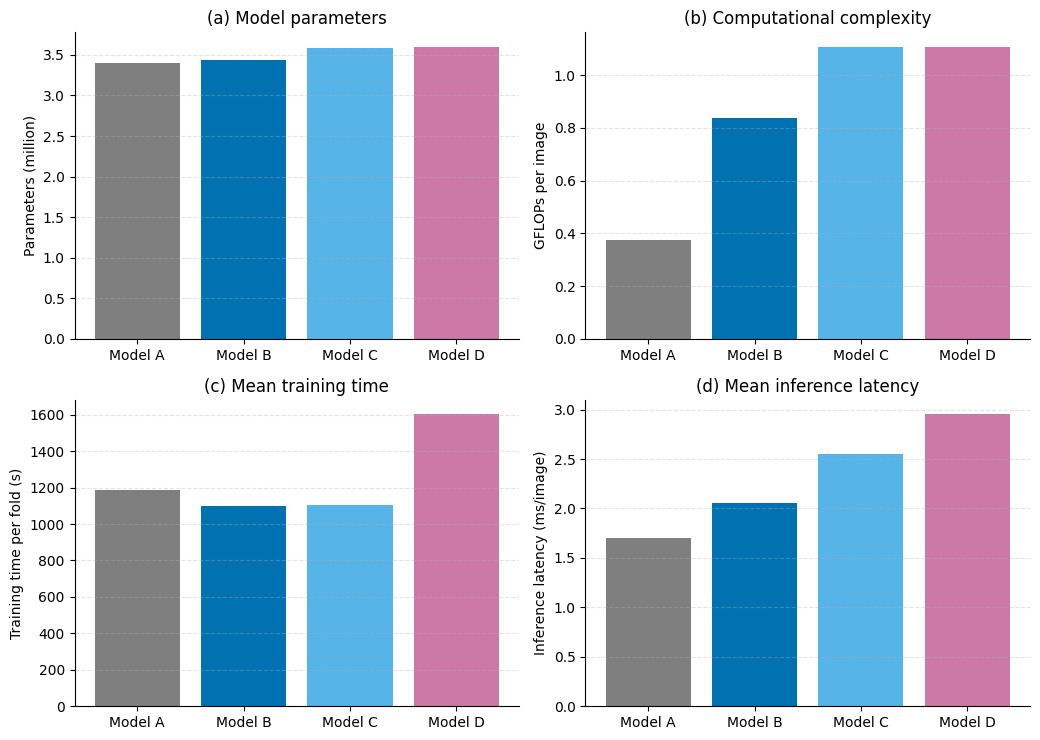


SVG figure saved to:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\ABCD_Complexity_and_Efficiency_Comparison.svg

600-dpi PNG saved to:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\ABCD_Complexity_and_Efficiency_Comparison.png


In [12]:
# =====================================================================
# CORRECTED A–D COMPLEXITY, TRAINING AND INFERENCE COMPARISON
# Automatically locates the CSV containing GFLOPs
# =====================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =====================================================================
# 1. PATHS
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

CV_FILE = (
    RESULTS_DIR / "ABCD_10Fold_All_Results.csv"
)

PARAMETER_FILE = (
    RESULTS_DIR / "ABCD_Architecture_Parameters.csv"
)

OUTPUT_FILE = (
    RESULTS_DIR
    / "ABCD_Complexity_Training_and_Inference_Table.csv"
)

SVG_OUTPUT = (
    RESULTS_DIR
    / "ABCD_Complexity_and_Efficiency_Comparison.svg"
)

PNG_OUTPUT = (
    RESULTS_DIR
    / "ABCD_Complexity_and_Efficiency_Comparison.png"
)


# =====================================================================
# 2. HELPER FUNCTIONS
# =====================================================================

def normalize_name(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace("_", " ")
        .replace("-", " ")
    )


def find_column(
    frame,
    possible_names,
    required=True
):

    available = {
        normalize_name(column): column
        for column in frame.columns
    }

    for possible_name in possible_names:

        normalized = normalize_name(
            possible_name
        )

        if normalized in available:
            return available[normalized]

    if required:
        raise ValueError(
            "Could not find any of these columns:\n"
            f"{possible_names}\n\n"
            "Available columns:\n"
            f"{frame.columns.tolist()}"
        )

    return None


def standardize_model_key(value):

    text = (
        str(value)
        .strip()
        .upper()
        .replace("MODEL", "")
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
    )

    aliases = {
        "A": "A",
        "B": "B",
        "C": "C",
        "D": "D"
    }

    return aliases.get(text, text)


def mean_sd(series, decimals=2):

    values = pd.to_numeric(
        series,
        errors="raise"
    )

    mean_value = values.mean()

    sample_sd = values.std(
        ddof=1
    )

    formatted = (
        f"{mean_value:.{decimals}f} ± "
        f"{sample_sd:.{decimals}f}"
    )

    return (
        mean_value,
        sample_sd,
        formatted
    )


def convert_parameters_to_millions(
    value,
    column_name
):

    value = float(value)

    if "(m)" in str(column_name).lower():
        return value

    if value > 1000:
        return value / 1_000_000

    return value


# =====================================================================
# 3. VERIFY BASIC FILES
# =====================================================================

for required_file in [
    CV_FILE,
    PARAMETER_FILE
]:
    if not required_file.exists():
        raise FileNotFoundError(
            f"Required file not found:\n{required_file}"
        )


# =====================================================================
# 4. AUTOMATICALLY LOCATE THE GFLOP FILE
# =====================================================================

gflop_column_names = [
    "GFLOPs",
    "GFLOPs/Image",
    "GFLOPs per Image",
    "FLOPs (G)",
    "Forward GFLOPs"
]

gflop_candidates = []

print("Searching for a CSV containing GFLOPs...\n")

for csv_file in sorted(
    RESULTS_DIR.rglob("*.csv")
):

    try:
        temporary_frame = pd.read_csv(
            csv_file,
            nrows=10
        )
    except Exception:
        continue

    candidate_gflop_column = find_column(
        temporary_frame,
        gflop_column_names,
        required=False
    )

    candidate_model_column = find_column(
        temporary_frame,
        [
            "Model Key",
            "Key",
            "Model"
        ],
        required=False
    )

    if (
        candidate_gflop_column is not None
        and candidate_model_column is not None
    ):
        gflop_candidates.append({
            "File": csv_file,
            "GFLOP Column":
                candidate_gflop_column,
            "Model Column":
                candidate_model_column
        })


if not gflop_candidates:

    print("No GFLOP-containing CSV was found.")

    print("\nAvailable CSV files and their columns:")

    for csv_file in sorted(
        RESULTS_DIR.rglob("*.csv")
    ):
        try:
            temporary_frame = pd.read_csv(
                csv_file,
                nrows=2
            )

            print("\nFILE:", csv_file.name)
            print(
                "COLUMNS:",
                temporary_frame.columns.tolist()
            )

        except Exception:
            pass

    raise FileNotFoundError(
        "\nNo saved GFLOP results were found. "
        "GFLOPs must be calculated from the actual "
        "Models A–D before generating the final table."
    )


print("Possible GFLOP files found:")

for index, candidate in enumerate(
    gflop_candidates,
    start=1
):
    print(
        f"{index}. {candidate['File'].name} "
        f"| GFLOP column: "
        f"{candidate['GFLOP Column']}"
    )


# Prefer filenames containing "detailed" or "complexity".
def candidate_priority(candidate):

    filename = (
        candidate["File"]
        .name
        .lower()
    )

    if "detailed" in filename:
        return 1

    if "complexity" in filename:
        return 2

    if "efficiency" in filename:
        return 3

    return 4


gflop_candidates = sorted(
    gflop_candidates,
    key=candidate_priority
)

selected_candidate = (
    gflop_candidates[0]
)

GFLOP_FILE = selected_candidate["File"]

print("\nSelected GFLOP file:")
print(GFLOP_FILE)


# =====================================================================
# 5. LOAD DATA
# =====================================================================

cv_results = pd.read_csv(
    CV_FILE
)

parameter_results = pd.read_csv(
    PARAMETER_FILE
)

gflop_results = pd.read_csv(
    GFLOP_FILE
)

print("\nTen-fold columns:")
print(cv_results.columns.tolist())

print("\nParameter columns:")
print(parameter_results.columns.tolist())

print("\nGFLOP columns:")
print(gflop_results.columns.tolist())


# =====================================================================
# 6. IDENTIFY COLUMNS
# =====================================================================

cv_model_column = find_column(
    cv_results,
    ["Model Key", "Key", "Model"]
)

fold_column = find_column(
    cv_results,
    ["Fold", "Fold Number"]
)

epochs_column = find_column(
    cv_results,
    ["Epochs Run", "Epochs"]
)

training_time_column = find_column(
    cv_results,
    [
        "Training Time (s)",
        "CV Mean Training/Fold (s)",
        "Train Time (s)"
    ]
)

mean_epoch_time_column = find_column(
    cv_results,
    [
        "Mean Epoch Time (s)",
        "CV Mean Epoch (s)",
        "Epoch Time (s)"
    ]
)

inference_total_column = find_column(
    cv_results,
    [
        "Inference Total (s)",
        "Total Inference Time (s)"
    ],
    required=False
)

latency_column = find_column(
    cv_results,
    [
        "Inference (ms/image)",
        "CV Mean Inference (ms/image)",
        "Latency (ms/image)"
    ]
)

parameter_model_column = find_column(
    parameter_results,
    ["Model Key", "Key", "Model"]
)

total_parameter_column = find_column(
    parameter_results,
    [
        "Parameters",
        "Total Parameters",
        "Parameters (M)"
    ]
)

trainable_parameter_column = find_column(
    parameter_results,
    [
        "Trainable Parameters",
        "Trainable Parameters (M)"
    ]
)

gflop_model_column = (
    selected_candidate["Model Column"]
)

gflops_column = (
    selected_candidate["GFLOP Column"]
)


# =====================================================================
# 7. STANDARDIZE MODEL KEYS
# =====================================================================

cv_results["Standard Key"] = (
    cv_results[cv_model_column]
    .apply(standardize_model_key)
)

parameter_results["Standard Key"] = (
    parameter_results[
        parameter_model_column
    ]
    .apply(standardize_model_key)
)

gflop_results["Standard Key"] = (
    gflop_results[
        gflop_model_column
    ]
    .apply(standardize_model_key)
)


# =====================================================================
# 8. MODEL NAMES
# =====================================================================

model_names = {
    "A": "MobileNetV1 baseline",
    "B": "Fourier-encoded coordinate INR",
    "C": "Image-conditioned Fourier-INR",
    "D": "Image-conditioned INR + cross-attention"
}


# =====================================================================
# 9. CREATE COMBINED TABLE
# =====================================================================

output_rows = []

for model_key in ["A", "B", "C", "D"]:

    cv_model = cv_results[
        cv_results["Standard Key"].eq(
            model_key
        )
    ].copy()

    parameter_model = parameter_results[
        parameter_results[
            "Standard Key"
        ].eq(model_key)
    ].copy()

    gflop_model = gflop_results[
        gflop_results[
            "Standard Key"
        ].eq(model_key)
    ].copy()

    if len(cv_model) != 10:
        raise ValueError(
            f"Expected 10 folds for Model {model_key}, "
            f"but found {len(cv_model)}."
        )

    if parameter_model.empty:
        raise ValueError(
            f"Parameter values missing for Model {model_key}."
        )

    if gflop_model.empty:
        raise ValueError(
            f"GFLOP value missing for Model {model_key} "
            f"in {GFLOP_FILE.name}."
        )

    total_parameters = pd.to_numeric(
        parameter_model[
            total_parameter_column
        ],
        errors="raise"
    ).iloc[0]

    trainable_parameters = pd.to_numeric(
        parameter_model[
            trainable_parameter_column
        ],
        errors="raise"
    ).iloc[0]

    parameters_m = (
        convert_parameters_to_millions(
            total_parameters,
            total_parameter_column
        )
    )

    trainable_parameters_m = (
        convert_parameters_to_millions(
            trainable_parameters,
            trainable_parameter_column
        )
    )

    gflops_value = pd.to_numeric(
        gflop_model[gflops_column],
        errors="raise"
    ).iloc[0]

    _, _, epochs_text = mean_sd(
        cv_model[epochs_column],
        decimals=2
    )

    training_mean, training_sd, training_text = (
        mean_sd(
            cv_model[training_time_column],
            decimals=2
        )
    )

    epoch_mean, epoch_sd, epoch_text = (
        mean_sd(
            cv_model[mean_epoch_time_column],
            decimals=2
        )
    )

    latency_mean, latency_sd, latency_text = (
        mean_sd(
            cv_model[latency_column],
            decimals=4
        )
    )

    if inference_total_column is not None:
        _, _, inference_total_text = mean_sd(
            cv_model[inference_total_column],
            decimals=4
        )
    else:
        inference_total_text = (
            "Not available"
        )

    output_rows.append({
        "Model": f"Model {model_key}",
        "Architecture":
            model_names[model_key],
        "Parameters (M)":
            parameters_m,
        "Trainable Parameters (M)":
            trainable_parameters_m,
        "GFLOPs":
            float(gflops_value),
        "Epochs Run":
            epochs_text,
        "Training Time/Fold (s)":
            training_text,
        "Mean Epoch Time (s)":
            epoch_text,
        "Inference Total (s)":
            inference_total_text,
        "Inference Latency (ms/image)":
            latency_text,
        "Training Mean Numeric":
            training_mean,
        "Latency Mean Numeric":
            latency_mean
    })


efficiency_table = pd.DataFrame(
    output_rows
)


# =====================================================================
# 10. SAVE THE TABLE
# =====================================================================

efficiency_table.to_csv(
    OUTPUT_FILE,
    index=False
)

print("\n" + "=" * 200)
print("A–D COMPLEXITY, TRAINING AND INFERENCE EFFICIENCY")
print("Timing values are mean ± sample standard deviation.")
print("=" * 200)

print(
    efficiency_table[
        [
            "Model",
            "Architecture",
            "Parameters (M)",
            "Trainable Parameters (M)",
            "GFLOPs",
            "Epochs Run",
            "Training Time/Fold (s)",
            "Mean Epoch Time (s)",
            "Inference Total (s)",
            "Inference Latency (ms/image)"
        ]
    ].to_string(
        index=False,
        formatters={
            "Parameters (M)":
                lambda value: f"{value:.4f}",
            "Trainable Parameters (M)":
                lambda value: f"{value:.4f}",
            "GFLOPs":
                lambda value: f"{value:.4f}"
        }
    )
)

print("\nTable saved to:")
print(OUTPUT_FILE)


# =====================================================================
# 11. GENERATE PUBLICATION-QUALITY SVG
# =====================================================================

plot_table = efficiency_table.copy()

colors = [
    "#7F7F7F",
    "#0072B2",
    "#56B4E9",
    "#CC79A7"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10.5, 7.5)
)

x_labels = plot_table["Model"]


# Parameters
axes[0, 0].bar(
    x_labels,
    plot_table["Parameters (M)"],
    color=colors
)

axes[0, 0].set_ylabel(
    "Parameters (million)"
)

axes[0, 0].set_title(
    "(a) Model parameters"
)


# GFLOPs
axes[0, 1].bar(
    x_labels,
    plot_table["GFLOPs"],
    color=colors
)

axes[0, 1].set_ylabel(
    "GFLOPs per image"
)

axes[0, 1].set_title(
    "(b) Computational complexity"
)


# Training time
axes[1, 0].bar(
    x_labels,
    plot_table[
        "Training Mean Numeric"
    ],
    color=colors
)

axes[1, 0].set_ylabel(
    "Training time per fold (s)"
)

axes[1, 0].set_title(
    "(c) Mean training time"
)


# Inference latency
axes[1, 1].bar(
    x_labels,
    plot_table[
        "Latency Mean Numeric"
    ],
    color=colors
)

axes[1, 1].set_ylabel(
    "Inference latency (ms/image)"
)

axes[1, 1].set_title(
    "(d) Mean inference latency"
)


for axis in axes.flat:

    axis.grid(
        axis="y",
        linestyle="--",
        alpha=0.35
    )

    axis.spines["top"].set_visible(
        False
    )

    axis.spines["right"].set_visible(
        False
    )

    axis.tick_params(
        axis="x",
        rotation=0
    )


plt.tight_layout()

plt.savefig(
    SVG_OUTPUT,
    format="svg",
    bbox_inches="tight"
)

plt.savefig(
    PNG_OUTPUT,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nSVG figure saved to:")
print(SVG_OUTPUT)

print("\n600-dpi PNG saved to:")
print(PNG_OUTPUT)

In [13]:
# =====================================================================
# AGGREGATED OUT-OF-FOLD CONFUSION MATRICES FOR MODELS A–D
#
# Correct procedure:
# 1. Load the raw count matrix from every held-out fold.
# 2. Sum raw counts across folds.
# 3. Row-normalize only after aggregation.
# =====================================================================

from pathlib import Path
from collections import defaultdict
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =====================================================================
# 1. PATHS AND CONFIGURATION
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

FOLDS_DIR = RESULTS_DIR / "folds"

OUTPUT_DIR = (
    RESULTS_DIR
    / "Aggregated_Out_of_Fold_Confusion_Matrices"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PNG_OUTPUT = (
    OUTPUT_DIR
    / "ABCD_Aggregated_Out_of_Fold_Confusion_Matrices.png"
)

SVG_OUTPUT = (
    OUTPUT_DIR
    / "ABCD_Aggregated_Out_of_Fold_Confusion_Matrices.svg"
)

MODEL_KEYS = ["A", "B", "C", "D"]

MODEL_TITLES = {
    "A": "A: MobileNetV1 baseline",
    "B": "B: Proposed Fourier-INR fusion",
    "C": "C: Image-conditioned Fourier-INR",
    "D": "D: Image-conditioned cross-attention"
}

CLASS_NAMES = [
    "Abdomen",
    "Brain",
    "Femur",
    "Maternal Cervix",
    "Thorax",
    "Other"
]

NUM_CLASSES = len(CLASS_NAMES)


# =====================================================================
# 2. LOCATE PER-FOLD CONFUSION-MATRIX FILES
# =====================================================================

if not FOLDS_DIR.exists():
    raise FileNotFoundError(
        f"Folds directory not found:\n{FOLDS_DIR}"
    )

candidate_files = sorted(
    FOLDS_DIR.rglob("*Confusion*Matrix*.csv")
)

if not candidate_files:
    # Try a less restrictive search.
    candidate_files = sorted(
        FOLDS_DIR.rglob("*confusion*.csv")
    )

if not candidate_files:
    raise FileNotFoundError(
        "No per-fold confusion-matrix CSV files were found under:\n"
        f"{FOLDS_DIR}"
    )

print("Candidate confusion-matrix files found:")
print("=" * 100)

for file in candidate_files:
    print(file)


# =====================================================================
# 3. IDENTIFY MODEL AND FOLD FROM EACH FILE PATH
# =====================================================================

def identify_model_and_fold(file_path):

    path_text = str(file_path).replace("\\", "/")

    model_match = re.search(
        r"Model[\s_\-]*([ABCD])",
        path_text,
        flags=re.IGNORECASE
    )

    fold_match = re.search(
        r"Fold[\s_\-]*0?([1-9]|10)",
        path_text,
        flags=re.IGNORECASE
    )

    if model_match is None or fold_match is None:
        return None, None

    model_key = model_match.group(1).upper()
    fold_number = int(fold_match.group(1))

    return model_key, fold_number


matrix_files = defaultdict(dict)
unrecognized_files = []

for file in candidate_files:

    model_key, fold_number = (
        identify_model_and_fold(file)
    )

    if model_key is None or fold_number is None:
        unrecognized_files.append(file)
        continue

    if fold_number in matrix_files[model_key]:
        raise ValueError(
            "More than one confusion matrix was found for "
            f"Model {model_key}, Fold {fold_number}:\n"
            f"1. {matrix_files[model_key][fold_number]}\n"
            f"2. {file}"
        )

    matrix_files[model_key][fold_number] = file


if unrecognized_files:
    print("\nFiles skipped because their model/fold could not be identified:")

    for file in unrecognized_files:
        print(file)


# =====================================================================
# 4. VERIFY FOLDS 1–10 FOR EVERY MODEL
# =====================================================================

expected_folds = set(range(1, 11))

for model_key in MODEL_KEYS:

    observed_folds = set(
        matrix_files[model_key].keys()
    )

    if observed_folds != expected_folds:

        missing_folds = (
            expected_folds - observed_folds
        )

        extra_folds = (
            observed_folds - expected_folds
        )

        raise ValueError(
            f"Model {model_key} does not have exactly "
            "one matrix for every fold.\n"
            f"Observed folds: {sorted(observed_folds)}\n"
            f"Missing folds: {sorted(missing_folds)}\n"
            f"Unexpected folds: {sorted(extra_folds)}"
        )

print("\nAll models contain raw matrices for Folds 1–10.")


# =====================================================================
# 5. LOAD AND VALIDATE ONE RAW CONFUSION MATRIX
# =====================================================================

def load_raw_confusion_matrix(file_path):

    frame = pd.read_csv(
        file_path,
        index_col=0
    )

    # Remove completely empty rows or columns.
    frame = frame.dropna(
        axis=0,
        how="all"
    )

    frame = frame.dropna(
        axis=1,
        how="all"
    )

    # If index_col=0 incorrectly removed a numerical column,
    # try loading without treating the first column as an index.
    if frame.shape != (
        NUM_CLASSES,
        NUM_CLASSES
    ):
        alternative = pd.read_csv(
            file_path
        )

        unnamed_columns = [
            column
            for column in alternative.columns
            if str(column).lower().startswith("unnamed")
        ]

        alternative = alternative.drop(
            columns=unnamed_columns,
            errors="ignore"
        )

        if alternative.shape == (
            NUM_CLASSES,
            NUM_CLASSES
        ):
            frame = alternative

    if frame.shape != (
        NUM_CLASSES,
        NUM_CLASSES
    ):
        raise ValueError(
            f"Expected a {NUM_CLASSES}x{NUM_CLASSES} matrix, "
            f"but found {frame.shape} in:\n{file_path}"
        )

    matrix = (
        frame
        .apply(
            pd.to_numeric,
            errors="raise"
        )
        .to_numpy(dtype=float)
    )

    if np.any(matrix < 0):
        raise ValueError(
            f"Negative values were found in:\n{file_path}"
        )

    # Raw confusion matrices must contain integer-like counts.
    if not np.allclose(
        matrix,
        np.round(matrix),
        atol=1e-8
    ):
        raise ValueError(
            "The matrix contains non-integer values and may already "
            "be normalized. Aggregation requires raw counts:\n"
            f"{file_path}"
        )

    # A normalized matrix often has rows summing to 1 or 100.
    row_sums = matrix.sum(axis=1)

    if (
        np.allclose(row_sums, 1.0, atol=0.02)
        or np.allclose(row_sums, 100.0, atol=0.2)
    ):
        raise ValueError(
            "The matrix appears to be row-normalized. "
            "Use the raw count-based fold matrix instead:\n"
            f"{file_path}"
        )

    return np.round(matrix).astype(np.int64)


# =====================================================================
# 6. SUM RAW MATRICES ACROSS THE TEN FOLDS
# =====================================================================

aggregated_counts = {}
normalized_percentages = {}
fold_totals = []

for model_key in MODEL_KEYS:

    total_matrix = np.zeros(
        (NUM_CLASSES, NUM_CLASSES),
        dtype=np.int64
    )

    for fold_number in range(1, 11):

        matrix_file = (
            matrix_files[model_key][fold_number]
        )

        fold_matrix = load_raw_confusion_matrix(
            matrix_file
        )

        total_matrix += fold_matrix

        fold_totals.append({
            "Model": model_key,
            "Fold": fold_number,
            "Images in Fold Matrix":
                int(fold_matrix.sum()),
            "File": str(matrix_file)
        })

    aggregated_counts[model_key] = (
        total_matrix
    )

    row_totals = total_matrix.sum(
        axis=1,
        keepdims=True
    )

    normalized_matrix = np.divide(
        total_matrix,
        row_totals,
        out=np.zeros_like(
            total_matrix,
            dtype=float
        ),
        where=row_totals != 0
    ) * 100.0

    normalized_percentages[model_key] = (
        normalized_matrix
    )


# =====================================================================
# 7. VERIFY THAT ALL MODELS EVALUATED THE SAME NUMBER OF OOF IMAGES
# =====================================================================

model_image_totals = {
    model_key: int(
        aggregated_counts[model_key].sum()
    )
    for model_key in MODEL_KEYS
}

print("\nAggregated out-of-fold image totals:")
print(model_image_totals)

if len(set(model_image_totals.values())) != 1:
    raise ValueError(
        "Models A–D do not contain the same number of "
        "aggregated out-of-fold predictions:\n"
        f"{model_image_totals}"
    )


# Optional verification using the saved ten-fold result file.
CV_RESULTS_FILE = (
    RESULTS_DIR / "ABCD_10Fold_All_Results.csv"
)

if CV_RESULTS_FILE.exists():

    cv_results = pd.read_csv(
        CV_RESULTS_FILE
    )

    required_columns = {
        "Model Key",
        "Fold",
        "Outer Test Images"
    }

    if required_columns.issubset(
        cv_results.columns
    ):

        for model_key in MODEL_KEYS:

            expected_total = int(
                cv_results.loc[
                    cv_results[
                        "Model Key"
                    ].astype(str).str.upper().eq(
                        model_key
                    ),
                    "Outer Test Images"
                ].sum()
            )

            observed_total = (
                model_image_totals[model_key]
            )

            if expected_total != observed_total:
                raise ValueError(
                    f"Model {model_key}: aggregated matrix contains "
                    f"{observed_total} predictions, but the fold-results "
                    f"CSV reports {expected_total} outer-test images."
                )

        print(
            "Aggregated matrix totals match the saved "
            "outer-fold image counts."
        )


# =====================================================================
# 8. SAVE RAW AND NORMALIZED MATRICES
# =====================================================================

for model_key in MODEL_KEYS:

    raw_frame = pd.DataFrame(
        aggregated_counts[model_key],
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    )

    normalized_frame = pd.DataFrame(
        normalized_percentages[model_key],
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    )

    raw_file = (
        OUTPUT_DIR
        / f"Model_{model_key}_Aggregated_OOF_Confusion_Matrix_Counts.csv"
    )

    normalized_file = (
        OUTPUT_DIR
        / f"Model_{model_key}_Aggregated_OOF_Confusion_Matrix_Percent.csv"
    )

    raw_frame.to_csv(raw_file)
    normalized_frame.to_csv(
        normalized_file,
        float_format="%.4f"
    )


pd.DataFrame(fold_totals).to_csv(
    OUTPUT_DIR / "OOF_Confusion_Matrix_File_Manifest.csv",
    index=False
)


# =====================================================================
# 9. CREATE ANNOTATIONS WITH PERCENTAGE AND RAW COUNT
# =====================================================================

def create_annotations(
    percentage_matrix,
    count_matrix
):

    annotations = np.empty(
        percentage_matrix.shape,
        dtype=object
    )

    for row in range(
        percentage_matrix.shape[0]
    ):
        for column in range(
            percentage_matrix.shape[1]
        ):
            annotations[row, column] = (
                f"{percentage_matrix[row, column]:.1f}%\n"
                f"({count_matrix[row, column]})"
            )

    return annotations


# =====================================================================
# 10. PLOT COMPOSITE A–D OOF CONFUSION MATRICES
# =====================================================================

sns.set_theme(
    style="white",
    font_scale=0.80
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 11)
)

axes = axes.ravel()

for axis, model_key in zip(
    axes,
    MODEL_KEYS
):

    percentage_matrix = (
        normalized_percentages[model_key]
    )

    count_matrix = (
        aggregated_counts[model_key]
    )

    annotations = create_annotations(
        percentage_matrix,
        count_matrix
    )

    sns.heatmap(
        percentage_matrix,
        ax=axis,
        cmap="YlGnBu",
        vmin=0,
        vmax=100,
        annot=annotations,
        fmt="",
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor="white",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        annot_kws={
            "fontsize": 7
        }
    )

    axis.set_title(
        MODEL_TITLES[model_key],
        fontsize=12,
        fontweight="bold",
        pad=9
    )

    axis.set_xlabel(
        "Predicted class",
        fontsize=10
    )

    axis.set_ylabel(
        "Reference class",
        fontsize=10
    )

    axis.tick_params(
        axis="x",
        labelrotation=35,
        labelsize=8
    )

    axis.tick_params(
        axis="y",
        labelrotation=0,
        labelsize=8
    )


# Shared colour bar.
colour_bar_axis = fig.add_axes(
    [0.92, 0.18, 0.018, 0.64]
)

scalar_mappable = plt.cm.ScalarMappable(
    norm=plt.Normalize(
        vmin=0,
        vmax=100
    ),
    cmap="YlGnBu"
)

colour_bar = fig.colorbar(
    scalar_mappable,
    cax=colour_bar_axis
)

colour_bar.set_label(
    "Row-normalized percentage (%)",
    fontsize=10
)

fig.suptitle(
    "Aggregated out-of-fold confusion matrices for Models A–D",
    fontsize=15,
    fontweight="bold",
    y=0.985
)

plt.subplots_adjust(
    left=0.08,
    right=0.89,
    bottom=0.08,
    top=0.93,
    wspace=0.22,
    hspace=0.28
)

plt.savefig(
    PNG_OUTPUT,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    SVG_OUTPUT,
    format="svg",
    bbox_inches="tight"
)

plt.show()


# =====================================================================
# 11. FINAL OUTPUT SUMMARY
# =====================================================================

print("\n" + "=" * 100)
print("AGGREGATED OUT-OF-FOLD CONFUSION MATRICES COMPLETED")
print("=" * 100)

print("\nTotal OOF images per model:")
print(model_image_totals)

print("\n600-dpi PNG saved to:")
print(PNG_OUTPUT)

print("\nSVG saved to:")
print(SVG_OUTPUT)

print("\nIndividual raw and normalized matrices saved under:")
print(OUTPUT_DIR)


Candidate confusion-matrix files found:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_01_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_02_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_03_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_04_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_05_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_06_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_07_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_08_Confu

ValueError: More than one confusion matrix was found for Model A, Fold 6:
1. D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_01_Confusion_Matrix.csv
2. D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_02_Confusion_Matrix.csv

SavedModel files found:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Final_Model_B_SavedModel\saved_model.pb

Loading Keras Model B from:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Final_Model_B_SavedModel

Model B loaded as a Keras model.
Object type: <class 'keras.engine.functional.Functional'>
Input shape(s): [(None, 128, 128, 1), (None, 128, 128, 2)]
Output shape: (None, 6)
Model: "Model_B"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 128, 128, 1  0           []                               
                                )]                                                                
                                                                                                

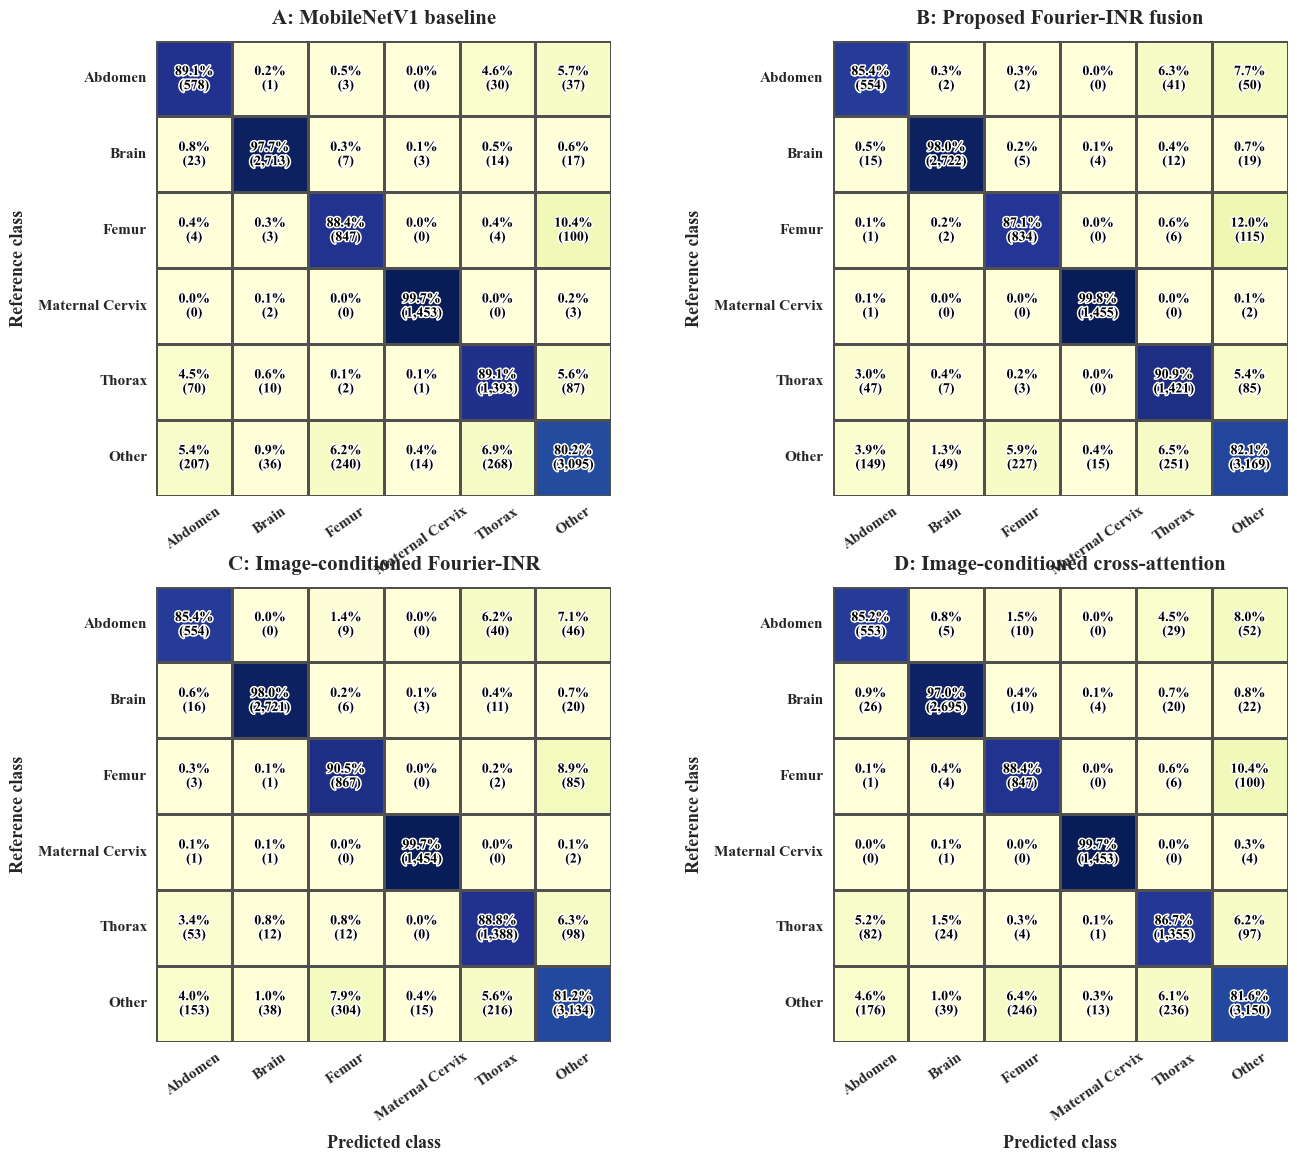

In [25]:
# =====================================================================
# AGGREGATED OUT-OF-FOLD CONFUSION MATRICES FOR MODELS A–D
#
# Method:
# 1. Read the raw count-based confusion matrix from each held-out fold.
# 2. Sum the raw counts across Folds 1–10.
# 3. Row-normalize the aggregated count matrix.
# 4. Display percentages and raw counts in each cell.
#
# This is NOT an average of normalized confusion matrices.
# =====================================================================
import matplotlib.patheffects as path_effects
from pathlib import Path
from collections import defaultdict
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =====================================================================
# 1. CONFIGURATION
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

FOLDS_DIR = (
    RESULTS_DIR / "folds"
)

OUTPUT_DIR = (
    RESULTS_DIR
    / "Aggregated_Out_of_Fold_Confusion_Matrices"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PNG_OUTPUT = (
    OUTPUT_DIR
    / "ABCD_Aggregated_Out_of_Fold_Confusion_Matrices.png"
)

SVG_OUTPUT = (
    OUTPUT_DIR
    / "ABCD_Aggregated_Out_of_Fold_Confusion_Matrices.svg"
)

MANIFEST_OUTPUT = (
    OUTPUT_DIR
    / "OOF_Confusion_Matrix_File_Manifest.csv"
)

MODEL_KEYS = [
    "A",
    "B",
    "C",
    "D"
]

MODEL_TITLES = {
    "A": "A: MobileNetV1 baseline",
    "B": "B: Proposed Fourier-INR fusion",
    "C": "C: Image-conditioned Fourier-INR",
    "D": "D: Image-conditioned cross-attention"
}

CLASS_NAMES = [
    "Abdomen",
    "Brain",
    "Femur",
    "Maternal Cervix",
    "Thorax",
    "Other"
]

NUM_CLASSES = len(
    CLASS_NAMES
)


## =====================================================================
# 2. LOAD MODEL B AS A KERAS MODEL
# =====================================================================

RESULTS_ROOT = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

MODEL_B_ROOT = RESULTS_ROOT / "final_model" / "Model_B"

if not MODEL_B_ROOT.exists():
    raise FileNotFoundError(
        f"Model B directory was not found:\n{MODEL_B_ROOT}"
    )

# Find every SavedModel directory under Model_B
saved_model_files = list(
    MODEL_B_ROOT.rglob("saved_model.pb")
)

print("SavedModel files found:")

for file in saved_model_files:
    print(file)

if len(saved_model_files) == 0:
    raise FileNotFoundError(
        "No saved_model.pb file was found under:\n"
        f"{MODEL_B_ROOT}"
    )

if len(saved_model_files) > 1:
    raise ValueError(
        "More than one SavedModel was found. Select the correct "
        "directory explicitly:\n"
        + "\n".join(str(file.parent) for file in saved_model_files)
    )

KERAS_MODEL_PATH = saved_model_files[0].parent

print("\nLoading Keras Model B from:")
print(KERAS_MODEL_PATH)

try:
    MODEL_B = tf.keras.models.load_model(
        str(KERAS_MODEL_PATH),
        compile=False
    )

except Exception as loading_error:
    print("\nKeras SavedModel loading failed.")
    print("Error:")
    print(loading_error)

    raise RuntimeError(
        "\nThe SavedModel cannot be reconstructed as a Keras model. "
        "Rebuild the Model B architecture and load its trained weights "
        "using the fallback code described below."
    ) from loading_error

if not isinstance(MODEL_B, tf.keras.Model):
    raise TypeError(
        "The loaded object is still not a tf.keras.Model."
    )

print("\nModel B loaded as a Keras model.")
print("Object type:", type(MODEL_B))
print("Input shape(s):", MODEL_B.input_shape)
print("Output shape:", MODEL_B.output_shape)

MODEL_B.summary()


# =====================================================================
# 3. LOCATE CANDIDATE CONFUSION-MATRIX FILES
# =====================================================================

candidate_files = sorted(
    FOLDS_DIR.rglob(
        "*Confusion*Matrix*.csv"
    )
)

if not candidate_files:
    candidate_files = sorted(
        FOLDS_DIR.rglob(
            "*confusion*.csv"
        )
    )

if not candidate_files:
    raise FileNotFoundError(
        "No per-fold confusion-matrix CSV files were found under:\n"
        f"{FOLDS_DIR}"
    )

print("\nCandidate files found:")
print("=" * 100)

for file in candidate_files:
    print(file)


# =====================================================================
# 4. IDENTIFY MODEL AND FOLD CORRECTLY
#
# Important correction:
# Search only inside the relative path under FOLDS_DIR.
# This prevents '10Fold_6Class' in the main directory name
# from being incorrectly detected as Fold 6.
# =====================================================================

def identify_model_and_fold(
    file_path,
    folds_directory
):

    try:
        relative_path = (
            file_path.relative_to(
                folds_directory
            )
        )
    except ValueError:
        return None, None

    relative_text = (
        relative_path.as_posix()
    )

    filename_text = (
        file_path.stem
    )

    # Detect Model_A, Model_B, Model_C or Model_D
    # from the relative folder path.
    model_match = re.search(
        r"(?:^|/)Model[\s_\-]*([ABCD])(?:/|$)",
        relative_text,
        flags=re.IGNORECASE
    )

    # Fallback when model key is included in filename.
    if model_match is None:
        model_match = re.search(
            r"(?:^|_)Model[\s_\-]*([ABCD])(?:_|$)",
            filename_text,
            flags=re.IGNORECASE
        )

    # Detect Fold_01 through Fold_10 from filename only.
    fold_match = re.search(
        r"(?:^|_)Fold[\s_\-]*0*(10|[1-9])(?:_|$)",
        filename_text,
        flags=re.IGNORECASE
    )

    if (
        model_match is None
        or fold_match is None
    ):
        return None, None

    model_key = (
        model_match
        .group(1)
        .upper()
    )

    fold_number = int(
        fold_match.group(1)
    )

    return (
        model_key,
        fold_number
    )


# =====================================================================
# 5. ORGANIZE FILES BY MODEL AND FOLD
# =====================================================================

matrix_files = defaultdict(dict)
unrecognized_files = []

for file in candidate_files:

    model_key, fold_number = (
        identify_model_and_fold(
            file,
            FOLDS_DIR
        )
    )

    if (
        model_key is None
        or fold_number is None
    ):
        unrecognized_files.append(
            file
        )
        continue

    if fold_number in matrix_files[
        model_key
    ]:

        existing_file = (
            matrix_files[
                model_key
            ][fold_number]
        )

        raise ValueError(
            "Duplicate matrices were found for "
            f"Model {model_key}, Fold {fold_number}:\n"
            f"1. {existing_file}\n"
            f"2. {file}"
        )

    matrix_files[
        model_key
    ][fold_number] = file


# =====================================================================
# 6. DISPLAY DETECTED FILES
# =====================================================================

print("\n" + "=" * 100)
print("DETECTED MODEL/FOLD MATRICES")
print("=" * 100)

for model_key in MODEL_KEYS:

    print(f"\nModel {model_key}:")

    for fold_number in sorted(
        matrix_files[model_key]
    ):
        print(
            f"  Fold {fold_number:02d}: "
            f"{matrix_files[model_key][fold_number].name}"
        )

if unrecognized_files:

    print(
        "\nFiles skipped because their model or fold "
        "could not be recognized:"
    )

    for file in unrecognized_files:
        print(file)


# =====================================================================
# 7. VERIFY EXACTLY FOLDS 1–10
# =====================================================================

expected_folds = set(
    range(1, 11)
)

for model_key in MODEL_KEYS:

    observed_folds = set(
        matrix_files[
            model_key
        ].keys()
    )

    if observed_folds != expected_folds:

        missing_folds = (
            expected_folds
            - observed_folds
        )

        unexpected_folds = (
            observed_folds
            - expected_folds
        )

        raise ValueError(
            f"Model {model_key} does not contain exactly "
            "one matrix for Folds 1–10.\n"
            f"Observed: {sorted(observed_folds)}\n"
            f"Missing: {sorted(missing_folds)}\n"
            f"Unexpected: {sorted(unexpected_folds)}"
        )

print(
    "\nAll four models contain exactly "
    "ten fold-specific confusion matrices."
)


# =====================================================================
# 8. LOAD AND VALIDATE A RAW CONFUSION MATRIX
# =====================================================================

def load_raw_confusion_matrix(
    file_path
):

    frame = pd.read_csv(
        file_path,
        index_col=0
    )

    frame = frame.dropna(
        axis=0,
        how="all"
    )

    frame = frame.dropna(
        axis=1,
        how="all"
    )

    # Alternative loading method if the CSV
    # does not contain saved row labels.
    if frame.shape != (
        NUM_CLASSES,
        NUM_CLASSES
    ):

        alternative = pd.read_csv(
            file_path
        )

        unnamed_columns = [
            column
            for column in alternative.columns
            if str(column)
            .lower()
            .startswith("unnamed")
        ]

        alternative = alternative.drop(
            columns=unnamed_columns,
            errors="ignore"
        )

        if alternative.shape == (
            NUM_CLASSES,
            NUM_CLASSES
        ):
            frame = alternative

    if frame.shape != (
        NUM_CLASSES,
        NUM_CLASSES
    ):
        raise ValueError(
            f"Expected a {NUM_CLASSES}x{NUM_CLASSES} "
            f"matrix, but found {frame.shape} in:\n"
            f"{file_path}"
        )

    numeric_frame = frame.apply(
        pd.to_numeric,
        errors="raise"
    )

    matrix = numeric_frame.to_numpy(
        dtype=float
    )

    if np.any(matrix < 0):
        raise ValueError(
            "Negative matrix values were found in:\n"
            f"{file_path}"
        )

    # Raw confusion matrices should contain integer counts.
    if not np.allclose(
        matrix,
        np.round(matrix),
        atol=1e-8
    ):
        raise ValueError(
            "The matrix contains non-integer values and "
            "may already be normalized. Raw counts are required:\n"
            f"{file_path}"
        )

    matrix = np.round(
        matrix
    ).astype(np.int64)

    # Detect matrices where every row appears normalized.
    row_sums = matrix.sum(
        axis=1
    )

    if (
        np.allclose(
            row_sums,
            1.0,
            atol=0.02
        )
        or np.allclose(
            row_sums,
            100.0,
            atol=0.2
        )
    ):
        raise ValueError(
            "This matrix appears to be row-normalized. "
            "Use raw count matrices instead:\n"
            f"{file_path}"
        )

    return matrix


# =====================================================================
# 9. AGGREGATE RAW COUNTS ACROSS FOLDS
# =====================================================================

aggregated_counts = {}
normalized_percentages = {}
manifest_rows = []

for model_key in MODEL_KEYS:

    total_matrix = np.zeros(
        (
            NUM_CLASSES,
            NUM_CLASSES
        ),
        dtype=np.int64
    )

    for fold_number in range(
        1,
        11
    ):

        matrix_file = (
            matrix_files[
                model_key
            ][fold_number]
        )

        fold_matrix = (
            load_raw_confusion_matrix(
                matrix_file
            )
        )

        total_matrix += fold_matrix

        manifest_rows.append({
            "Model": model_key,
            "Fold": fold_number,
            "Images in Matrix":
                int(fold_matrix.sum()),
            "File": str(matrix_file)
        })

    aggregated_counts[
        model_key
    ] = total_matrix

    row_totals = total_matrix.sum(
        axis=1,
        keepdims=True
    )

    normalized_matrix = np.divide(
        total_matrix,
        row_totals,
        out=np.zeros_like(
            total_matrix,
            dtype=float
        ),
        where=row_totals != 0
    ) * 100.0

    normalized_percentages[
        model_key
    ] = normalized_matrix


# =====================================================================
# 10. VERIFY THE SAME NUMBER OF OOF IMAGES
# =====================================================================

model_image_totals = {
    model_key: int(
        aggregated_counts[
            model_key
        ].sum()
    )
    for model_key in MODEL_KEYS
}

print("\nAggregated OOF image totals:")
print(model_image_totals)

if len(
    set(model_image_totals.values())
) != 1:
    raise ValueError(
        "Models A–D do not contain the same number "
        "of aggregated OOF predictions:\n"
        f"{model_image_totals}"
    )


# =====================================================================
# 11. OPTIONAL VERIFICATION AGAINST CV RESULT FILE
# =====================================================================

CV_RESULTS_FILE = (
    RESULTS_DIR
    / "ABCD_10Fold_All_Results.csv"
)

if CV_RESULTS_FILE.exists():

    cv_results = pd.read_csv(
        CV_RESULTS_FILE
    )

    required_columns = {
        "Model Key",
        "Fold",
        "Outer Test Images"
    }

    if required_columns.issubset(
        cv_results.columns
    ):

        for model_key in MODEL_KEYS:

            expected_image_total = int(
                cv_results.loc[
                    cv_results[
                        "Model Key"
                    ]
                    .astype(str)
                    .str.strip()
                    .str.upper()
                    .eq(model_key),
                    "Outer Test Images"
                ].sum()
            )

            observed_image_total = (
                model_image_totals[
                    model_key
                ]
            )

            if (
                observed_image_total
                != expected_image_total
            ):
                raise ValueError(
                    f"Model {model_key}: the aggregated "
                    f"matrix contains {observed_image_total} images, "
                    f"but the ten-fold result file reports "
                    f"{expected_image_total} outer-fold images."
                )

        print(
            "Aggregated totals match the outer-test "
            "image counts in the ten-fold results file."
        )


# =====================================================================
# 12. SAVE RAW AND NORMALIZED MATRICES
# =====================================================================

for model_key in MODEL_KEYS:

    raw_frame = pd.DataFrame(
        aggregated_counts[
            model_key
        ],
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    )

    percentage_frame = pd.DataFrame(
        normalized_percentages[
            model_key
        ],
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    )

    raw_file = (
        OUTPUT_DIR
        / (
            f"Model_{model_key}_Aggregated_OOF_"
            "Confusion_Matrix_Counts.csv"
        )
    )

    percentage_file = (
        OUTPUT_DIR
        / (
            f"Model_{model_key}_Aggregated_OOF_"
            "Confusion_Matrix_Percent.csv"
        )
    )

    raw_frame.to_csv(
        raw_file
    )

    percentage_frame.to_csv(
        percentage_file,
        float_format="%.4f"
    )


manifest_table = pd.DataFrame(
    manifest_rows
)

manifest_table.to_csv(
    MANIFEST_OUTPUT,
    index=False
)


# =====================================================================
# 13. CREATE CELL ANNOTATIONS
# =====================================================================

def create_annotations(
    percentage_matrix,
    count_matrix
):

    annotations = np.empty(
        percentage_matrix.shape,
        dtype=object
    )

    for row_index in range(
        percentage_matrix.shape[0]
    ):

        for column_index in range(
            percentage_matrix.shape[1]
        ):

            annotations[
                row_index,
                column_index
            ] = (
                f"{percentage_matrix[row_index, column_index]:.1f}%\n"
                f"({count_matrix[row_index, column_index]})"
            )

    return annotations


# =====================================================================
# 14. CREATE PRINT-READABLE COMBINED A-D FIGURE
# =====================================================================

PDF_OUTPUT = (
    OUTPUT_DIR
    / "ABCD_Aggregated_Out_of_Fold_Confusion_Matrices.pdf"
)

sns.set_theme(
    style="white",
    font="Times New Roman",
    font_scale=1.0
)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 13)
)

axes_flat = axes.ravel()

for axis, model_key in zip(
    axes_flat,
    MODEL_KEYS
):

    percentage_matrix = normalized_percentages[model_key]
    count_matrix = aggregated_counts[model_key]

    # Draw heatmap without automatic annotations.
    sns.heatmap(
        percentage_matrix,
        ax=axis,
        cmap="YlGnBu",
        vmin=0,
        vmax=100,
        annot=False,
        cbar=False,
        square=True,

        # Stronger cell boundaries for printed reproduction
        linewidths=0.9,
        linecolor="#505050",

        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    # -------------------------------------------------------------
    # Manually add bold black annotations
    # A white outline ensures visibility over dark blue cells.
    # -------------------------------------------------------------
    for row_index in range(NUM_CLASSES):
        for column_index in range(NUM_CLASSES):

            percentage = percentage_matrix[
                row_index,
                column_index
            ]

            count = count_matrix[
                row_index,
                column_index
            ]

            annotation_text = (
                f"{percentage:.1f}%\n"
                f"({count:,})"
            )

            text_object = axis.text(
                column_index + 0.5,
                row_index + 0.5,
                annotation_text,
                ha="center",
                va="center",
                color="black",
                fontsize=10,
                fontweight="bold",
                linespacing=1.10,
                zorder=5
            )

            # White outline surrounding the black characters.
            # This keeps the values readable on both pale and dark cells.
            text_object.set_path_effects([
                path_effects.Stroke(
                    linewidth=2.2,
                    foreground="white"
                ),
                path_effects.Normal()
            ])

    axis.set_title(
        MODEL_TITLES[model_key],
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    axis.set_xlabel(
        "Predicted class",
        fontsize=13,
        fontweight="bold",
        labelpad=8
    )

    axis.set_ylabel(
        "Reference class",
        fontsize=13,
        fontweight="bold",
        labelpad=8
    )

    axis.tick_params(
        axis="x",
        labelrotation=35,
        labelsize=11,
        width=1.0,
        length=3
    )

    axis.tick_params(
        axis="y",
        labelrotation=0,
        labelsize=11,
        width=1.0,
        length=3
    )

    # Make tick labels slightly heavier
    for tick_label in axis.get_xticklabels():
        tick_label.set_fontweight("semibold")

    for tick_label in axis.get_yticklabels():
        tick_label.set_fontweight("semibold")


# =====================================================================
# 15. ADD A SHARED COLOUR BAR
# =====================================================================

scalar_mappable = plt.cm.ScalarMappable(
    norm=plt.Normalize(
        vmin=0,
        vmax=100
    ),
    cmap="YlGnBu"
)

scalar_mappable.set_array([])

# Reserve appropriate


# =====================================================================
# 17. FINAL SUMMARY
# =====================================================================

print("\n" + "=" * 105)
print(
    "AGGREGATED OUT-OF-FOLD CONFUSION MATRICES COMPLETED"
)
print("=" * 105)

print("\nTotal OOF images per model:")
print(model_image_totals)

print("\n600-dpi PNG saved to:")
print(PNG_OUTPUT)

print("\nSVG saved to:")
print(SVG_OUTPUT)

print("\nIndividual raw and normalized matrices saved under:")
print(OUTPUT_DIR)

print("\nFile manifest saved to:")
print(MANIFEST_OUTPUT)

Available columns:
['Model Key', 'Fold', 'Epoch', 'Epoch Time (s)', 'loss', 'accuracy', 'val_loss', 'val_accuracy']

Rows loaded: 1,050

Detected columns:
Model column               : Model Key
Fold column                : Fold
Epoch column               : Epoch
Training-loss column       : loss
Validation-loss column     : val_loss
Training-accuracy column   : accuracy
Validation-accuracy column : val_accuracy

Completed folds per model:
Model Key Standard
A    10
B    10
C    10
D    10
Name: Fold, dtype: int64

Aggregated convergence-data preview:
           Metric Model Key Standard  Epoch     Mean       SD   Median  Minimum  Maximum  Contributing_Folds
Training accuracy                  A      1 0.567526 0.008424 0.564662 0.558140 0.585481                  10
Training accuracy                  A      2 0.705633 0.005007 0.705653 0.698028 0.716785                  10
Training accuracy                  A      3 0.747178 0.003390 0.748203 0.740955 0.752202                  10
Trainin

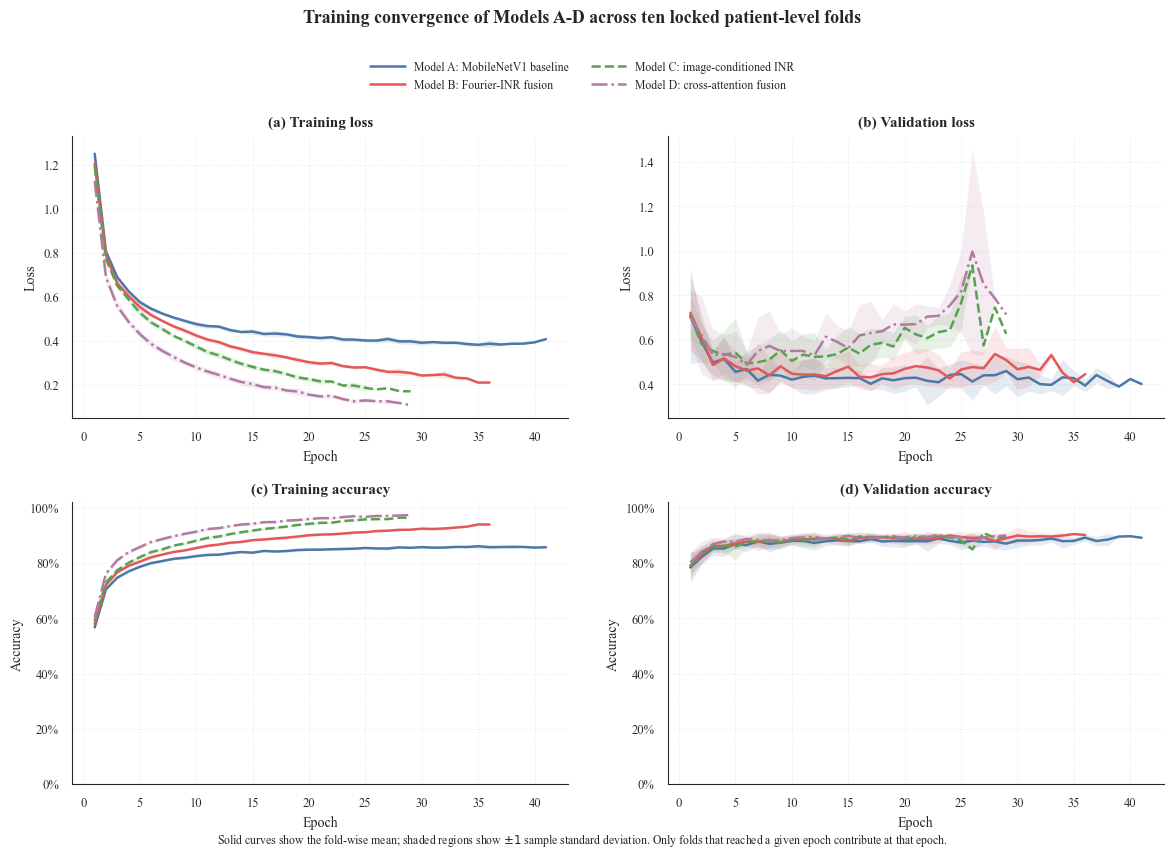


A-D TEN-FOLD TRAINING CONVERGENCE FIGURE GENERATED

PDF figure:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\ABCD_TenFold_Training_Convergence.pdf

PNG figure:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\ABCD_TenFold_Training_Convergence.png

SVG figure:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\ABCD_TenFold_Training_Convergence.svg

Aggregated convergence data:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\ABCD_TenFold_Training_Convergence_Summary.csv

Contributing-fold counts:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\ABCD_TenFold_Training_Contributing_Folds.csv


In [17]:
# =====================================================================
# A-D TEN-FOLD TRAINING CONVERGENCE FIGURE
# Mean ± sample SD across available folds at each epoch
# =====================================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# =====================================================================
# 1. PATHS
# =====================================================================

RESULTS_ROOT = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

EPOCH_CSV = RESULTS_ROOT / "ABCD_All_Epoch_Timings.csv"
OUTPUT_DIR = RESULTS_ROOT / "publication_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_STEM = OUTPUT_DIR / "ABCD_TenFold_Training_Convergence"

if not EPOCH_CSV.exists():
    raise FileNotFoundError(
        f"Epoch-timing CSV was not found:\n{EPOCH_CSV}"
    )

# =====================================================================
# 2. LOAD DATA
# =====================================================================

history = pd.read_csv(EPOCH_CSV)

print("Available columns:")
print(history.columns.tolist())
print(f"\nRows loaded: {len(history):,}")

# =====================================================================
# 3. COLUMN-DETECTION UTILITIES
# =====================================================================

def normalize_name(value):
    """Normalize a column name for tolerant matching."""
    return re.sub(r"[^a-z0-9]+", "", str(value).lower())


def find_column(frame, possible_names, required=True):
    """Find the first matching column using normalized names."""
    available = {
        normalize_name(column): column
        for column in frame.columns
    }

    for name in possible_names:
        normalized = normalize_name(name)
        if normalized in available:
            return available[normalized]

    if required:
        raise ValueError(
            "Could not find any of these columns:\n"
            f"{possible_names}\n\n"
            "Available columns:\n"
            f"{frame.columns.tolist()}"
        )

    return None


model_column = find_column(
    history,
    ["Model Key", "Model_Key", "Key", "Model"]
)

fold_column = find_column(
    history,
    ["Fold", "Fold Number", "Fold_Number"]
)

epoch_column = find_column(
    history,
    ["Epoch", "Epoch Number", "Epoch_Number"]
)

training_loss_column = find_column(
    history,
    ["loss", "Training Loss", "Train Loss"]
)

validation_loss_column = find_column(
    history,
    ["val_loss", "Validation Loss", "Val Loss"]
)

training_accuracy_column = find_column(
    history,
    [
        "accuracy",
        "Training Accuracy",
        "Train Accuracy",
        "categorical_accuracy",
        "sparse_categorical_accuracy"
    ]
)

validation_accuracy_column = find_column(
    history,
    [
        "val_accuracy",
        "Validation Accuracy",
        "Val Accuracy",
        "val_categorical_accuracy",
        "val_sparse_categorical_accuracy"
    ]
)

print("\nDetected columns:")
print(f"Model column               : {model_column}")
print(f"Fold column                : {fold_column}")
print(f"Epoch column               : {epoch_column}")
print(f"Training-loss column       : {training_loss_column}")
print(f"Validation-loss column     : {validation_loss_column}")
print(f"Training-accuracy column   : {training_accuracy_column}")
print(f"Validation-accuracy column : {validation_accuracy_column}")

# =====================================================================
# 4. STANDARDIZE MODEL KEYS
# =====================================================================

def standardize_model_key(value):
    text = str(value).strip().upper()

    direct_mapping = {
        "A": "A",
        "B": "B",
        "C": "C",
        "D": "D",
        "MODEL A": "A",
        "MODEL B": "B",
        "MODEL C": "C",
        "MODEL D": "D",
        "MODEL_A": "A",
        "MODEL_B": "B",
        "MODEL_C": "C",
        "MODEL_D": "D",
    }

    if text in direct_mapping:
        return direct_mapping[text]

    match = re.search(r"(?:MODEL[\s_-]*)?([ABCD])(?:\b|$)", text)
    if match:
        return match.group(1)

    return np.nan


history["Model Key Standard"] = history[model_column].apply(
    standardize_model_key
)

unrecognized = history.loc[
    history["Model Key Standard"].isna(),
    model_column
].dropna().unique()

if len(unrecognized) > 0:
    print("\nWarning: unrecognized model labels:")
    print(unrecognized)

history = history[
    history["Model Key Standard"].isin(["A", "B", "C", "D"])
].copy()

# =====================================================================
# 5. CLEAN NUMERIC VALUES
# =====================================================================

numeric_columns = [
    fold_column,
    epoch_column,
    training_loss_column,
    validation_loss_column,
    training_accuracy_column,
    validation_accuracy_column,
]

for column in numeric_columns:
    history[column] = pd.to_numeric(
        history[column],
        errors="coerce"
    )

required_columns = [
    "Model Key Standard",
    fold_column,
    epoch_column,
    training_loss_column,
    validation_loss_column,
    training_accuracy_column,
    validation_accuracy_column,
]

history = history.dropna(
    subset=[
        "Model Key Standard",
        fold_column,
        epoch_column
    ]
).copy()

history[fold_column] = history[fold_column].astype(int)
history[epoch_column] = history[epoch_column].astype(int)

# Detect duplicate model-fold-epoch rows
duplicate_mask = history.duplicated(
    subset=[
        "Model Key Standard",
        fold_column,
        epoch_column
    ],
    keep=False
)

if duplicate_mask.any():
    duplicate_rows = history.loc[
        duplicate_mask,
        [
            "Model Key Standard",
            fold_column,
            epoch_column
        ]
    ]

    raise ValueError(
        "Duplicate model-fold-epoch rows were detected:\n"
        f"{duplicate_rows.to_string(index=False)}"
    )

# =====================================================================
# 6. VERIFY FOLDS
# =====================================================================

fold_summary = (
    history.groupby("Model Key Standard")[fold_column]
    .nunique()
    .reindex(["A", "B", "C", "D"])
)

print("\nCompleted folds per model:")
print(fold_summary)

if not (fold_summary == 10).all():
    print(
        "\nWarning: at least one model does not contain ten folds. "
        "The figure will use the available folds."
    )

# =====================================================================
# 7. CONVERT ACCURACY TO PROPORTIONS IF STORED AS PERCENTAGES
# =====================================================================

for column in [training_accuracy_column, validation_accuracy_column]:
    valid_values = history[column].dropna()

    if len(valid_values) > 0 and valid_values.max() > 1.5:
        print(
            f"\nConverting '{column}' from percentage values "
            "to proportions."
        )
        history[column] = history[column] / 100.0

# =====================================================================
# 8. AGGREGATE BY MODEL AND EPOCH
# Compatible with older pandas versions
# =====================================================================

metric_columns = {
    "Training loss": training_loss_column,
    "Validation loss": validation_loss_column,
    "Training accuracy": training_accuracy_column,
    "Validation accuracy": validation_accuracy_column,
}

summary_frames = []

for metric_name, metric_column in metric_columns.items():

    metric_frame = history[
        [
            "Model Key Standard",
            epoch_column,
            metric_column
        ]
    ].dropna(subset=[metric_column]).copy()

    current = (
        metric_frame
        .groupby(
            ["Model Key Standard", epoch_column]
        )[metric_column]
        .agg([
            "mean",
            "std",
            "median",
            "min",
            "max",
            "count"
        ])
        .reset_index()
    )

    current = current.rename(
        columns={
            epoch_column: "Epoch",
            "mean": "Mean",
            "std": "SD",
            "median": "Median",
            "min": "Minimum",
            "max": "Maximum",
            "count": "Contributing_Folds",
        }
    )

    # Sample SD is undefined when only one fold contributes.
    # Use zero only for plotting that single available value.
    current["SD"] = current["SD"].fillna(0.0)

    current["Metric"] = metric_name

    summary_frames.append(current)

summary = pd.concat(
    summary_frames,
    ignore_index=True
)

# Arrange columns consistently
summary = summary[
    [
        "Metric",
        "Model Key Standard",
        "Epoch",
        "Mean",
        "SD",
        "Median",
        "Minimum",
        "Maximum",
        "Contributing_Folds",
    ]
]

summary = summary.sort_values(
    by=[
        "Metric",
        "Model Key Standard",
        "Epoch"
    ]
).reset_index(drop=True)

# Save aggregated convergence values
summary_output = (
    OUTPUT_DIR /
    "ABCD_TenFold_Training_Convergence_Summary.csv"
)

summary.to_csv(
    summary_output,
    index=False
)

# Create a separate table showing how many folds contributed
# at every epoch.
contributor_table = (
    summary
    .pivot_table(
        index=["Metric", "Epoch"],
        columns="Model Key Standard",
        values="Contributing_Folds",
        aggfunc="first"
    )
    .reset_index()
)

# Remove the column-index name created by pivot_table
contributor_table.columns.name = None

# Ensure consistent model-column order
contributor_columns = [
    column
    for column in ["Metric", "Epoch", "A", "B", "C", "D"]
    if column in contributor_table.columns
]

contributor_table = contributor_table[contributor_columns]

contributor_output = (
    OUTPUT_DIR /
    "ABCD_TenFold_Training_Contributing_Folds.csv"
)

contributor_table.to_csv(
    contributor_output,
    index=False
)

print("\nAggregated convergence-data preview:")
print(summary.head(12).to_string(index=False))

print("\nContributing-fold preview:")
print(contributor_table.head(12).to_string(index=False))

# =====================================================================
# 9. PUBLICATION STYLE
# =====================================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
})

MODEL_ORDER = ["A", "B", "C", "D"]

MODEL_LABELS = {
    "A": "Model A: MobileNetV1 baseline",
    "B": "Model B: Fourier-INR fusion",
    "C": "Model C: image-conditioned INR",
    "D": "Model D: cross-attention fusion",
}

MODEL_COLORS = {
    "A": "#4C78A8",
    "B": "#E45756",
    "C": "#59A14F",
    "D": "#B279A2",
}

MODEL_LINESTYLES = {
    "A": "-",
    "B": "-",
    "C": "--",
    "D": "-.",
}

# =====================================================================
# 10. PLOTTING FUNCTION
# =====================================================================

def plot_metric(ax, metric_name, panel_label, y_label, percentage=False):
    metric_data = summary[summary["Metric"] == metric_name]

    for model_key in MODEL_ORDER:
        model_data = (
            metric_data[
                metric_data["Model Key Standard"] == model_key
            ]
            .sort_values("Epoch")
            .copy()
        )

        if model_data.empty:
            print(
                f"Warning: no data available for {model_key}, "
                f"{metric_name}"
            )
            continue

        epochs = model_data["Epoch"].to_numpy(dtype=float)
        mean_values = model_data["Mean"].to_numpy(dtype=float)
        sd_values = model_data["SD"].to_numpy(dtype=float)

        lower = mean_values - sd_values
        upper = mean_values + sd_values

        if percentage:
            lower = np.clip(lower, 0.0, 1.0)
            upper = np.clip(upper, 0.0, 1.0)

        ax.plot(
            epochs,
            mean_values,
            color=MODEL_COLORS[model_key],
            linestyle=MODEL_LINESTYLES[model_key],
            linewidth=1.8,
            label=MODEL_LABELS[model_key],
            zorder=3
        )

        ax.fill_between(
            epochs,
            lower,
            upper,
            color=MODEL_COLORS[model_key],
            alpha=0.14,
            linewidth=0,
            zorder=2
        )

    ax.set_title(
        f"({panel_label}) {metric_name}",
        fontweight="bold",
        pad=7
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel(y_label)
    ax.grid(
        True,
        linestyle=":",
        linewidth=0.6,
        alpha=0.55
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if percentage:
        ax.yaxis.set_major_formatter(
            PercentFormatter(xmax=1.0, decimals=0)
        )
        ax.set_ylim(0.0, 1.02)

# =====================================================================
# 11. CREATE COMPOSITE FIGURE
# =====================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12.0, 8.2),
    constrained_layout=False
)

plot_metric(
    axes[0, 0],
    "Training loss",
    "a",
    "Loss",
    percentage=False
)

plot_metric(
    axes[0, 1],
    "Validation loss",
    "b",
    "Loss",
    percentage=False
)

plot_metric(
    axes[1, 0],
    "Training accuracy",
    "c",
    "Accuracy",
    percentage=True
)

plot_metric(
    axes[1, 1],
    "Validation accuracy",
    "d",
    "Accuracy",
    percentage=True
)

# Shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.985),
    ncol=2,
    frameon=False,
    columnspacing=1.8,
    handlelength=3.0
)

fig.suptitle(
    "Training convergence of Models A-D across ten locked "
    "patient-level folds",
    fontsize=13,
    fontweight="bold",
    y=1.035
)

fig.text(
    0.5,
    0.012,
    "Solid curves show the fold-wise mean; shaded regions show "
    r"$\pm 1$ sample standard deviation. "
    "Only folds that reached a given epoch contribute at that epoch.",
    ha="center",
    va="bottom",
    fontsize=8.5
)

fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.09,
    top=0.88,
    wspace=0.20,
    hspace=0.30
)

# =====================================================================
# 12. SAVE FIGURE
# =====================================================================

pdf_path = OUTPUT_STEM.with_suffix(".pdf")
png_path = OUTPUT_STEM.with_suffix(".png")
svg_path = OUTPUT_STEM.with_suffix(".svg")

fig.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight"
)

fig.savefig(
    png_path,
    format="png",
    dpi=900,
    bbox_inches="tight"
)

fig.savefig(
    svg_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

# =====================================================================
# 13. REPORT OUTPUTS
# =====================================================================

print("\n" + "=" * 90)
print("A-D TEN-FOLD TRAINING CONVERGENCE FIGURE GENERATED")
print("=" * 90)

print(f"\nPDF figure:\n{pdf_path}")
print(f"\nPNG figure:\n{png_path}")
print(f"\nSVG figure:\n{svg_path}")
print(f"\nAggregated convergence data:\n{summary_output}")
print(f"\nContributing-fold counts:\n{contributor_output}")

Folds directory:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds

Candidate files found:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_01_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_02_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_03_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_04_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_05_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_06_Confusion_Matrix.csv
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\folds\Model_A\Fold_07_Confusion_Matrix.csv
D:\imagecondition re

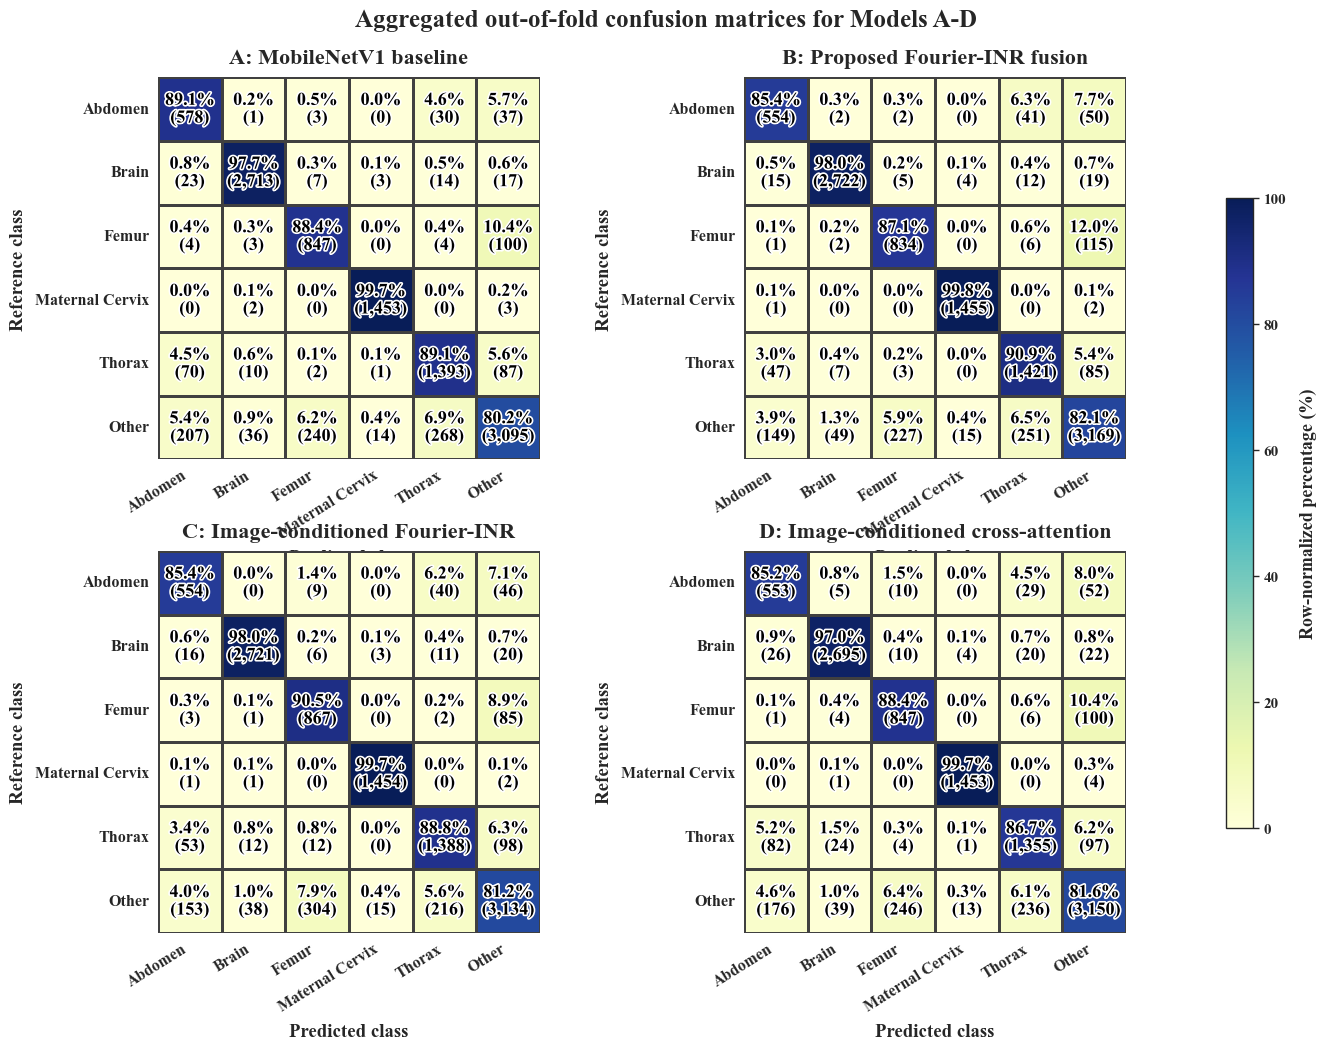


600-DPI PNG saved to:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\Aggregated_Out_of_Fold_Confusion_Matrices\ABCD_Aggregated_Out_of_Fold_Confusion_Matrices.png

Vector PDF saved to:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\Aggregated_Out_of_Fold_Confusion_Matrices\ABCD_Aggregated_Out_of_Fold_Confusion_Matrices.pdf

Vector SVG saved to:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\Aggregated_Out_of_Fold_Confusion_Matrices\ABCD_Aggregated_Out_of_Fold_Confusion_Matrices.svg

AGGREGATED OUT-OF-FOLD CONFUSION MATRICES COMPLETED

Total OOF images per model:
{'A': 11265, 'B': 11265, 'C': 11265, 'D': 11265}

600-dpi PNG saved to:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\Aggregated_Out_of_Fold_Confusion_Matrices\ABCD_Aggregated_Out_of_Fold_Confusion_Matrices.png

SVG saved to:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Resul

In [23]:
# =====================================================================
# AGGREGATED OUT-OF-FOLD CONFUSION MATRICES FOR MODELS A–D
#
# Method:
# 1. Read the raw count-based confusion matrix from each held-out fold.
# 2. Sum the raw counts across Folds 1–10.
# 3. Row-normalize the aggregated count matrix.
# 4. Display percentages and raw counts in each cell.
#
# This is NOT an average of normalized confusion matrices.
# =====================================================================
import matplotlib.patheffects as path_effects
from pathlib import Path
from collections import defaultdict
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =====================================================================
# 1. CONFIGURATION
# =====================================================================

RESULTS_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

FOLDS_DIR = (
    RESULTS_DIR / "folds"
)

OUTPUT_DIR = (
    RESULTS_DIR
    / "Aggregated_Out_of_Fold_Confusion_Matrices"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PNG_OUTPUT = (
    OUTPUT_DIR
    / "ABCD_Aggregated_Out_of_Fold_Confusion_Matrices.png"
)

SVG_OUTPUT = (
    OUTPUT_DIR
    / "ABCD_Aggregated_Out_of_Fold_Confusion_Matrices.svg"
)

MANIFEST_OUTPUT = (
    OUTPUT_DIR
    / "OOF_Confusion_Matrix_File_Manifest.csv"
)

MODEL_KEYS = [
    "A",
    "B",
    "C",
    "D"
]

MODEL_TITLES = {
    "A": "A: MobileNetV1 baseline",
    "B": "B: Proposed Fourier-INR fusion",
    "C": "C: Image-conditioned Fourier-INR",
    "D": "D: Image-conditioned cross-attention"
}

CLASS_NAMES = [
    "Abdomen",
    "Brain",
    "Femur",
    "Maternal Cervix",
    "Thorax",
    "Other"
]

NUM_CLASSES = len(
    CLASS_NAMES
)


# =====================================================================
# 2. VERIFY FOLDS DIRECTORY
# =====================================================================

if not FOLDS_DIR.exists():
    raise FileNotFoundError(
        "The folds directory was not found:\n"
        f"{FOLDS_DIR}"
    )

print("Folds directory:")
print(FOLDS_DIR)


# =====================================================================
# 3. LOCATE CANDIDATE CONFUSION-MATRIX FILES
# =====================================================================

candidate_files = sorted(
    FOLDS_DIR.rglob(
        "*Confusion*Matrix*.csv"
    )
)

if not candidate_files:
    candidate_files = sorted(
        FOLDS_DIR.rglob(
            "*confusion*.csv"
        )
    )

if not candidate_files:
    raise FileNotFoundError(
        "No per-fold confusion-matrix CSV files were found under:\n"
        f"{FOLDS_DIR}"
    )

print("\nCandidate files found:")
print("=" * 100)

for file in candidate_files:
    print(file)


# =====================================================================
# 4. IDENTIFY MODEL AND FOLD CORRECTLY
#
# Important correction:
# Search only inside the relative path under FOLDS_DIR.
# This prevents '10Fold_6Class' in the main directory name
# from being incorrectly detected as Fold 6.
# =====================================================================

def identify_model_and_fold(
    file_path,
    folds_directory
):

    try:
        relative_path = (
            file_path.relative_to(
                folds_directory
            )
        )
    except ValueError:
        return None, None

    relative_text = (
        relative_path.as_posix()
    )

    filename_text = (
        file_path.stem
    )

    # Detect Model_A, Model_B, Model_C or Model_D
    # from the relative folder path.
    model_match = re.search(
        r"(?:^|/)Model[\s_\-]*([ABCD])(?:/|$)",
        relative_text,
        flags=re.IGNORECASE
    )

    # Fallback when model key is included in filename.
    if model_match is None:
        model_match = re.search(
            r"(?:^|_)Model[\s_\-]*([ABCD])(?:_|$)",
            filename_text,
            flags=re.IGNORECASE
        )

    # Detect Fold_01 through Fold_10 from filename only.
    fold_match = re.search(
        r"(?:^|_)Fold[\s_\-]*0*(10|[1-9])(?:_|$)",
        filename_text,
        flags=re.IGNORECASE
    )

    if (
        model_match is None
        or fold_match is None
    ):
        return None, None

    model_key = (
        model_match
        .group(1)
        .upper()
    )

    fold_number = int(
        fold_match.group(1)
    )

    return (
        model_key,
        fold_number
    )


# =====================================================================
# 5. ORGANIZE FILES BY MODEL AND FOLD
# =====================================================================

matrix_files = defaultdict(dict)
unrecognized_files = []

for file in candidate_files:

    model_key, fold_number = (
        identify_model_and_fold(
            file,
            FOLDS_DIR
        )
    )

    if (
        model_key is None
        or fold_number is None
    ):
        unrecognized_files.append(
            file
        )
        continue

    if fold_number in matrix_files[
        model_key
    ]:

        existing_file = (
            matrix_files[
                model_key
            ][fold_number]
        )

        raise ValueError(
            "Duplicate matrices were found for "
            f"Model {model_key}, Fold {fold_number}:\n"
            f"1. {existing_file}\n"
            f"2. {file}"
        )

    matrix_files[
        model_key
    ][fold_number] = file


# =====================================================================
# 6. DISPLAY DETECTED FILES
# =====================================================================

print("\n" + "=" * 100)
print("DETECTED MODEL/FOLD MATRICES")
print("=" * 100)

for model_key in MODEL_KEYS:

    print(f"\nModel {model_key}:")

    for fold_number in sorted(
        matrix_files[model_key]
    ):
        print(
            f"  Fold {fold_number:02d}: "
            f"{matrix_files[model_key][fold_number].name}"
        )

if unrecognized_files:

    print(
        "\nFiles skipped because their model or fold "
        "could not be recognized:"
    )

    for file in unrecognized_files:
        print(file)


# =====================================================================
# 7. VERIFY EXACTLY FOLDS 1–10
# =====================================================================

expected_folds = set(
    range(1, 11)
)

for model_key in MODEL_KEYS:

    observed_folds = set(
        matrix_files[
            model_key
        ].keys()
    )

    if observed_folds != expected_folds:

        missing_folds = (
            expected_folds
            - observed_folds
        )

        unexpected_folds = (
            observed_folds
            - expected_folds
        )

        raise ValueError(
            f"Model {model_key} does not contain exactly "
            "one matrix for Folds 1–10.\n"
            f"Observed: {sorted(observed_folds)}\n"
            f"Missing: {sorted(missing_folds)}\n"
            f"Unexpected: {sorted(unexpected_folds)}"
        )

print(
    "\nAll four models contain exactly "
    "ten fold-specific confusion matrices."
)


# =====================================================================
# 8. LOAD AND VALIDATE A RAW CONFUSION MATRIX
# =====================================================================

def load_raw_confusion_matrix(
    file_path
):

    frame = pd.read_csv(
        file_path,
        index_col=0
    )

    frame = frame.dropna(
        axis=0,
        how="all"
    )

    frame = frame.dropna(
        axis=1,
        how="all"
    )

    # Alternative loading method if the CSV
    # does not contain saved row labels.
    if frame.shape != (
        NUM_CLASSES,
        NUM_CLASSES
    ):

        alternative = pd.read_csv(
            file_path
        )

        unnamed_columns = [
            column
            for column in alternative.columns
            if str(column)
            .lower()
            .startswith("unnamed")
        ]

        alternative = alternative.drop(
            columns=unnamed_columns,
            errors="ignore"
        )

        if alternative.shape == (
            NUM_CLASSES,
            NUM_CLASSES
        ):
            frame = alternative

    if frame.shape != (
        NUM_CLASSES,
        NUM_CLASSES
    ):
        raise ValueError(
            f"Expected a {NUM_CLASSES}x{NUM_CLASSES} "
            f"matrix, but found {frame.shape} in:\n"
            f"{file_path}"
        )

    numeric_frame = frame.apply(
        pd.to_numeric,
        errors="raise"
    )

    matrix = numeric_frame.to_numpy(
        dtype=float
    )

    if np.any(matrix < 0):
        raise ValueError(
            "Negative matrix values were found in:\n"
            f"{file_path}"
        )

    # Raw confusion matrices should contain integer counts.
    if not np.allclose(
        matrix,
        np.round(matrix),
        atol=1e-8
    ):
        raise ValueError(
            "The matrix contains non-integer values and "
            "may already be normalized. Raw counts are required:\n"
            f"{file_path}"
        )

    matrix = np.round(
        matrix
    ).astype(np.int64)

    # Detect matrices where every row appears normalized.
    row_sums = matrix.sum(
        axis=1
    )

    if (
        np.allclose(
            row_sums,
            1.0,
            atol=0.02
        )
        or np.allclose(
            row_sums,
            100.0,
            atol=0.2
        )
    ):
        raise ValueError(
            "This matrix appears to be row-normalized. "
            "Use raw count matrices instead:\n"
            f"{file_path}"
        )

    return matrix


# =====================================================================
# 9. AGGREGATE RAW COUNTS ACROSS FOLDS
# =====================================================================

aggregated_counts = {}
normalized_percentages = {}
manifest_rows = []

for model_key in MODEL_KEYS:

    total_matrix = np.zeros(
        (
            NUM_CLASSES,
            NUM_CLASSES
        ),
        dtype=np.int64
    )

    for fold_number in range(
        1,
        11
    ):

        matrix_file = (
            matrix_files[
                model_key
            ][fold_number]
        )

        fold_matrix = (
            load_raw_confusion_matrix(
                matrix_file
            )
        )

        total_matrix += fold_matrix

        manifest_rows.append({
            "Model": model_key,
            "Fold": fold_number,
            "Images in Matrix":
                int(fold_matrix.sum()),
            "File": str(matrix_file)
        })

    aggregated_counts[
        model_key
    ] = total_matrix

    row_totals = total_matrix.sum(
        axis=1,
        keepdims=True
    )

    normalized_matrix = np.divide(
        total_matrix,
        row_totals,
        out=np.zeros_like(
            total_matrix,
            dtype=float
        ),
        where=row_totals != 0
    ) * 100.0

    normalized_percentages[
        model_key
    ] = normalized_matrix


# =====================================================================
# 10. VERIFY THE SAME NUMBER OF OOF IMAGES
# =====================================================================

model_image_totals = {
    model_key: int(
        aggregated_counts[
            model_key
        ].sum()
    )
    for model_key in MODEL_KEYS
}

print("\nAggregated OOF image totals:")
print(model_image_totals)

if len(
    set(model_image_totals.values())
) != 1:
    raise ValueError(
        "Models A–D do not contain the same number "
        "of aggregated OOF predictions:\n"
        f"{model_image_totals}"
    )


# =====================================================================
# 11. OPTIONAL VERIFICATION AGAINST CV RESULT FILE
# =====================================================================

CV_RESULTS_FILE = (
    RESULTS_DIR
    / "ABCD_10Fold_All_Results.csv"
)

if CV_RESULTS_FILE.exists():

    cv_results = pd.read_csv(
        CV_RESULTS_FILE
    )

    required_columns = {
        "Model Key",
        "Fold",
        "Outer Test Images"
    }

    if required_columns.issubset(
        cv_results.columns
    ):

        for model_key in MODEL_KEYS:

            expected_image_total = int(
                cv_results.loc[
                    cv_results[
                        "Model Key"
                    ]
                    .astype(str)
                    .str.strip()
                    .str.upper()
                    .eq(model_key),
                    "Outer Test Images"
                ].sum()
            )

            observed_image_total = (
                model_image_totals[
                    model_key
                ]
            )

            if (
                observed_image_total
                != expected_image_total
            ):
                raise ValueError(
                    f"Model {model_key}: the aggregated "
                    f"matrix contains {observed_image_total} images, "
                    f"but the ten-fold result file reports "
                    f"{expected_image_total} outer-fold images."
                )

        print(
            "Aggregated totals match the outer-test "
            "image counts in the ten-fold results file."
        )


# =====================================================================
# 12. SAVE RAW AND NORMALIZED MATRICES
# =====================================================================

for model_key in MODEL_KEYS:

    raw_frame = pd.DataFrame(
        aggregated_counts[
            model_key
        ],
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    )

    percentage_frame = pd.DataFrame(
        normalized_percentages[
            model_key
        ],
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    )

    raw_file = (
        OUTPUT_DIR
        / (
            f"Model_{model_key}_Aggregated_OOF_"
            "Confusion_Matrix_Counts.csv"
        )
    )

    percentage_file = (
        OUTPUT_DIR
        / (
            f"Model_{model_key}_Aggregated_OOF_"
            "Confusion_Matrix_Percent.csv"
        )
    )

    raw_frame.to_csv(
        raw_file
    )

    percentage_frame.to_csv(
        percentage_file,
        float_format="%.4f"
    )


manifest_table = pd.DataFrame(
    manifest_rows
)

manifest_table.to_csv(
    MANIFEST_OUTPUT,
    index=False
)


# =====================================================================
# 13. CREATE CELL ANNOTATIONS
# =====================================================================

def create_annotations(
    percentage_matrix,
    count_matrix
):

    annotations = np.empty(
        percentage_matrix.shape,
        dtype=object
    )

    for row_index in range(
        percentage_matrix.shape[0]
    ):

        for column_index in range(
            percentage_matrix.shape[1]
        ):

            annotations[
                row_index,
                column_index
            ] = (
                f"{percentage_matrix[row_index, column_index]:.1f}%\n"
                f"({count_matrix[row_index, column_index]})"
            )

    return annotations


# =====================================================================
# 14. CREATE LARGER, PRINT-READABLE COMBINED A-D FIGURE
# =====================================================================

import matplotlib.patheffects as path_effects

PDF_OUTPUT = (
    OUTPUT_DIR
    / "ABCD_Aggregated_Out_of_Fold_Confusion_Matrices.pdf"
)

sns.set_theme(
    style="white",
    font="serif"
)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 1.0,
    "savefig.dpi": 600
})

# A smaller canvas with larger fonts produces larger text
# after the figure is reduced to the journal page width.
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13.5, 10.5)
)

axes_flat = axes.ravel()

for axis, model_key in zip(
    axes_flat,
    MODEL_KEYS
):

    percentage_matrix = normalized_percentages[model_key]
    count_matrix = aggregated_counts[model_key]

    sns.heatmap(
        percentage_matrix,
        ax=axis,
        cmap="YlGnBu",
        vmin=0,
        vmax=100,
        annot=False,
        cbar=False,
        square=True,
        linewidths=0.9,
        linecolor="#404040",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    # Add large bold values manually
    for row_index in range(NUM_CLASSES):
        for column_index in range(NUM_CLASSES):

            percentage = percentage_matrix[
                row_index,
                column_index
            ]

            count = count_matrix[
                row_index,
                column_index
            ]

            annotation_text = (
                f"{percentage:.1f}%\n"
                f"({count:,})"
            )

            text_object = axis.text(
                column_index + 0.5,
                row_index + 0.5,
                annotation_text,
                ha="center",
                va="center",
                color="black",
                fontsize=13,
                fontweight="bold",
                linespacing=1.05,
                zorder=5
            )

            # White outline makes black text readable on dark cells.
            text_object.set_path_effects([
                path_effects.Stroke(
                    linewidth=2.4,
                    foreground="white"
                ),
                path_effects.Normal()
            ])

    axis.set_title(
        MODEL_TITLES[model_key],
        fontsize=16,
        fontweight="bold",
        pad=10
    )

    axis.set_xlabel(
        "Predicted class",
        fontsize=13.5,
        fontweight="bold",
        labelpad=6
    )

    axis.set_ylabel(
        "Reference class",
        fontsize=13.5,
        fontweight="bold",
        labelpad=6
    )

    axis.tick_params(
        axis="x",
        labelrotation=32,
        labelsize=11.5,
        width=1.0,
        length=3,
        pad=3
    )

    axis.tick_params(
        axis="y",
        labelrotation=0,
        labelsize=11.5,
        width=1.0,
        length=3,
        pad=3
    )

    for tick_label in axis.get_xticklabels():
        tick_label.set_fontweight("semibold")
        tick_label.set_horizontalalignment("right")

    for tick_label in axis.get_yticklabels():
        tick_label.set_fontweight("semibold")


# =====================================================================
# 15. SHARED COLOUR BAR AND LAYOUT
# =====================================================================

scalar_mappable = plt.cm.ScalarMappable(
    norm=plt.Normalize(
        vmin=0,
        vmax=100
    ),
    cmap="YlGnBu"
)

scalar_mappable.set_array([])

# Reduce unused margins and enlarge the matrices
fig.subplots_adjust(
    left=0.075,
    right=0.890,
    bottom=0.085,
    top=0.900,
    wspace=0.14,
    hspace=0.24
)

# Shared colour-bar position
colour_bar_axis = fig.add_axes([
    0.915,   # left
    0.185,   # bottom
    0.020,   # width
    0.600    # height
])

colour_bar = fig.colorbar(
    scalar_mappable,
    cax=colour_bar_axis,
    ticks=np.arange(0, 101, 20)
)

colour_bar.set_label(
    "Row-normalized percentage (%)",
    fontsize=13,
    fontweight="bold",
    labelpad=10
)

colour_bar.ax.tick_params(
    labelsize=11,
    width=1.0,
    length=4
)

for tick_label in colour_bar.ax.get_yticklabels():
    tick_label.set_fontweight("semibold")

colour_bar.outline.set_linewidth(1.0)

fig.suptitle(
    "Aggregated out-of-fold confusion matrices for Models A-D",
    fontsize=18,
    fontweight="bold",
    y=0.965
)


# =====================================================================
# 16. SAVE THE FIGURE
# =====================================================================

fig.savefig(
    PNG_OUTPUT,
    format="png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white"
)

fig.savefig(
    PDF_OUTPUT,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white"
)

fig.savefig(
    SVG_OUTPUT,
    format="svg",
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white"
)

plt.show()
plt.close(fig)

print("\n600-DPI PNG saved to:")
print(PNG_OUTPUT)

print("\nVector PDF saved to:")
print(PDF_OUTPUT)

print("\nVector SVG saved to:")
print(SVG_OUTPUT)

# Reserve appropriate


# =====================================================================
# 17. FINAL SUMMARY
# =====================================================================

print("\n" + "=" * 105)
print(
    "AGGREGATED OUT-OF-FOLD CONFUSION MATRICES COMPLETED"
)
print("=" * 105)

print("\nTotal OOF images per model:")
print(model_image_totals)

print("\n600-dpi PNG saved to:")
print(PNG_OUTPUT)

print("\nSVG saved to:")
print(SVG_OUTPUT)

print("\nIndividual raw and normalized matrices saved under:")
print(OUTPUT_DIR)

print("\nFile manifest saved to:")
print(MANIFEST_OUTPUT)

SavedModel files found:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Final_Model_B_SavedModel\saved_model.pb

Loading Keras Model B from:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Final_Model_B_SavedModel

Model B loaded as a Keras model.
Object type: <class 'keras.engine.functional.Functional'>
Input shape(s): [(None, 128, 128, 1), (None, 128, 128, 2)]
Output shape: (None, 6)
Model: "Model_B"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 128, 128, 1  0           []                               
                                )]                                                                
                                                                                                

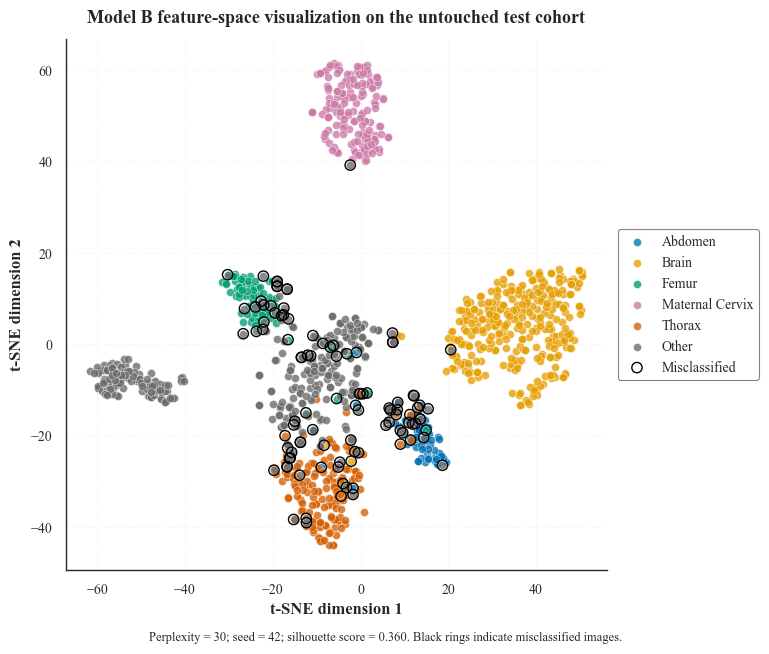


MODEL B t-SNE VISUALIZATION COMPLETED

Feature layer:
model_B_bn

PDF figure:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B_Untouched_Test_tSNE.pdf

PNG figure:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B_Untouched_Test_tSNE.png

SVG figure:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B_Untouched_Test_tSNE.svg

Coordinates and predictions:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B_Untouched_Test_tSNE_Coordinates.csv


In [28]:
# =====================================================================
# MODEL B — t-SNE VISUALIZATION ON UNTOUCHED PATIENT-LEVEL TEST SET
# =====================================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# =====================================================================
# 1. CONFIGURATION
# =====================================================================

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
BATCH_SIZE = 16

TEST_ROOT = Path(
    r"C:\Users\viraj\Downloads\patientsplit801010\test"
)

OUTPUT_DIR = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
    r"\publication_figures"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_STEM = OUTPUT_DIR / "Model_B_Untouched_Test_tSNE"

CLASS_NAMES = [
    "Abdomen",
    "Brain",
    "Femur",
    "Maternal Cervix",
    "Thorax",
    "Other"
]

CLASS_COLORS = {
    "Abdomen": "#0072B2",
    "Brain": "#E69F00",
    "Femur": "#009E73",
    "Maternal Cervix": "#CC79A7",
    "Thorax": "#D55E00",
    "Other": "#6A6A6A",
}

IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"
}

# Must match the preprocessing used during Model B training.
# Use "zero_one" if training images were divided by 255.
# Use "minus_one_one" if MobileNet preprocessing was applied externally.
PREPROCESSING_MODE = "zero_one"

# =====================================================================
# 2. LOAD MODEL B AS A KERAS MODEL
# =====================================================================

RESULTS_ROOT = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
)

MODEL_B_ROOT = RESULTS_ROOT / "final_model" / "Model_B"

if not MODEL_B_ROOT.exists():
    raise FileNotFoundError(
        f"Model B directory was not found:\n{MODEL_B_ROOT}"
    )

# Find every SavedModel directory under Model_B
saved_model_files = list(
    MODEL_B_ROOT.rglob("saved_model.pb")
)

print("SavedModel files found:")

for file in saved_model_files:
    print(file)

if len(saved_model_files) == 0:
    raise FileNotFoundError(
        "No saved_model.pb file was found under:\n"
        f"{MODEL_B_ROOT}"
    )

if len(saved_model_files) > 1:
    raise ValueError(
        "More than one SavedModel was found. Select the correct "
        "directory explicitly:\n"
        + "\n".join(str(file.parent) for file in saved_model_files)
    )

KERAS_MODEL_PATH = saved_model_files[0].parent

print("\nLoading Keras Model B from:")
print(KERAS_MODEL_PATH)

try:
    MODEL_B = tf.keras.models.load_model(
        str(KERAS_MODEL_PATH),
        compile=False
    )

except Exception as loading_error:
    print("\nKeras SavedModel loading failed.")
    print("Error:")
    print(loading_error)

    raise RuntimeError(
        "\nThe SavedModel cannot be reconstructed as a Keras model. "
        "Rebuild the Model B architecture and load its trained weights "
        "using the fallback code described below."
    ) from loading_error

if not isinstance(MODEL_B, tf.keras.Model):
    raise TypeError(
        "The loaded object is still not a tf.keras.Model."
    )

print("\nModel B loaded as a Keras model.")
print("Object type:", type(MODEL_B))
print("Input shape(s):", MODEL_B.input_shape)
print("Output shape:", MODEL_B.output_shape)

MODEL_B.summary()
# =====================================================================
# 3. STANDARDIZE CLASS-FOLDER NAMES
# =====================================================================

def normalize_text(value):
    return re.sub(r"[^a-z0-9]+", "", str(value).lower())


class_lookup = {
    normalize_text(class_name): index
    for index, class_name in enumerate(CLASS_NAMES)
}

# Additional acceptable folder-name forms
class_lookup.update({
    "maternalcervix": 3,
    "cervix": 3,
    "other": 5,
})

# =====================================================================
# 3. DEFINE THE EXACT TEST-FOLDER TO CLASS MAPPING
# =====================================================================

def normalize_text(value):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).lower()
    )


# Map actual normalized folder names to the output-class indices
# used when training Model B.
folder_to_class_index = {
    # Abdomen
    "abdomen": 0,
    "fetalabdomen": 0,
    "abdomenplane": 0,

    # Brain
    "brain": 1,
    "fetalbrain": 1,
    "brainplane": 1,

    # Femur
    "femur": 2,
    "fetalfemur": 2,
    "femurplane": 2,

    # Maternal cervix
    "maternalcervix": 3,
    "cervix": 3,
    "maternalcervical": 3,

    # Thorax
    "thorax": 4,
    "fetalthorax": 4,
    "thoracic": 4,
    "fetalthoracic": 4,

    # Other
    "other": 5,
    "fetalother": 5,
    "others": 5,
}

print("\nDetected first-level test folders:")

test_class_folders = sorted([
    folder
    for folder in TEST_ROOT.iterdir()
    if folder.is_dir()
])

for folder in test_class_folders:
    normalized_folder = normalize_text(folder.name)

    print(
        f"Original: {folder.name:<25} "
        f"Normalized: {normalized_folder}"
    )

    if normalized_folder not in folder_to_class_index:
        print("  Warning: this folder is not currently recognized.")

# =====================================================================
# 4. LOCATE UNTOUCHED TEST IMAGES
# =====================================================================

if not TEST_ROOT.exists():
    raise FileNotFoundError(
        f"Untouched test directory was not found:\n{TEST_ROOT}"
    )

image_rows = []
unrecognized_rows = []

for image_path in sorted(TEST_ROOT.rglob("*")):

    if not image_path.is_file():
        continue

    if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue

    # Identify the first folder immediately below TEST_ROOT.
    # This is safer than using image_path.parent because images
    # may be stored inside additional patient-level subfolders.
    relative_path = image_path.relative_to(TEST_ROOT)

    if len(relative_path.parts) < 2:
        unrecognized_rows.append({
            "Path": str(image_path),
            "Reason": "Image is not contained inside a class folder"
        })
        continue

    class_folder_name = relative_path.parts[0]
    folder_key = normalize_text(class_folder_name)

    if folder_key not in folder_to_class_index:
        unrecognized_rows.append({
            "Path": str(image_path),
            "Class Folder": class_folder_name,
            "Normalized Folder": folder_key,
            "Reason": "Unrecognized class-folder name"
        })
        continue

    class_index = folder_to_class_index[folder_key]

    image_rows.append({
        "Path": str(image_path),
        "Class Folder": class_folder_name,
        "True Index": class_index,
        "True Class": CLASS_NAMES[class_index],
    })

# Stop if an image could not be assigned safely
if unrecognized_rows:

    unrecognized_table = pd.DataFrame(
        unrecognized_rows
    )

    unrecognized_output = (
        OUTPUT_DIR /
        "Model_B_tSNE_Unrecognized_Test_Images.csv"
    )

    unrecognized_table.to_csv(
        unrecognized_output,
        index=False
    )

    print("\nUnrecognized images:")
    print(
        unrecognized_table.head(20).to_string(
            index=False
        )
    )

    raise ValueError(
        "At least one test image could not be assigned to a class. "
        "The complete list was saved to:\n"
        f"{unrecognized_output}"
    )

test_manifest = pd.DataFrame(
    image_rows
)

if test_manifest.empty:
    raise ValueError(
        f"No recognized test images were found under:\n{TEST_ROOT}"
    )

# =====================================================================
# 5. VERIFY THE CLASS DISTRIBUTION
# =====================================================================

class_distribution = (
    test_manifest["True Class"]
    .value_counts()
    .reindex(
        CLASS_NAMES,
        fill_value=0
    )
)

print("\nUntouched test-set distribution:")
print(class_distribution)

print(
    f"\nTotal untouched test images: "
    f"{len(test_manifest):,}"
)

expected_test_images = 1135

if len(test_manifest) != expected_test_images:
    raise ValueError(
        "The number of detected test images does not match the "
        "untouched test cohort.\n"
        f"Expected: {expected_test_images:,}\n"
        f"Detected: {len(test_manifest):,}\n"
        "Do not continue until the discrepancy is resolved."
    )

print(
    "\nTest-manifest construction completed successfully."
)
# =====================================================================
# 5. IDENTIFY MODEL INPUTS
# =====================================================================

model_inputs = (
    list(MODEL_B.inputs)
    if isinstance(MODEL_B.inputs, (list, tuple))
    else [MODEL_B.inputs]
)

input_information = []

for input_index, input_tensor in enumerate(model_inputs):

    shape = tuple(
        int(dimension) if dimension is not None else None
        for dimension in input_tensor.shape
    )

    input_information.append({
        "Index": input_index,
        "Name": input_tensor.name,
        "Shape": shape,
    })

print("\nModel inputs:")
for item in input_information:
    print(item)

# Identify coordinate input using the final dimension of two.
coordinate_input_indices = [
    item["Index"]
    for item in input_information
    if len(item["Shape"]) == 4 and item["Shape"][-1] == 2
]

# Image input is the remaining rank-four input.
image_input_indices = [
    item["Index"]
    for item in input_information
    if (
        len(item["Shape"]) == 4
        and item["Index"] not in coordinate_input_indices
    )
]

if len(image_input_indices) != 1:
    raise ValueError(
        "Could not uniquely identify the image input.\n"
        f"Detected model inputs: {input_information}"
    )

image_input_index = image_input_indices[0]
image_input_shape = input_information[image_input_index]["Shape"]
image_channels = image_input_shape[-1]

if image_channels not in [1, 3]:
    raise ValueError(
        f"Expected one or three image channels, found {image_channels}."
    )

print(f"\nImage input index: {image_input_index}")
print(f"Image channels: {image_channels}")
print(f"Coordinate input indices: {coordinate_input_indices}")

# =====================================================================
# 6. CREATE NORMALIZED COORDINATE GRID
# =====================================================================

def create_coordinate_grid(height, width):
    y_coordinates = np.linspace(
        -1.0, 1.0, height, dtype=np.float32
    )
    x_coordinates = np.linspace(
        -1.0, 1.0, width, dtype=np.float32
    )

    yy, xx = np.meshgrid(
        y_coordinates,
        x_coordinates,
        indexing="ij"
    )

    # Confirm that this ordering matches training: [x, y].
    grid = np.stack([xx, yy], axis=-1)

    return grid.astype(np.float32)


coordinate_grid = create_coordinate_grid(
    IMAGE_HEIGHT,
    IMAGE_WIDTH
)

print("Coordinate-grid shape:", coordinate_grid.shape)

# =====================================================================
# 7. IMAGE LOADING AND PREPROCESSING
# =====================================================================

def load_image(image_path):

    image_bytes = tf.io.read_file(image_path)

    image = tf.io.decode_image(
        image_bytes,
        channels=image_channels,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        [IMAGE_HEIGHT, IMAGE_WIDTH],
        method=tf.image.ResizeMethod.BILINEAR
    )

    image = tf.cast(image, tf.float32)

    if PREPROCESSING_MODE == "zero_one":
        image = image / 255.0

    elif PREPROCESSING_MODE == "minus_one_one":
        image = (image / 127.5) - 1.0

    elif PREPROCESSING_MODE == "raw_255":
        pass

    else:
        raise ValueError(
            "PREPROCESSING_MODE must be 'zero_one', "
            "'minus_one_one', or 'raw_255'."
        )

    return image


def make_model_inputs(image_batch):

    batch_size = tf.shape(image_batch)[0]

    prepared_inputs = [None] * len(model_inputs)
    prepared_inputs[image_input_index] = image_batch

    for coordinate_index in coordinate_input_indices:
        batch_coordinates = tf.repeat(
            coordinate_grid[None, ...],
            repeats=batch_size,
            axis=0
        )

        prepared_inputs[coordinate_index] = batch_coordinates

    if len(prepared_inputs) == 1:
        return prepared_inputs[0]

    if any(item is None for item in prepared_inputs):
        raise ValueError(
            "At least one model input could not be prepared. "
            f"Input information: {input_information}"
        )

    return prepared_inputs

# =====================================================================
# 8. CREATE EXPLICIT PRE-CLASSIFIER FEATURE EXTRACTOR
# =====================================================================

FEATURE_LAYER_NAME = "model_B_bn"

try:
    feature_layer = MODEL_B.get_layer(
        FEATURE_LAYER_NAME
    )
except ValueError as error:
    raise ValueError(
        f"Feature layer '{FEATURE_LAYER_NAME}' was not found."
    ) from error

print("\nSelected t-SNE feature layer:")
print("Name:", feature_layer.name)
print("Output shape:", feature_layer.output.shape)

# Extract both the 256-dimensional embedding and final predictions
feature_extractor = tf.keras.Model(
    inputs=MODEL_B.inputs,
    outputs=[
        feature_layer.output,
        MODEL_B.output
    ],
    name="Model_B_Preclassifier_Feature_Extractor"
)

print("\nFeature extractor created successfully.")
print("Inputs:", feature_extractor.input_shape)
print("Feature output:", feature_extractor.output_shape[0])
print("Classification output:", feature_extractor.output_shape[1])

# =====================================================================
# 9. EXTRACT FEATURES AND PREDICTIONS
# =====================================================================

all_features = []
all_probabilities = []

image_paths = test_manifest["Path"].tolist()

for start_index in range(
    0,
    len(image_paths),
    BATCH_SIZE
):

    end_index = min(
        start_index + BATCH_SIZE,
        len(image_paths)
    )

    batch_paths = image_paths[start_index:end_index]

    image_batch = tf.stack([
        load_image(path)
        for path in batch_paths
    ])

    prepared_inputs = make_model_inputs(image_batch)

    batch_features, batch_probabilities = feature_extractor(
        prepared_inputs,
        training=False
    )

    batch_features = np.asarray(batch_features)

    # Flatten features if the selected layer unexpectedly retains
    # more than two dimensions.
    batch_features = batch_features.reshape(
        batch_features.shape[0],
        -1
    )

    all_features.append(batch_features)
    all_probabilities.append(
        np.asarray(batch_probabilities)
    )

    print(
        f"\rProcessed {end_index:,}/{len(image_paths):,} images",
        end=""
    )

print()

features = np.concatenate(all_features, axis=0)
probabilities = np.concatenate(all_probabilities, axis=0)

true_labels = test_manifest["True Index"].to_numpy(dtype=int)
predicted_labels = np.argmax(probabilities, axis=1)
correct_predictions = predicted_labels == true_labels

print("\nExtracted feature shape:", features.shape)
print(
    "Prediction accuracy from loaded Model B:",
    f"{correct_predictions.mean() * 100:.2f}%"
)

# This should approximately reproduce the reported untouched-test
# accuracy of 91.10%.
if not np.isclose(
    correct_predictions.mean(),
    0.9110,
    atol=0.01
):
    print(
        "\nWarning: reproduced accuracy differs from 91.10%. "
        "Check the image preprocessing, class order, coordinate-grid "
        "ordering and loaded model."
    )

# =====================================================================
# 10. PCA BEFORE t-SNE
# =====================================================================

number_of_pca_components = min(
    50,
    features.shape[1],
    features.shape[0] - 1
)

pca = PCA(
    n_components=number_of_pca_components,
    random_state=SEED
)

pca_features = pca.fit_transform(features)

print(
    "PCA retained variance:",
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

# =====================================================================
# 11. COMPUTE t-SNE
# =====================================================================

tsne_arguments = {
    "n_components": 2,
    "perplexity": 30,
    "learning_rate": "auto",
    "init": "pca",
    "random_state": SEED,
    "verbose": 1,
}

# Compatibility with different scikit-learn versions
try:
    tsne = TSNE(
        **tsne_arguments,
        max_iter=1500
    )
except TypeError:
    tsne = TSNE(
        **tsne_arguments,
        n_iter=1500
    )

tsne_coordinates = tsne.fit_transform(pca_features)

# Silhouette score is supplementary and should not be interpreted
# as a direct measure of classification accuracy.
silhouette = silhouette_score(
    tsne_coordinates,
    true_labels
)

print(f"t-SNE silhouette score: {silhouette:.4f}")

# =====================================================================
# 12. SAVE t-SNE COORDINATES
# =====================================================================

test_manifest["Predicted Index"] = predicted_labels
test_manifest["Predicted Class"] = [
    CLASS_NAMES[index]
    for index in predicted_labels
]

test_manifest["Correct"] = correct_predictions
test_manifest["Confidence"] = probabilities.max(axis=1)
test_manifest["tSNE-1"] = tsne_coordinates[:, 0]
test_manifest["tSNE-2"] = tsne_coordinates[:, 1]

coordinates_csv = OUTPUT_STEM.with_name(
    OUTPUT_STEM.name + "_Coordinates.csv"
)

test_manifest.to_csv(
    coordinates_csv,
    index=False
)

# =====================================================================
# 13. PUBLICATION-QUALITY PLOT
# =====================================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600
})

fig, axis = plt.subplots(
    figsize=(8.2, 6.8)
)

for class_index, class_name in enumerate(CLASS_NAMES):

    class_mask = true_labels == class_index

    axis.scatter(
        tsne_coordinates[class_mask, 0],
        tsne_coordinates[class_mask, 1],
        s=34,
        c=CLASS_COLORS[class_name],
        label=class_name,
        alpha=0.78,
        edgecolors="white",
        linewidths=0.35
    )

# Mark incorrect predictions without recolouring the classes
incorrect_mask = ~correct_predictions

axis.scatter(
    tsne_coordinates[incorrect_mask, 0],
    tsne_coordinates[incorrect_mask, 1],
    s=55,
    facecolors="none",
    edgecolors="black",
    linewidths=1.0,
    marker="o",
    label="Misclassified"
)

axis.set_xlabel("t-SNE dimension 1", fontweight="bold")
axis.set_ylabel("t-SNE dimension 2", fontweight="bold")

axis.set_title(
    "Model B feature-space visualization on the untouched test cohort",
    fontweight="bold",
    pad=12
)

axis.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.35
)

axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

legend = axis.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    borderaxespad=0.0
)

legend.get_frame().set_linewidth(0.8)
legend.get_frame().set_edgecolor("#666666")

fig.text(
    0.5,
    0.015,
    (
        f"Perplexity = 30; seed = {SEED}; "
        f"silhouette score = {silhouette:.3f}. "
        "Black rings indicate misclassified images."
    ),
    ha="center",
    fontsize=9
)

fig.subplots_adjust(
    left=0.11,
    right=0.77,
    bottom=0.12,
    top=0.90
)

# =====================================================================
# 14. SAVE FIGURE
# =====================================================================

pdf_output = OUTPUT_STEM.with_suffix(".pdf")
png_output = OUTPUT_STEM.with_suffix(".png")
svg_output = OUTPUT_STEM.with_suffix(".svg")

fig.savefig(
    pdf_output,
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    png_output,
    format="png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    svg_output,
    format="svg",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

print("\n" + "=" * 90)
print("MODEL B t-SNE VISUALIZATION COMPLETED")
print("=" * 90)

print(f"\nFeature layer:\n{feature_layer.name}")
print(f"\nPDF figure:\n{pdf_output}")
print(f"\nPNG figure:\n{png_output}")
print(f"\nSVG figure:\n{svg_output}")
print(f"\nCoordinates and predictions:\n{coordinates_csv}")

In [29]:
# =====================================================================
# VERIFY TRAIN, VALIDATION AND TEST DATASETS FOR MOBILENET
# =====================================================================

from pathlib import Path
from collections import Counter
import hashlib
import re

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

import tensorflow as tf


# =====================================================================
# 1. CONFIGURATION
# =====================================================================

DATASET_ROOT = Path(
    r"C:\Users\viraj\Downloads\patientsplit801010"
)

SPLIT_NAMES = ["train", "val", "test"]

CLASS_NAMES = [
    "Abdomen",
    "Brain",
    "Femur",
    "Maternal Cervix",
    "Thorax",
    "Other"
]

IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg",
    ".bmp", ".tif", ".tiff"
}

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16

# Set according to the input expected by your MobileNet model.
# Your existing model accepts grayscale input:
EXPECTED_CHANNELS = 1

# Optional expected totals from your patient-level dataset
EXPECTED_SPLIT_TOTALS = {
    "train": 10203,
    "val": 1062,
    "test": 1135
}

# Expected class counts based on your final split
EXPECTED_CLASS_COUNTS = {
    "train": {
        "Abdomen": 587,
        "Brain": 2505,
        "Femur": 861,
        "Maternal Cervix": 1293,
        "Thorax": 1409,
        "Other": 3548
    },
    "val": {
        "Abdomen": 62,
        "Brain": 315,
        "Femur": 82,
        "Maternal Cervix": 168,
        "Thorax": 155,
        "Other": 353
    },
    "test": {
        "Abdomen": 62,
        "Brain": 272,
        "Femur": 97,
        "Maternal Cervix": 165,
        "Thorax": 154,
        "Other": 312
    }
}

REPORT_DIR = DATASET_ROOT / "dataset_verification_reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)


# =====================================================================
# 2. CLASS-FOLDER MAPPING
# =====================================================================

def normalize_text(value):
    """Remove spaces and punctuation and convert text to lowercase."""
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).lower()
    )


FOLDER_TO_CLASS = {
    # Abdomen
    "abdomen": "Abdomen",
    "fetalabdomen": "Abdomen",
    "abdomenplane": "Abdomen",

    # Brain
    "brain": "Brain",
    "fetalbrain": "Brain",
    "brainplane": "Brain",

    # Femur
    "femur": "Femur",
    "fetalfemur": "Femur",
    "femurplane": "Femur",

    # Maternal cervix
    "maternalcervix": "Maternal Cervix",
    "cervix": "Maternal Cervix",
    "maternalcervical": "Maternal Cervix",

    # Thorax
    "thorax": "Thorax",
    "fetalthorax": "Thorax",
    "thoracic": "Thorax",
    "fetalthoracic": "Thorax",

    # Other
    "other": "Other",
    "others": "Other",
    "fetalother": "Other"
}


# =====================================================================
# 3. FILE HASH FOR DUPLICATE DETECTION
# =====================================================================

def calculate_file_hash(file_path, block_size=1024 * 1024):
    """Calculate SHA-256 hash without loading the entire file at once."""

    hash_object = hashlib.sha256()

    with open(file_path, "rb") as image_file:
        while True:
            block = image_file.read(block_size)

            if not block:
                break

            hash_object.update(block)

    return hash_object.hexdigest()


# =====================================================================
# 4. OPTIONAL PATIENT-ID EXTRACTION
# =====================================================================

def extract_patient_id(image_path, class_folder):
    """
    Attempts to extract a patient ID.

    Priority:
    1. First subfolder below the class folder
    2. Patient-related pattern in the filename
    3. First filename token as a fallback

    Modify this function if your filenames use a different convention.
    """

    relative_to_class = image_path.relative_to(class_folder)

    # Images stored as:
    # split/class/patient_id/image.png
    if len(relative_to_class.parts) >= 2:
        return relative_to_class.parts[0]

    filename_stem = image_path.stem

    patient_patterns = [
        r"(?i)(patient[_\-\s]*\d+)",
        r"(?i)(patient[_\-\s]*[a-z0-9]+)",
        r"(?i)(case[_\-\s]*\d+)",
        r"(?i)(subject[_\-\s]*\d+)",
        r"(?i)(id[_\-\s]*\d+)"
    ]

    for pattern in patient_patterns:
        match = re.search(pattern, filename_stem)

        if match:
            return normalize_text(match.group(1))

    # Conservative fallback: text before the first underscore or hyphen
    tokens = re.split(r"[_\-]", filename_stem)

    if len(tokens) >= 2:
        return normalize_text(tokens[0])

    # Patient ID cannot be determined reliably
    return None


# =====================================================================
# 5. VERIFY A SINGLE IMAGE
# =====================================================================

def inspect_image(image_path):
    """Open an image and return its basic properties."""

    with Image.open(image_path) as image:

        # Forces Pillow to read and validate the complete pixel data
        image.load()

        original_width, original_height = image.size
        original_mode = image.mode
        original_format = image.format

        image_array = np.asarray(image)

        # Verify conversion and resizing required for MobileNet
        if EXPECTED_CHANNELS == 1:
            converted_image = image.convert("L")
        elif EXPECTED_CHANNELS == 3:
            converted_image = image.convert("RGB")
        else:
            raise ValueError(
                "EXPECTED_CHANNELS must be 1 or 3."
            )

        resized_image = converted_image.resize(
            IMAGE_SIZE,
            Image.Resampling.BILINEAR
        )

        resized_array = np.asarray(resized_image)

        # Check for invalid numeric values after conversion
        if not np.isfinite(
            resized_array.astype(np.float32)
        ).all():
            raise ValueError(
                "Image contains NaN or infinite values."
            )

        return {
            "Width": original_width,
            "Height": original_height,
            "Mode": original_mode,
            "Format": original_format,
            "Array Shape": str(image_array.shape),
            "Minimum Pixel": float(np.min(image_array)),
            "Maximum Pixel": float(np.max(image_array)),
            "Mean Pixel": float(np.mean(image_array)),
            "Standard Deviation": float(np.std(image_array)),
            "File Size Bytes": image_path.stat().st_size,
            "MobileNet Resize Successful": True
        }


# =====================================================================
# 6. SCAN ALL SPLITS
# =====================================================================

image_records = []
problem_records = []
unrecognized_folder_records = []

for split_name in SPLIT_NAMES:

    split_directory = DATASET_ROOT / split_name

    print("\n" + "=" * 75)
    print(f"VERIFYING SPLIT: {split_name.upper()}")
    print("=" * 75)

    if not split_directory.exists():
        problem_records.append({
            "Split": split_name,
            "Path": str(split_directory),
            "Problem": "Split directory does not exist"
        })
        continue

    class_folders = sorted([
        directory
        for directory in split_directory.iterdir()
        if directory.is_dir()
        and directory.name != REPORT_DIR.name
    ])

    if not class_folders:
        problem_records.append({
            "Split": split_name,
            "Path": str(split_directory),
            "Problem": "No class folders were found"
        })
        continue

    for class_folder in class_folders:

        normalized_folder = normalize_text(
            class_folder.name
        )

        if normalized_folder not in FOLDER_TO_CLASS:

            unrecognized_folder_records.append({
                "Split": split_name,
                "Folder": str(class_folder),
                "Folder Name": class_folder.name,
                "Normalized Name": normalized_folder
            })

            print(
                f"Unrecognized folder: {class_folder.name}"
            )
            continue

        canonical_class = FOLDER_TO_CLASS[
            normalized_folder
        ]

        class_image_paths = sorted([
            path
            for path in class_folder.rglob("*")
            if path.is_file()
            and path.suffix.lower() in IMAGE_EXTENSIONS
        ])

        print(
            f"{class_folder.name:<25} → "
            f"{canonical_class:<18}: "
            f"{len(class_image_paths):,} images"
        )

        for image_path in class_image_paths:

            try:
                image_properties = inspect_image(
                    image_path
                )

                file_hash = calculate_file_hash(
                    image_path
                )

                patient_id = extract_patient_id(
                    image_path,
                    class_folder
                )

                record = {
                    "Split": split_name,
                    "Class": canonical_class,
                    "Original Class Folder": class_folder.name,
                    "Patient ID": patient_id,
                    "Path": str(image_path),
                    "Filename": image_path.name,
                    "Extension": image_path.suffix.lower(),
                    "SHA256": file_hash,
                    "Valid": True
                }

                record.update(image_properties)
                image_records.append(record)

            except (
                UnidentifiedImageError,
                OSError,
                ValueError,
                SyntaxError
            ) as error:

                problem_records.append({
                    "Split": split_name,
                    "Class": canonical_class,
                    "Path": str(image_path),
                    "Problem": type(error).__name__,
                    "Details": str(error)
                })

                print(
                    f"  Invalid image: {image_path.name}"
                )


# =====================================================================
# 7. CREATE DATAFRAMES
# =====================================================================

image_manifest = pd.DataFrame(image_records)
problems_table = pd.DataFrame(problem_records)
unrecognized_table = pd.DataFrame(
    unrecognized_folder_records
)

if image_manifest.empty:
    raise RuntimeError(
        "No valid images were detected. Check DATASET_ROOT and "
        "the class-folder mapping."
    )


# =====================================================================
# 8. CLASS-WISE IMAGE COUNTS
# =====================================================================

class_count_table = (
    image_manifest
    .groupby(["Split", "Class"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=SPLIT_NAMES,
        columns=CLASS_NAMES,
        fill_value=0
    )
)

class_count_table["Total"] = class_count_table.sum(
    axis=1
)

print("\n" + "=" * 75)
print("CLASS-WISE VALID IMAGE COUNTS")
print("=" * 75)
print(class_count_table.to_string())


# =====================================================================
# 9. COMPARE AGAINST EXPECTED COUNTS
# =====================================================================

count_comparison_records = []

for split_name in SPLIT_NAMES:

    for class_name in CLASS_NAMES:

        detected_count = int(
            class_count_table.loc[
                split_name,
                class_name
            ]
        )

        expected_count = EXPECTED_CLASS_COUNTS.get(
            split_name, {}
        ).get(class_name)

        if expected_count is None:
            status = "Expected count not supplied"
            difference = np.nan
        else:
            difference = detected_count - expected_count
            status = (
                "PASS"
                if difference == 0
                else "FAIL"
            )

        count_comparison_records.append({
            "Split": split_name,
            "Class": class_name,
            "Expected": expected_count,
            "Detected": detected_count,
            "Difference": difference,
            "Status": status
        })

count_comparison = pd.DataFrame(
    count_comparison_records
)

print("\n" + "=" * 75)
print("EXPECTED VERSUS DETECTED COUNTS")
print("=" * 75)
print(count_comparison.to_string(index=False))


# =====================================================================
# 10. CHECK MISSING CLASSES
# =====================================================================

missing_class_records = []

for split_name in SPLIT_NAMES:

    for class_name in CLASS_NAMES:

        count = int(
            class_count_table.loc[
                split_name,
                class_name
            ]
        )

        if count == 0:
            missing_class_records.append({
                "Split": split_name,
                "Missing Class": class_name
            })

missing_classes = pd.DataFrame(
    missing_class_records
)


# =====================================================================
# 11. CHECK DUPLICATE FILE CONTENT
# =====================================================================

duplicate_hashes = image_manifest[
    image_manifest.duplicated(
        subset=["SHA256"],
        keep=False
    )
].copy()

if not duplicate_hashes.empty:

    duplicate_hashes["Number of Copies"] = (
        duplicate_hashes
        .groupby("SHA256")["SHA256"]
        .transform("size")
    )

    duplicate_hashes["Splits Containing Hash"] = (
        duplicate_hashes
        .groupby("SHA256")["Split"]
        .transform(
            lambda values: ", ".join(
                sorted(set(values))
            )
        )
    )

    duplicate_hashes["Cross-Split Duplicate"] = (
        duplicate_hashes
        .groupby("SHA256")["Split"]
        .transform("nunique")
        .gt(1)
    )

cross_split_duplicates = duplicate_hashes[
    duplicate_hashes.get(
        "Cross-Split Duplicate",
        pd.Series(
            False,
            index=duplicate_hashes.index
        )
    )
].copy()

print("\n" + "=" * 75)
print("DUPLICATE-IMAGE CHECK")
print("=" * 75)

print(
    "Duplicate image records:",
    f"{len(duplicate_hashes):,}"
)

print(
    "Cross-split duplicate records:",
    f"{len(cross_split_duplicates):,}"
)


# =====================================================================
# 12. CHECK PATIENT LEAKAGE
# =====================================================================

patient_rows = image_manifest[
    image_manifest["Patient ID"].notna()
    & image_manifest["Patient ID"].astype(str).ne("")
].copy()

patient_split_summary = (
    patient_rows
    .groupby("Patient ID")["Split"]
    .agg(
        lambda values: sorted(set(values))
    )
    .reset_index()
)

patient_split_summary["Number of Splits"] = (
    patient_split_summary["Split"].apply(len)
)

patient_leakage = patient_split_summary[
    patient_split_summary["Number of Splits"] > 1
].copy()

print("\n" + "=" * 75)
print("PATIENT-LEAKAGE CHECK")
print("=" * 75)

print(
    "Images with extracted patient IDs:",
    f"{len(patient_rows):,}"
)

print(
    "Unique extracted patient IDs:",
    f"{patient_rows['Patient ID'].nunique():,}"
)

print(
    "Patients appearing in multiple splits:",
    f"{len(patient_leakage):,}"
)

if patient_rows.empty:
    print(
        "Warning: patient IDs could not be extracted. "
        "Modify extract_patient_id() to match your filename convention."
    )


# =====================================================================
# 13. IMAGE DIMENSION AND MODE SUMMARY
# =====================================================================

dimension_summary = (
    image_manifest
    .groupby(
        ["Split", "Width", "Height", "Mode"]
    )
    .size()
    .reset_index(name="Number of Images")
    .sort_values(
        ["Split", "Number of Images"],
        ascending=[True, False]
    )
)

print("\n" + "=" * 75)
print("MOST COMMON IMAGE DIMENSIONS AND MODES")
print("=" * 75)

for split_name in SPLIT_NAMES:

    print(f"\n{split_name.upper()}:")

    split_summary = dimension_summary[
        dimension_summary["Split"] == split_name
    ].head(10)

    print(split_summary.to_string(index=False))


# =====================================================================
# 14. CHECK BLANK OR NEAR-BLANK IMAGES
# =====================================================================

# These are screening rules, not deletion rules.
# Review flagged images visually before removing anything.

image_manifest["Possible Blank Image"] = (
    image_manifest["Standard Deviation"] < 1.0
)

image_manifest["Possible All-Black Image"] = (
    image_manifest["Maximum Pixel"] <= 1
)

image_manifest["Possible All-White Image"] = (
    image_manifest["Minimum Pixel"] >= 254
)

blank_suspects = image_manifest[
    image_manifest[
        [
            "Possible Blank Image",
            "Possible All-Black Image",
            "Possible All-White Image"
        ]
    ].any(axis=1)
].copy()

print("\nPossible blank or constant images:",
      len(blank_suspects))


# =====================================================================
# 15. TENSORFLOW DECODING TEST
# =====================================================================

def tensorflow_decode_test(image_path):

    image_bytes = tf.io.read_file(str(image_path))

    image = tf.io.decode_image(
        image_bytes,
        channels=EXPECTED_CHANNELS,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(image, tf.float32) / 255.0

    expected_shape = (
        IMAGE_SIZE[1],
        IMAGE_SIZE[0],
        EXPECTED_CHANNELS
    )

    if tuple(image.shape) != expected_shape:
        raise ValueError(
            f"Unexpected tensor shape {tuple(image.shape)}; "
            f"expected {expected_shape}."
        )

    return image


tensorflow_failures = []

print("\n" + "=" * 75)
print("TENSORFLOW DECODING TEST")
print("=" * 75)

for row in image_manifest.itertuples(index=False):

    try:
        tensorflow_decode_test(
            Path(row.Path)
        )

    except Exception as error:
        tensorflow_failures.append({
            "Split": row.Split,
            "Class": row.Class,
            "Path": row.Path,
            "Problem": type(error).__name__,
            "Details": str(error)
        })

tensorflow_failure_table = pd.DataFrame(
    tensorflow_failures
)

print(
    "TensorFlow decoding failures:",
    len(tensorflow_failure_table)
)


# =====================================================================
# 16. VERIFY A MOBILENET BATCH
# =====================================================================

sample_paths = (
    image_manifest
    .groupby(["Split", "Class"], group_keys=False)
    .head(2)["Path"]
    .tolist()
)

sample_batch = tf.stack([
    tensorflow_decode_test(Path(path))
    for path in sample_paths
])

print("\nSample batch shape:", sample_batch.shape)
print("Sample batch dtype:", sample_batch.dtype)
print(
    "Sample batch range:",
    float(tf.reduce_min(sample_batch)),
    "to",
    float(tf.reduce_max(sample_batch))
)

expected_batch_shape = (
    len(sample_paths),
    IMAGE_SIZE[1],
    IMAGE_SIZE[0],
    EXPECTED_CHANNELS
)

if tuple(sample_batch.shape) != expected_batch_shape:
    raise ValueError(
        f"Incorrect batch shape: {sample_batch.shape}"
    )


# =====================================================================
# 17. SAVE VERIFICATION REPORTS
# =====================================================================

image_manifest.to_csv(
    REPORT_DIR / "Complete_Image_Manifest.csv",
    index=False
)

class_count_table.to_csv(
    REPORT_DIR / "Class_Counts_by_Split.csv"
)

count_comparison.to_csv(
    REPORT_DIR / "Expected_vs_Detected_Counts.csv",
    index=False
)

problems_table.to_csv(
    REPORT_DIR / "Corrupted_or_Invalid_Images.csv",
    index=False
)

unrecognized_table.to_csv(
    REPORT_DIR / "Unrecognized_Class_Folders.csv",
    index=False
)

missing_classes.to_csv(
    REPORT_DIR / "Missing_Classes.csv",
    index=False
)

duplicate_hashes.to_csv(
    REPORT_DIR / "All_Duplicate_Images.csv",
    index=False
)

cross_split_duplicates.to_csv(
    REPORT_DIR / "Cross_Split_Duplicate_Images.csv",
    index=False
)

patient_split_summary.to_csv(
    REPORT_DIR / "Patient_Split_Summary.csv",
    index=False
)

patient_leakage.to_csv(
    REPORT_DIR / "Patient_Leakage.csv",
    index=False
)

dimension_summary.to_csv(
    REPORT_DIR / "Image_Dimensions_and_Modes.csv",
    index=False
)

blank_suspects.to_csv(
    REPORT_DIR / "Possible_Blank_Images.csv",
    index=False
)

tensorflow_failure_table.to_csv(
    REPORT_DIR / "TensorFlow_Decoding_Failures.csv",
    index=False
)


# =====================================================================
# 18. FINAL PASS/FAIL SUMMARY
# =====================================================================

checks = {
    "All split folders exist":
        all(
            (DATASET_ROOT / split).exists()
            for split in SPLIT_NAMES
        ),

    "No unrecognized class folders":
        unrecognized_table.empty,

    "All six classes exist in every split":
        missing_classes.empty,

    "Expected image counts match":
        (
            count_comparison["Status"]
            .eq("PASS")
            .all()
        ),

    "No corrupted or unreadable images":
        problems_table.empty,

    "No TensorFlow decoding failures":
        tensorflow_failure_table.empty,

    "No duplicate image content across splits":
        cross_split_duplicates.empty,

    "No detected patient leakage":
        patient_leakage.empty
}

summary_table = pd.DataFrame([
    {
        "Verification Check": check_name,
        "Result": "PASS" if passed else "FAIL"
    }
    for check_name, passed in checks.items()
])

summary_table.to_csv(
    REPORT_DIR / "Verification_Summary.csv",
    index=False
)

print("\n" + "=" * 75)
print("FINAL DATASET VERIFICATION SUMMARY")
print("=" * 75)
print(summary_table.to_string(index=False))

if all(checks.values()):
    print(
        "\nDATASET VERIFICATION PASSED.\n"
        "The train, validation and test images are ready "
        "for MobileNet input."
    )
else:
    print(
        "\nDATASET VERIFICATION DID NOT FULLY PASS.\n"
        "Review the failed checks and corresponding CSV reports "
        "before beginning training."
    )

print("\nReports saved to:")
print(REPORT_DIR)


VERIFYING SPLIT: TRAIN
Fetal abdomen             → Abdomen           : 587 images
Fetal brain               → Brain             : 2,505 images
Fetal femur               → Femur             : 861 images
Fetal thorax              → Thorax            : 1,409 images
Maternal cervix           → Maternal Cervix   : 1,293 images
Other                     → Other             : 3,548 images

VERIFYING SPLIT: VAL
Fetal abdomen             → Abdomen           : 62 images
Fetal brain               → Brain             : 272 images
Fetal femur               → Femur             : 97 images
Fetal thorax              → Thorax            : 154 images
Maternal cervix           → Maternal Cervix   : 165 images
Other                     → Other             : 312 images

VERIFYING SPLIT: TEST
Fetal abdomen             → Abdomen           : 62 images
Fetal brain               → Brain             : 315 images
Fetal femur               → Femur             : 82 images
Fetal thorax              → Thorax        

In [30]:
from pathlib import Path

TEST_ROOT = Path(
    r"C:\Users\viraj\Downloads\patientsplit801010\test"
)

In [31]:
from pathlib import Path

TEST_PATH = Path(
    r"C:\Users\viraj\Downloads\patientsplit801010\test"
)

IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg",
    ".bmp", ".tif", ".tiff"
}

image_files = [
    file
    for file in TEST_PATH.rglob("*")
    if file.is_file()
    and file.suffix.lower() in IMAGE_EXTENSIONS
]

print(f"Total images in test dataset: {len(image_files):,}")

Total images in test dataset: 1,135


In [32]:
from pathlib import Path

TRAIN_PATH = Path(
    r"C:\Users\viraj\Downloads\patient_level_splitting\train"
)

IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg",
    ".bmp", ".tif", ".tiff"
}

if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        f"Train folder not found:\n{TRAIN_PATH}"
    )

image_files = [
    file
    for file in TRAIN_PATH.rglob("*")
    if file.is_file()
    and file.suffix.lower() in IMAGE_EXTENSIONS
]

print(f"Total images in train dataset: {len(image_files):,}")

Total images in train dataset: 5,823


In [33]:
from pathlib import Path

VAL_PATH = Path(
    r"C:\Users\viraj\Downloads\patient_level_splitting\val"
)

IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg",
    ".bmp", ".tif", ".tiff"
}

if not VAL_PATH.exists():
    raise FileNotFoundError(
        f"Validation folder not found:\n{VAL_PATH}"
    )

image_files = [
    file
    for file in VAL_PATH.rglob("*")
    if file.is_file()
    and file.suffix.lower() in IMAGE_EXTENSIONS
]

print(f"Total images in validation dataset: {len(image_files):,}")

Total images in validation dataset: 1,306


In [34]:
from pathlib import Path
import pandas as pd

MANIFEST_PATH = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
    r"\Dataset_Manifest_with_Patient_IDs.csv"
)

manifest = pd.read_csv(MANIFEST_PATH)

print("Columns:", manifest.columns.tolist())

# Change this only if your split column has a different name
SPLIT_COLUMN = "original_split"
PATIENT_COLUMN = "patient_id"

# Select training records
train_manifest = manifest[
    manifest[SPLIT_COLUMN]
    .astype(str)
    .str.lower()
    .eq("train")
].copy()

# Count images belonging to every patient
images_per_patient = (
    train_manifest
    .groupby(PATIENT_COLUMN)
    .size()
    .reset_index(name="Number of Images")
    .sort_values(
        "Number of Images",
        ascending=False
    )
)

total_images = len(train_manifest)
total_patients = train_manifest[PATIENT_COLUMN].nunique()

print("\nTRAINING DATASET")
print(f"Total images: {total_images:,}")
print(f"Unique patients: {total_patients:,}")
print(
    f"Mean images per patient: "
    f"{total_images / total_patients:.2f}"
)

print(
    f"Minimum images from one patient: "
    f"{images_per_patient['Number of Images'].min()}"
)

print(
    f"Maximum images from one patient: "
    f"{images_per_patient['Number of Images'].max()}"
)

print(
    f"Median images per patient: "
    f"{images_per_patient['Number of Images'].median():.1f}"
)

print("\nNumber of patients by number of images:")
print(
    images_per_patient["Number of Images"]
    .value_counts()
    .sort_index()
    .rename_axis("Images per Patient")
    .reset_index(name="Number of Patients")
    .to_string(index=False)
)

print("\nPatients contributing the most images:")
print(
    images_per_patient.head(20).to_string(index=False)
)

# Mathematical verification
assert images_per_patient["Number of Images"].sum() == total_images

print(
    "\nVerification passed: summing the images belonging to all "
    f"{total_patients:,} patients produces {total_images:,} images."
)

Columns: ['split', 'path', 'label', 'class_name', 'patient_id']


KeyError: 'original_split'

In [35]:
from pathlib import Path
import pandas as pd
import re

# =====================================================================
# 1. FOLDER PATH
# =====================================================================

DATA_ROOT = Path(
    r"D:\new file soting\plane_machine_folders"
)

IMAGE_EXTENSIONS = {
    ".png", ".jpg", ".jpeg",
    ".bmp", ".tif", ".tiff"
}


# =====================================================================
# 2. EXPECTED CLASS AND MACHINE NAMES
# =====================================================================

CLASS_ALIASES = {
    "abdomen": "Abdomen",
    "fetalabdomen": "Abdomen",

    "brain": "Brain",
    "fetalbrain": "Brain",

    "femur": "Femur",
    "fetalfemur": "Femur",

    "thorax": "Thorax",
    "fetalthorax": "Thorax",

    "cervix": "Maternal Cervix",
    "maternalcervix": "Maternal Cervix",

    "other": "Other",
    "others": "Other"
}

MACHINE_ALIASES = {
    "aloka": "Aloka",

    "volusone6": "Voluson E6",
    "e6": "Voluson E6",

    "volusons10": "Voluson S10",
    "s10": "Voluson S10",

    "other": "Other",
    "others": "Other",
    "othermachine": "Other"
}

CLASS_ORDER = [
    "Abdomen",
    "Brain",
    "Femur",
    "Thorax",
    "Maternal Cervix",
    "Other"
]

MACHINE_ORDER = [
    "Aloka",
    "Other",
    "Voluson E6",
    "Voluson S10"
]


# =====================================================================
# 3. NORMALIZE FOLDER NAMES
# =====================================================================

def normalize_name(value):
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(value).strip().lower()
    )


# =====================================================================
# 4. CHECK THE ROOT DIRECTORY
# =====================================================================

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Folder was not found:\n{DATA_ROOT}"
    )

image_paths = sorted([
    path
    for path in DATA_ROOT.rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
])

if not image_paths:
    raise ValueError(
        f"No supported image files were found under:\n{DATA_ROOT}"
    )

print(f"Total image files detected: {len(image_paths):,}")


# =====================================================================
# 5. IDENTIFY CLASS AND MACHINE FROM FOLDER PATHS
# =====================================================================

records = []
unrecognized = []

for image_path in image_paths:

    relative_path = image_path.relative_to(DATA_ROOT)

    # Examine folders only; exclude the filename
    folder_parts = relative_path.parts[:-1]

    detected_class = None
    detected_machine = None

    for folder_part in folder_parts:

        normalized_part = normalize_name(folder_part)

        if (
            detected_class is None
            and normalized_part in CLASS_ALIASES
        ):
            detected_class = CLASS_ALIASES[
                normalized_part
            ]

        if (
            detected_machine is None
            and normalized_part in MACHINE_ALIASES
        ):
            detected_machine = MACHINE_ALIASES[
                normalized_part
            ]

    if detected_class is None or detected_machine is None:

        unrecognized.append({
            "Image Path": str(image_path),
            "Relative Path": str(relative_path),
            "Detected Class": detected_class,
            "Detected Machine": detected_machine,
            "Folder Parts": " | ".join(folder_parts)
        })

        continue

    records.append({
        "Class": detected_class,
        "Machine": detected_machine,
        "Image Path": str(image_path)
    })


manifest = pd.DataFrame(records)
unrecognized_table = pd.DataFrame(unrecognized)


# =====================================================================
# 6. STOP IF SOME IMAGES COULD NOT BE CLASSIFIED
# =====================================================================

if not unrecognized_table.empty:

    output_path = (
        DATA_ROOT /
        "unrecognized_class_or_machine_images.csv"
    )

    unrecognized_table.to_csv(
        output_path,
        index=False
    )

    print(
        f"\nWarning: {len(unrecognized_table):,} images could "
        "not be assigned to both a class and a machine."
    )

    print("\nFirst unrecognized paths:")

    print(
        unrecognized_table.head(20).to_string(
            index=False
        )
    )

    print("\nComplete list saved to:")
    print(output_path)

if manifest.empty:
    raise ValueError(
        "No images could be assigned to a class–machine combination. "
        "Review the folder names printed above."
    )


# =====================================================================
# 7. COUNT IMAGES FOR EACH CLASS–MACHINE COMBINATION
# =====================================================================

count_table = (
    manifest
    .groupby(["Class", "Machine"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=CLASS_ORDER,
        columns=MACHINE_ORDER,
        fill_value=0
    )
)

count_table["Total"] = count_table.sum(axis=1)

total_row = pd.DataFrame(
    [count_table.sum(axis=0)],
    index=["Total"]
)

count_table = pd.concat([
    count_table,
    total_row
])


# =====================================================================
# 8. PRINT ACTUAL COUNTS
# =====================================================================

print("\n" + "=" * 80)
print("NUMBER OF IMAGES BY CLASS AND ULTRASOUND MACHINE")
print("=" * 80)

print(
    count_table.to_string()
)

print("\nVerification:")

print(
    f"Images assigned successfully: "
    f"{len(manifest):,}"
)

print(
    f"Unrecognized images: "
    f"{len(unrecognized_table):,}"
)

print(
    f"Total files detected: "
    f"{len(image_paths):,}"
)

if len(manifest) + len(unrecognized_table) == len(image_paths):
    print(
        "PASS: Assigned and unrecognized counts equal "
        "the total number of detected image files."
    )


# =====================================================================
# 9. SAVE ACTUAL COUNTS AND MANIFEST
# =====================================================================

count_output = (
    DATA_ROOT /
    "Classwise_Machinewise_Image_Counts.csv"
)

manifest_output = (
    DATA_ROOT /
    "Classwise_Machinewise_Image_Manifest.csv"
)

count_table.to_csv(count_output)

manifest.to_csv(
    manifest_output,
    index=False
)

print("\nCount table saved to:")
print(count_output)

print("\nImage manifest saved to:")
print(manifest_output)

Total image files detected: 12,400

NUMBER OF IMAGES BY CLASS AND ULTRASOUND MACHINE
Machine          Aloka  Other  Voluson E6  Voluson S10  Total
Abdomen            212     35         366           98    711
Brain              640    127        2064          261   3092
Femur              294     49         623           74   1040
Thorax             291     29        1324           74   1718
Maternal Cervix    610     86         897           33   1626
Other                0   4213           0            0   4213
Total             2047   4539        5274          540  12400

Verification:
Images assigned successfully: 12,400
Unrecognized images: 0
Total files detected: 12,400
PASS: Assigned and unrecognized counts equal the total number of detected image files.

Count table saved to:
D:\new file soting\plane_machine_folders\Classwise_Machinewise_Image_Counts.csv

Image manifest saved to:
D:\new file soting\plane_machine_folders\Classwise_Machinewise_Image_Manifest.csv


In [36]:
# =====================================================================
# FINAL MODEL B — EVALUATION ON UNTOUCHED TEST DATA
# =====================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

# ---------------------------------------------------------------------
# 1. PROVIDE THE FINAL KERAS MODEL B
# ---------------------------------------------------------------------

# Use the variable containing your successfully loaded final Model B.
# Change only this line if your model variable has another name.

MODEL_B = MODEL_B

if not isinstance(MODEL_B, tf.keras.Model):
    raise TypeError(
        "MODEL_B must be a loaded tf.keras.Model."
    )

print("Model B input shape:", MODEL_B.input_shape)
print("Model B output shape:", MODEL_B.output_shape)


# ---------------------------------------------------------------------
# 2. CHECK THE TEST MANIFEST
# ---------------------------------------------------------------------

required_columns = {
    "path",
    "label",
    "class_name",
    "patient_id"
}

missing_columns = required_columns - set(test_df.columns)

if missing_columns:
    raise KeyError(
        f"Missing test_df columns: {sorted(missing_columns)}"
    )

if test_df.empty:
    raise ValueError("test_df is empty.")

evaluation_test_df = (
    test_df
    .reset_index(drop=True)
    .copy()
)

print("\n" + "=" * 75)
print("UNTOUCHED TEST COHORT")
print("=" * 75)

print(f"Test images: {len(evaluation_test_df):,}")

print(
    "Unique test patients:",
    evaluation_test_df["patient_id"].nunique()
)

print("\nClass distribution:")

print(
    evaluation_test_df["class_name"]
    .value_counts()
    .reindex(class_names, fill_value=0)
    .to_string()
)


# ---------------------------------------------------------------------
# 3. CREATE A NON-SHUFFLED TEST DATASET
# ---------------------------------------------------------------------

test_dataset = make_dataset(
    evaluation_test_df,
    training=False,
    batch_size=BATCH_SIZE
)

# Inspect one batch before evaluation
sample_inputs, sample_targets = next(
    iter(test_dataset)
)

print("\nImage batch shape:",
      sample_inputs["image_input"].shape)

print("Coordinate batch shape:",
      sample_inputs["coord_input"].shape)

print("Target batch shape:",
      sample_targets.shape)


# ---------------------------------------------------------------------
# 4. GENERATE FINAL TEST PREDICTIONS
# ---------------------------------------------------------------------

predicted_probabilities = MODEL_B.predict(
    test_dataset,
    verbose=1
)

predicted_probabilities = np.asarray(
    predicted_probabilities
)

if predicted_probabilities.ndim != 2:
    raise ValueError(
        "Expected a two-dimensional probability output, but "
        f"received shape {predicted_probabilities.shape}."
    )

if predicted_probabilities.shape[1] != len(class_names):
    raise ValueError(
        f"Model output has {predicted_probabilities.shape[1]} "
        f"classes, but {len(class_names)} class names were supplied."
    )

if len(predicted_probabilities) != len(evaluation_test_df):
    raise ValueError(
        "Prediction count does not match test-image count.\n"
        f"Predictions: {len(predicted_probabilities):,}\n"
        f"Test images: {len(evaluation_test_df):,}"
    )

true_labels = (
    evaluation_test_df["label"]
    .to_numpy(dtype=np.int32)
)

predicted_labels = np.argmax(
    predicted_probabilities,
    axis=1
)

prediction_confidence = np.max(
    predicted_probabilities,
    axis=1
)


# ---------------------------------------------------------------------
# 5. CALCULATE OVERALL METRICS
# ---------------------------------------------------------------------

accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

macro_precision = precision_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    true_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    true_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

balanced_accuracy = balanced_accuracy_score(
    true_labels,
    predicted_labels
)

kappa = cohen_kappa_score(
    true_labels,
    predicted_labels
)

mcc = matthews_corrcoef(
    true_labels,
    predicted_labels
)


# ---------------------------------------------------------------------
# 6. PRINT FINAL MODEL B RESULTS
# ---------------------------------------------------------------------

print("\n" + "=" * 75)
print("FINAL MODEL B — UNTOUCHED TEST RESULTS")
print("=" * 75)

print(f"Accuracy            : {accuracy:.6f} ({accuracy * 100:.2f}%)")
print(f"Macro precision     : {macro_precision:.6f} ({macro_precision * 100:.2f}%)")
print(f"Macro recall        : {macro_recall:.6f} ({macro_recall * 100:.2f}%)")
print(f"Macro F1-score      : {macro_f1:.6f} ({macro_f1 * 100:.2f}%)")
print(f"Weighted precision  : {weighted_precision:.6f} ({weighted_precision * 100:.2f}%)")
print(f"Weighted recall     : {weighted_recall:.6f} ({weighted_recall * 100:.2f}%)")
print(f"Weighted F1-score   : {weighted_f1:.6f} ({weighted_f1 * 100:.2f}%)")
print(f"Balanced accuracy   : {balanced_accuracy:.6f} ({balanced_accuracy * 100:.2f}%)")
print(f"Cohen's kappa       : {kappa:.6f}")
print(f"MCC                 : {mcc:.6f}")


# ---------------------------------------------------------------------
# 7. CLASS-WISE CLASSIFICATION REPORT
# ---------------------------------------------------------------------

report_dictionary = classification_report(
    true_labels,
    predicted_labels,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_table = (
    pd.DataFrame(report_dictionary)
    .transpose()
)

print("\n" + "=" * 75)
print("CLASS-WISE CLASSIFICATION REPORT")
print("=" * 75)

print(
    report_table.to_string(
        float_format=lambda value: f"{value:.6f}"
    )
)


# ---------------------------------------------------------------------
# 8. CONFUSION MATRIX
# ---------------------------------------------------------------------

confusion = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=np.arange(len(class_names))
)

confusion_table = pd.DataFrame(
    confusion,
    index=[
        f"Actual {name}"
        for name in class_names
    ],
    columns=[
        f"Predicted {name}"
        for name in class_names
    ]
)

print("\n" + "=" * 75)
print("CONFUSION MATRIX")
print("=" * 75)

print(confusion_table.to_string())


# ---------------------------------------------------------------------
# 9. CREATE OVERALL METRICS TABLE
# ---------------------------------------------------------------------

metrics_table = pd.DataFrame([{
    "Model Key": "B",
    "Model": "MobileNetV1 + Fourier coordinate INR",
    "Test Images": len(evaluation_test_df),
    "Test Patients":
        evaluation_test_df["patient_id"].nunique(),
    "Accuracy": accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted Precision": weighted_precision,
    "Weighted Recall": weighted_recall,
    "Weighted F1": weighted_f1,
    "Balanced Accuracy": balanced_accuracy,
    "Kappa": kappa,
    "MCC": mcc
}])


# ---------------------------------------------------------------------
# 10. CREATE IMAGE-LEVEL PREDICTION TABLE
# ---------------------------------------------------------------------

prediction_table = evaluation_test_df[
    [
        "path",
        "patient_id",
        "label",
        "class_name"
    ]
].copy()

prediction_table = prediction_table.rename(
    columns={
        "label": "true_index",
        "class_name": "true_class"
    }
)

prediction_table["predicted_index"] = (
    predicted_labels
)

prediction_table["predicted_class"] = [
    class_names[index]
    for index in predicted_labels
]

prediction_table["correct"] = (
    true_labels == predicted_labels
)

prediction_table["confidence"] = (
    prediction_confidence
)

for class_index, class_name in enumerate(
    class_names
):
    safe_class_name = (
        class_name.lower()
        .replace(" ", "_")
    )

    prediction_table[
        f"probability_{safe_class_name}"
    ] = predicted_probabilities[
        :,
        class_index
    ]


# ---------------------------------------------------------------------
# 11. SAVE ALL FINAL MODEL B RESULTS
# ---------------------------------------------------------------------

MODEL_B_RESULTS_DIR = (
    RESULTS_DIR /
    "final_model" /
    "Model_B"
)

MODEL_B_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

metrics_output = (
    MODEL_B_RESULTS_DIR /
    "Final_Test_Metrics.csv"
)

report_output = (
    MODEL_B_RESULTS_DIR /
    "Final_Test_Classification_Report.csv"
)

confusion_output = (
    MODEL_B_RESULTS_DIR /
    "Final_Test_Confusion_Matrix.csv"
)

predictions_output = (
    MODEL_B_RESULTS_DIR /
    "Final_Test_Predictions.csv"
)

metrics_table.to_csv(
    metrics_output,
    index=False
)

report_table.to_csv(
    report_output
)

confusion_table.to_csv(
    confusion_output
)

prediction_table.to_csv(
    predictions_output,
    index=False
)


# ---------------------------------------------------------------------
# 12. FINAL VERIFICATION
# ---------------------------------------------------------------------

correct_predictions = int(
    prediction_table["correct"].sum()
)

incorrect_predictions = (
    len(prediction_table) -
    correct_predictions
)

accuracy_from_counts = (
    correct_predictions /
    len(prediction_table)
)

assert np.isclose(
    accuracy,
    accuracy_from_counts
)

assert confusion.sum() == len(
    evaluation_test_df
)

assert np.array_equal(
    confusion.sum(axis=1),
    np.bincount(
        true_labels,
        minlength=len(class_names)
    )
)

print("\n" + "=" * 75)
print("FINAL VERIFICATION")
print("=" * 75)

print(f"Correct predictions   : {correct_predictions:,}")
print(f"Incorrect predictions : {incorrect_predictions:,}")
print(f"Total predictions     : {len(prediction_table):,}")
print("PASS: Metric and confusion-matrix totals are consistent.")

print("\nSaved files:")
print(metrics_output)
print(report_output)
print(confusion_output)
print(predictions_output)


Model B input shape: [(None, 128, 128, 1), (None, 128, 128, 2)]
Model B output shape: (None, 6)

UNTOUCHED TEST COHORT
Test images: 1,135
Unique test patients: 180

Class distribution:
Abdomen             62
Brain              315
Femur               82
Maternal Cervix    168
Thorax             155
Other              353

Image batch shape: (16, 128, 128, 1)
Coordinate batch shape: (16, 128, 128, 2)
Target batch shape: (16, 6)
71/71 [==============================] - 5s 23ms/step

FINAL MODEL B — UNTOUCHED TEST RESULTS
Accuracy            : 0.910132 (91.01%)
Macro precision     : 0.864063 (86.41%)
Macro recall        : 0.912858 (91.29%)
Macro F1-score      : 0.884255 (88.43%)
Weighted precision  : 0.918098 (91.81%)
Weighted recall     : 0.910132 (91.01%)
Weighted F1-score   : 0.910370 (91.04%)
Balanced accuracy   : 0.912858 (91.29%)
Cohen's kappa       : 0.885956
MCC                 : 0.887985

CLASS-WISE CLASSIFICATION REPORT
                 precision   recall  f1-score     support
A

In [37]:
# =====================================================================
# CALCULATE MODEL B METRICS FROM SAVED UNTOUCHED-TEST PREDICTIONS
# =====================================================================

from pathlib import Path
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

PREDICTIONS_PATH = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
    r"\final_model\Model_B\Final_Test_Predictions.csv"
)

if not PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Prediction file not found:\n{PREDICTIONS_PATH}"
    )

predictions = pd.read_csv(PREDICTIONS_PATH)

# Standardize column names
predictions.columns = [
    str(column).strip().lower().replace(" ", "_")
    for column in predictions.columns
]

print("Available columns:")
print(predictions.columns.tolist())


# ---------------------------------------------------------------------
# Detect true-label and predicted-label columns
# ---------------------------------------------------------------------

true_candidates = [
    "true_index",
    "true_label",
    "true_class",
    "label"
]

prediction_candidates = [
    "predicted_index",
    "predicted_label",
    "predicted_class",
    "prediction"
]

TRUE_COLUMN = next(
    (
        column
        for column in true_candidates
        if column in predictions.columns
    ),
    None
)

PREDICTED_COLUMN = next(
    (
        column
        for column in prediction_candidates
        if column in predictions.columns
    ),
    None
)

if TRUE_COLUMN is None:
    raise KeyError(
        "Could not detect the true-label column."
    )

if PREDICTED_COLUMN is None:
    raise KeyError(
        "Could not detect the predicted-label column."
    )

print(f"\nTrue-label column: {TRUE_COLUMN}")
print(f"Predicted-label column: {PREDICTED_COLUMN}")


# ---------------------------------------------------------------------
# Remove rows with missing predictions
# ---------------------------------------------------------------------

evaluation = predictions[
    [TRUE_COLUMN, PREDICTED_COLUMN]
].dropna().copy()

if evaluation.empty:
    raise ValueError(
        "No valid prediction rows were found."
    )

y_true = evaluation[TRUE_COLUMN].astype(str)
y_pred = evaluation[PREDICTED_COLUMN].astype(str)


# ---------------------------------------------------------------------
# Calculate metrics
# ---------------------------------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


# ---------------------------------------------------------------------
# Print actual results
# ---------------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL B — UNTOUCHED TEST-SET METRICS")
print("=" * 70)

print(f"Number of test predictions : {len(evaluation):,}")
print(f"Accuracy                   : {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Macro precision            : {macro_precision:.6f} ({macro_precision*100:.2f}%)")
print(f"Macro recall               : {macro_recall:.6f} ({macro_recall*100:.2f}%)")
print(f"Macro F1-score             : {macro_f1:.6f} ({macro_f1*100:.2f}%)")
print(f"Weighted precision         : {weighted_precision:.6f} ({weighted_precision*100:.2f}%)")
print(f"Weighted recall            : {weighted_recall:.6f} ({weighted_recall*100:.2f}%)")
print(f"Weighted F1-score          : {weighted_f1:.6f} ({weighted_f1*100:.2f}%)")


# ---------------------------------------------------------------------
# Save recalculated metrics
# ---------------------------------------------------------------------

metric_table = pd.DataFrame([{
    "Test Predictions": len(evaluation),
    "Accuracy": accuracy,
    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,
    "Weighted Precision": weighted_precision,
    "Weighted Recall": weighted_recall,
    "Weighted F1": weighted_f1
}])

OUTPUT_PATH = (
    PREDICTIONS_PATH.parent /
    "Recalculated_Final_Test_Metrics.csv"
)

metric_table.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\nMetrics saved to:")
print(OUTPUT_PATH)

Available columns:
['path', 'patient_id', 'true_index', 'true_class', 'predicted_index', 'predicted_class', 'correct', 'confidence', 'probability_abdomen', 'probability_brain', 'probability_femur', 'probability_maternal_cervix', 'probability_thorax', 'probability_other']

True-label column: true_index
Predicted-label column: predicted_index

MODEL B — UNTOUCHED TEST-SET METRICS
Number of test predictions : 1,135
Accuracy                   : 0.910132 (91.01%)
Macro precision            : 0.864063 (86.41%)
Macro recall               : 0.912858 (91.29%)
Macro F1-score             : 0.884255 (88.43%)
Weighted precision         : 0.918098 (91.81%)
Weighted recall            : 0.910132 (91.01%)
Weighted F1-score          : 0.910370 (91.04%)

Metrics saved to:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Recalculated_Final_Test_Metrics.csv


In [39]:
# =====================================================================
# CALCULATE FINAL MODEL B METRICS FROM THE SPECIFIED ORIGINAL FOLDER
# =====================================================================

from pathlib import Path
from datetime import datetime

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

MODEL_B_FOLDER = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
    r"\final_model\Model_B"
)

if not MODEL_B_FOLDER.exists():
    raise FileNotFoundError(
        f"Model B folder was not found:\n{MODEL_B_FOLDER}"
    )


# ---------------------------------------------------------------------
# 1. FIND ALL CSV FILES
# ---------------------------------------------------------------------

csv_files = sorted(
    MODEL_B_FOLDER.rglob("*.csv")
)

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files were found under:\n{MODEL_B_FOLDER}"
    )

print("=" * 85)
print("CSV FILES FOUND IN THE ORIGINAL MODEL B FOLDER")
print("=" * 85)

for csv_path in csv_files:
    modified_time = datetime.fromtimestamp(
        csv_path.stat().st_mtime
    )

    print(f"\nFile     : {csv_path}")
    print(f"Modified : {modified_time}")


# ---------------------------------------------------------------------
# 2. TEST EACH CSV FOR TRUE AND PREDICTED LABELS
# ---------------------------------------------------------------------

valid_prediction_files = []

label_column_pairs = [
    ("true_index", "predicted_index"),
    ("true_label", "predicted_label"),
    ("true_class", "predicted_class"),
    ("actual_index", "predicted_index"),
    ("actual_class", "predicted_class"),
    ("y_true", "y_pred")
]

for csv_path in csv_files:

    try:
        table = pd.read_csv(csv_path)
    except Exception as error:
        print(f"\nCould not read {csv_path.name}: {error}")
        continue

    # Normalize column names in memory only
    table.columns = [
        str(column)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        for column in table.columns
    ]

    selected_pair = None

    for true_column, predicted_column in label_column_pairs:
        if (
            true_column in table.columns
            and predicted_column in table.columns
        ):
            selected_pair = (
                true_column,
                predicted_column
            )
            break

    if selected_pair is not None:
        valid_prediction_files.append({
            "path": csv_path,
            "table": table,
            "true_column": selected_pair[0],
            "predicted_column": selected_pair[1]
        })


# ---------------------------------------------------------------------
# 3. ENSURE THAT A PREDICTION CSV WAS FOUND
# ---------------------------------------------------------------------

if not valid_prediction_files:
    raise KeyError(
        "No CSV containing true and predicted labels was found.\n\n"
        "Expected columns such as:\n"
        "true_index, predicted_index\n"
        "or\n"
        "true_class, predicted_class"
    )

print("\n" + "=" * 85)
print("PREDICTION CSV FILES IDENTIFIED")
print("=" * 85)

for file_number, item in enumerate(
    valid_prediction_files,
    start=1
):
    print(f"\nPrediction file {file_number}:")
    print("Path            :", item["path"])
    print("True column     :", item["true_column"])
    print("Predicted column:", item["predicted_column"])
    print("Rows            :", len(item["table"]))


# ---------------------------------------------------------------------
# 4. CALCULATE METRICS FROM EACH VALID PREDICTION CSV
# ---------------------------------------------------------------------

all_results = []

for item in valid_prediction_files:

    csv_path = item["path"]
    table = item["table"]
    true_column = item["true_column"]
    predicted_column = item["predicted_column"]

    evaluation = table[
        [true_column, predicted_column]
    ].dropna().copy()

    if evaluation.empty:
        continue

    # Use integer labels when index columns are present
    if (
        "index" in true_column
        or true_column in {"y_true", "true_label"}
    ):
        try:
            y_true = pd.to_numeric(
                evaluation[true_column],
                errors="raise"
            ).astype(int)

            y_pred = pd.to_numeric(
                evaluation[predicted_column],
                errors="raise"
            ).astype(int)

        except Exception:
            y_true = (
                evaluation[true_column]
                .astype(str)
                .str.strip()
                .str.lower()
            )

            y_pred = (
                evaluation[predicted_column]
                .astype(str)
                .str.strip()
                .str.lower()
            )

    else:
        y_true = (
            evaluation[true_column]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        y_pred = (
            evaluation[predicted_column]
            .astype(str)
            .str.strip()
            .str.lower()
        )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    all_results.append({
        "Source CSV": str(csv_path),
        "Records": len(evaluation),
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted Precision": weighted_precision,
        "Weighted Recall": weighted_recall,
        "Weighted F1": weighted_f1
    })


# ---------------------------------------------------------------------
# 5. PRINT THE RESULTS
# ---------------------------------------------------------------------

if not all_results:
    raise ValueError(
        "Prediction CSVs were found, but they contained no "
        "valid label pairs."
    )

for result_number, result in enumerate(
    all_results,
    start=1
):
    print("\n" + "=" * 85)
    print(f"MODEL B RESULT {result_number}")
    print("=" * 85)

    print("Source CSV:")
    print(result["Source CSV"])

    print(
        f"\nNumber of predictions : "
        f"{result['Records']:,}"
    )

    print(
        f"Accuracy              : "
        f"{result['Accuracy']:.6f} "
        f"({result['Accuracy'] * 100:.2f}%)"
    )

    print(
        f"Macro precision       : "
        f"{result['Macro Precision']:.6f} "
        f"({result['Macro Precision'] * 100:.2f}%)"
    )

    print(
        f"Macro recall          : "
        f"{result['Macro Recall']:.6f} "
        f"({result['Macro Recall'] * 100:.2f}%)"
    )

    print(
        f"Macro F1-score        : "
        f"{result['Macro F1']:.6f} "
        f"({result['Macro F1'] * 100:.2f}%)"
    )

    print(
        f"Weighted precision    : "
        f"{result['Weighted Precision']:.6f} "
        f"({result['Weighted Precision'] * 100:.2f}%)"
    )

    print(
        f"Weighted recall       : "
        f"{result['Weighted Recall']:.6f} "
        f"({result['Weighted Recall'] * 100:.2f}%)"
    )

    print(
        f"Weighted F1-score     : "
        f"{result['Weighted F1']:.6f} "
        f"({result['Weighted F1'] * 100:.2f}%)"
    )

print("\nNo original CSV file was changed.")

CSV FILES FOUND IN THE ORIGINAL MODEL B FOLDER

File     : D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Final_Classification_Report.csv
Modified : 2026-08-17 21:43:23.443062

File     : D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Final_Confusion_Matrix.csv
Modified : 2026-08-17 21:43:23.447077

File     : D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Final_Epoch_Timings.csv
Modified : 2026-08-17 21:43:15.093657

File     : D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Final_Training_History.csv
Modified : 2026-08-17 21:43:04.494777


KeyError: 'No CSV containing true and predicted labels was found.\n\nExpected columns such as:\ntrue_index, predicted_index\nor\ntrue_class, predicted_class'

In [40]:
# =====================================================================
# MODEL B — CALCULATE METRICS FROM OLD CONFUSION MATRIX
# =====================================================================

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

MODEL_B_FOLDER = Path(
    r"D:\imagecondition revision"
    r"\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results"
    r"\final_model\Model_B"
)

CLASS_NAMES = [
    "Abdomen",
    "Brain",
    "Femur",
    "Maternal Cervix",
    "Thorax",
    "Other"
]

if not MODEL_B_FOLDER.exists():
    raise FileNotFoundError(
        f"Model B folder not found:\n{MODEL_B_FOLDER}"
    )


# ---------------------------------------------------------------------
# 1. FIND THE OLD CONFUSION-MATRIX CSV
# ---------------------------------------------------------------------

confusion_candidates = sorted([
    path
    for path in MODEL_B_FOLDER.rglob("*.csv")
    if "confusion" in path.name.lower()
])

print("Confusion-matrix CSV files found:")

for index, path in enumerate(confusion_candidates):
    print(f"{index}: {path}")

if not confusion_candidates:
    raise FileNotFoundError(
        "No confusion-matrix CSV was found under:\n"
        f"{MODEL_B_FOLDER}"
    )

if len(confusion_candidates) > 1:
    raise ValueError(
        "More than one confusion-matrix CSV was found. "
        "Review the paths printed above and set the correct path "
        "manually."
    )

CONFUSION_PATH = confusion_candidates[0]

print("\nUsing the following old confusion matrix:")
print(CONFUSION_PATH)


# ---------------------------------------------------------------------
# 2. READ THE CONFUSION MATRIX
# ---------------------------------------------------------------------

raw_table = pd.read_csv(
    CONFUSION_PATH
)

print("\nOriginal CSV shape:", raw_table.shape)
print("Original columns:", raw_table.columns.tolist())

print("\nOriginal contents:")
print(raw_table.to_string(index=False))


# ---------------------------------------------------------------------
# 3. EXTRACT ONLY THE NUMERICAL MATRIX
# ---------------------------------------------------------------------

# Convert every column to numeric where possible
numeric_table = raw_table.apply(
    pd.to_numeric,
    errors="coerce"
)

# Remove columns containing no numerical values.
# This usually removes the row-label column.
numeric_table = numeric_table.dropna(
    axis=1,
    how="all"
)

# Remove rows containing no numerical values
numeric_table = numeric_table.dropna(
    axis=0,
    how="all"
)

# A valid confusion matrix must have six rows and six columns.
# If an extra numerical index column exists, retain the final six columns.
if numeric_table.shape == (6, 7):

    first_column = numeric_table.iloc[:, 0].to_numpy()

    # Drop an automatically saved row-index column such as 0,1,2,3,4,5
    if np.array_equal(
        first_column,
        np.arange(6)
    ) or np.array_equal(
        first_column,
        np.arange(1, 7)
    ):
        numeric_table = numeric_table.iloc[:, 1:]

if numeric_table.shape != (6, 6):
    raise ValueError(
        "The extracted table is not a 6 × 6 confusion matrix.\n"
        f"Extracted shape: {numeric_table.shape}\n\n"
        "Check the original CSV contents printed above."
    )

if numeric_table.isna().any().any():
    raise ValueError(
        "The confusion matrix contains missing or non-numeric cells."
    )

confusion = numeric_table.to_numpy(dtype=np.int64)

if np.any(confusion < 0):
    raise ValueError(
        "A confusion matrix cannot contain negative counts."
    )

print("\nExtracted numerical confusion matrix:")
print(confusion)


# ---------------------------------------------------------------------
# 4. VERIFY WHETHER IT CONTAINS RAW COUNTS
# ---------------------------------------------------------------------

matrix_total = int(confusion.sum())

print(f"\nSum of all confusion-matrix cells: {matrix_total:,}")

if matrix_total == 1135:
    print(
        "PASS: The matrix contains 1,135 predictions and is "
        "consistent with the complete untouched test cohort."
    )
else:
    print(
        "WARNING: The matrix total is not 1,135.\n"
        "Confirm whether this is the final untouched-test confusion "
        "matrix before using the calculated metrics."
    )


# ---------------------------------------------------------------------
# 5. RECONSTRUCT TRUE AND PREDICTED LABELS FROM THE COUNTS
# ---------------------------------------------------------------------

y_true = []
y_pred = []

for true_class_index in range(len(CLASS_NAMES)):

    for predicted_class_index in range(
        len(CLASS_NAMES)
    ):

        count = int(
            confusion[
                true_class_index,
                predicted_class_index
            ]
        )

        y_true.extend(
            [true_class_index] * count
        )

        y_pred.extend(
            [predicted_class_index] * count
        )

y_true = np.asarray(
    y_true,
    dtype=np.int32
)

y_pred = np.asarray(
    y_pred,
    dtype=np.int32
)

if len(y_true) != matrix_total:
    raise RuntimeError(
        "Label reconstruction failed."
    )


# ---------------------------------------------------------------------
# 6. CALCULATE METRICS
# ---------------------------------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    labels=np.arange(6),
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    labels=np.arange(6),
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    labels=np.arange(6),
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    y_true,
    y_pred,
    labels=np.arange(6),
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true,
    y_pred,
    labels=np.arange(6),
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    labels=np.arange(6),
    average="weighted",
    zero_division=0
)


# ---------------------------------------------------------------------
# 7. PRINT THE EXACT RESULTS
# ---------------------------------------------------------------------

print("\n" + "=" * 80)
print("MODEL B — METRICS FROM OLD CONFUSION MATRIX")
print("=" * 80)

print(f"Source CSV         : {CONFUSION_PATH}")
print(f"Number of samples  : {matrix_total:,}")

print(
    f"Accuracy           : "
    f"{accuracy:.6f} ({accuracy * 100:.2f}%)"
)

print(
    f"Macro precision    : "
    f"{macro_precision:.6f} "
    f"({macro_precision * 100:.2f}%)"
)

print(
    f"Macro recall       : "
    f"{macro_recall:.6f} "
    f"({macro_recall * 100:.2f}%)"
)

print(
    f"Macro F1-score     : "
    f"{macro_f1:.6f} "
    f"({macro_f1 * 100:.2f}%)"
)

print(
    f"Weighted precision : "
    f"{weighted_precision:.6f} "
    f"({weighted_precision * 100:.2f}%)"
)

print(
    f"Weighted recall    : "
    f"{weighted_recall:.6f} "
    f"({weighted_recall * 100:.2f}%)"
)

print(
    f"Weighted F1-score  : "
    f"{weighted_f1:.6f} "
    f"({weighted_f1 * 100:.2f}%)"
)


# ---------------------------------------------------------------------
# 8. PRINT CLASS-WISE RESULTS
# ---------------------------------------------------------------------

classwise_report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(6),
    target_names=CLASS_NAMES,
    zero_division=0
)

print("\nClass-wise classification report:")
print(classwise_report)

print(
    "\nNo original file was created, changed, or overwritten."
)

Confusion-matrix CSV files found:
0: D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Final_Confusion_Matrix.csv

Using the following old confusion matrix:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\final_model\Model_B\Final_Confusion_Matrix.csv

Original CSV shape: (6, 7)
Original columns: ['Unnamed: 0', 'Abdomen', 'Brain', 'Femur', 'Maternal Cervix', 'Thorax', 'Other']

Original contents:
     Unnamed: 0  Abdomen  Brain  Femur  Maternal Cervix  Thorax  Other
        Abdomen       53      1      0                0       4      4
          Brain        0    312      0                0       3      0
          Femur        1      0     73                1       1      6
Maternal Cervix        0      0      0              168       0      0
         Thorax        5      0      0                0     147      3
          Other       17      6     23                5      21    281

Extracted numerical co

Model inputs: [(None, 128, 128, 1), (None, 128, 128, 2)]
Model output: (None, 6)
Test images: 1135
Test patients: 180
71/71 [==============================] - 3s 25ms/step

LOADED MODEL B — TEST VERIFICATION
Accuracy        : 0.910132 (91.01%)
Macro precision : 0.864063 (86.41%)
Macro recall    : 0.912858 (91.29%)
Macro F1-score  : 0.884255 (88.43%)

Grad-CAM target layer:
Name: fusion_projection
Output: (None, 4, 4, 128)

Selected Grad-CAM images: 12


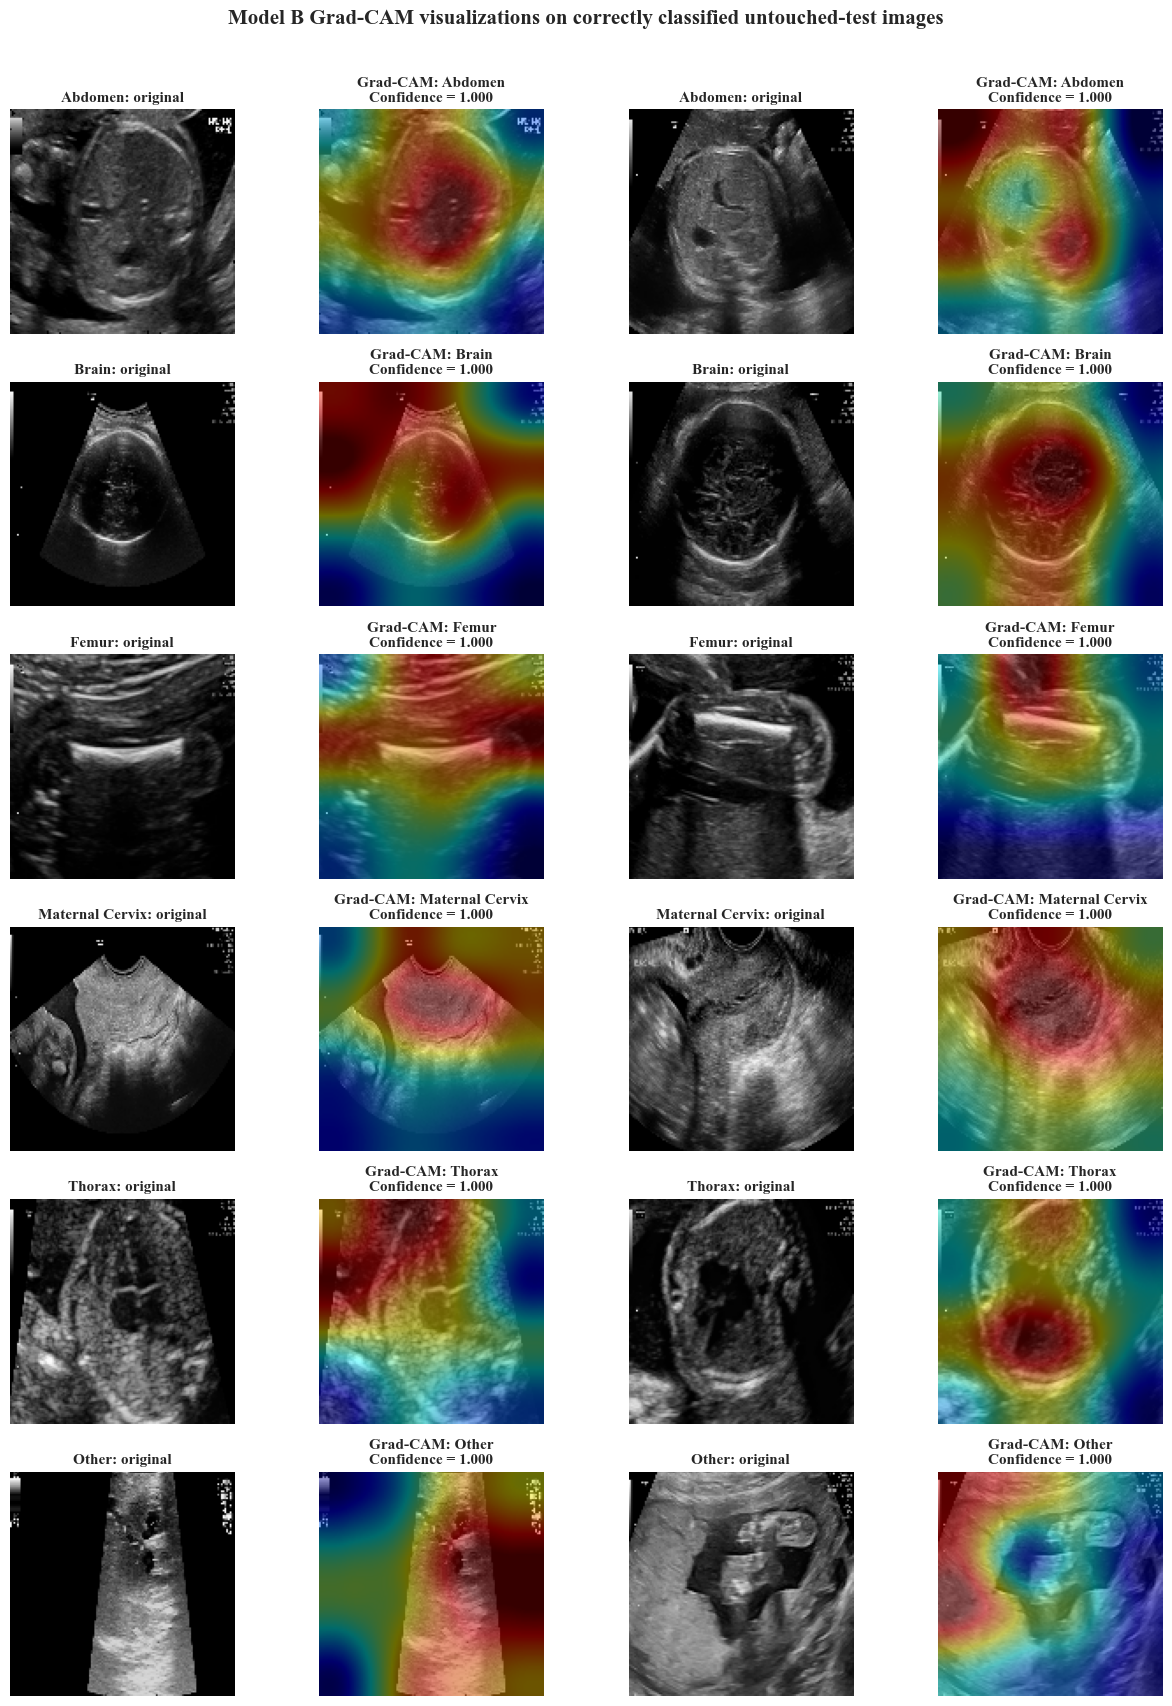


t-SNE feature layer:
Name: model_B_bn
Output: (None, 256)
71/71 [==============================] - 3s 28ms/step

Extracted feature shape: (1135, 256)
PCA retained variance: 92.80%
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1135 samples in 0.000s...
[t-SNE] Computed neighbors for 1135 samples in 0.127s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1135
[t-SNE] Computed conditional probabilities for sample 1135 / 1135
[t-SNE] Mean sigma: 3.864546
[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.952991
[t-SNE] KL divergence after 1500 iterations: 0.697630
t-SNE silhouette score: 0.364315


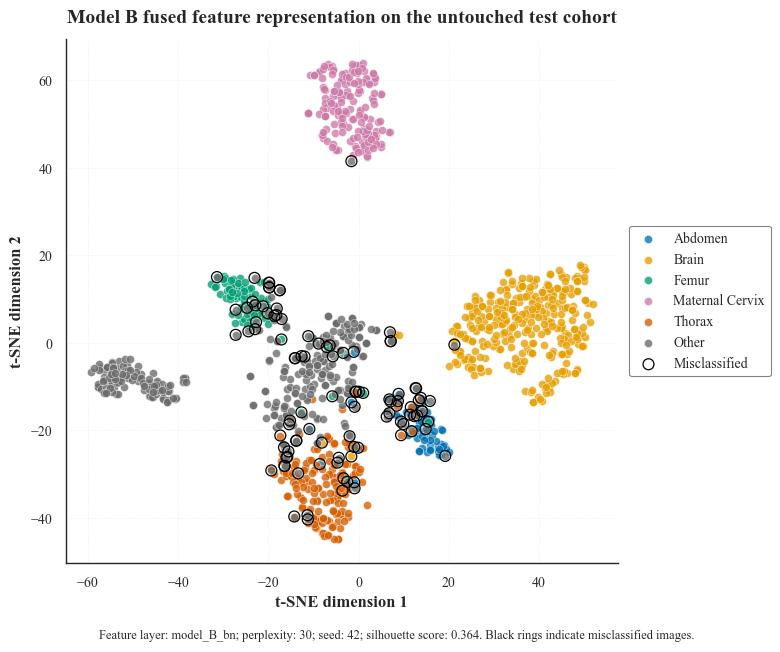


MODEL B GRAD-CAM AND t-SNE COMPLETED

Grad-CAM layer:
fusion_projection

Grad-CAM PDF:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B\Model_B_GradCAM_Test_Examples.pdf

Grad-CAM PNG:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B\Model_B_GradCAM_Test_Examples.png

t-SNE feature layer:
model_B_bn

t-SNE PDF:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B\Model_B_tSNE_Untouched_Test.pdf

t-SNE PNG:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B\Model_B_tSNE_Untouched_Test.png

t-SNE coordinates:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_figures\Model_B\Model_B_tSNE_Test_Coordinates.csv

Selected Grad-CAM records:
D:\imagecondition revision\MobileNetV1_ABCD_PatientLevel_10Fold_6Class_Results\publication_

In [41]:
# =====================================================================
# MODEL B — GRAD-CAM AND t-SNE ON UNTOUCHED TEST DATA
# =====================================================================

from pathlib import Path
import inspect

import cv2
import numpy as np
import pandas as pd
import tensorflow as tf

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    silhouette_score
)

# ---------------------------------------------------------------------
# 1. CONFIGURATION
# ---------------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

VISUAL_OUTPUT_DIR = (
    RESULTS_DIR /
    "publication_figures" /
    "Model_B"
)

VISUAL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CLASS_COLORS = {
    "Abdomen": "#0072B2",
    "Brain": "#E69F00",
    "Femur": "#009E73",
    "Maternal Cervix": "#CC79A7",
    "Thorax": "#D55E00",
    "Other": "#6A6A6A"
}

# Final fused convolutional layer of Model B
GRADCAM_LAYER_NAME = "fusion_projection"

# Final deterministic 256-dimensional representation
TSNE_LAYER_NAME = "model_B_bn"

TSNE_PERPLEXITY = 30
TSNE_ITERATIONS = 1500
PCA_COMPONENTS = 50

# Number of correctly classified Grad-CAM examples per class
GRADCAM_IMAGES_PER_CLASS = 2


# ---------------------------------------------------------------------
# 2. VERIFY THE LOADED MODEL
# ---------------------------------------------------------------------

if "MODEL_B" not in globals():
    raise NameError(
        "MODEL_B is not defined. Load the final Keras Model B first."
    )

if not isinstance(MODEL_B, tf.keras.Model):
    raise TypeError(
        "MODEL_B must be a tf.keras.Model. Do not use the object "
        "returned by tf.saved_model.load()."
    )

if "test_df" not in globals():
    raise NameError(
        "test_df is not defined. Execute Part 1 first."
    )

if "make_dataset" not in globals():
    raise NameError(
        "make_dataset() is not defined. Execute Part 1 first."
    )

evaluation_df = (
    test_df
    .reset_index(drop=True)
    .copy()
)

print("Model inputs:", MODEL_B.input_shape)
print("Model output:", MODEL_B.output_shape)
print("Test images:", len(evaluation_df))
print(
    "Test patients:",
    evaluation_df["patient_id"].nunique()
)

if len(evaluation_df) != 1135:
    print(
        "\nWarning: this test manifest contains "
        f"{len(evaluation_df):,} images rather than 1,135."
    )


# ---------------------------------------------------------------------
# 3. CREATE NON-SHUFFLED TEST DATASET
# ---------------------------------------------------------------------

test_dataset = make_dataset(
    evaluation_df,
    training=False,
    batch_size=BATCH_SIZE
)


# ---------------------------------------------------------------------
# 4. GENERATE AND VERIFY MODEL B PREDICTIONS
# ---------------------------------------------------------------------

probabilities = MODEL_B.predict(
    test_dataset,
    verbose=1
)

probabilities = np.asarray(
    probabilities
)

if probabilities.shape != (
    len(evaluation_df),
    len(class_names)
):
    raise ValueError(
        "Unexpected prediction shape.\n"
        f"Expected: {(len(evaluation_df), len(class_names))}\n"
        f"Detected: {probabilities.shape}"
    )

true_labels = (
    evaluation_df["label"]
    .to_numpy(dtype=np.int32)
)

predicted_labels = np.argmax(
    probabilities,
    axis=1
)

confidence = np.max(
    probabilities,
    axis=1
)

correct = (
    true_labels == predicted_labels
)

accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

macro_precision = precision_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

print("\n" + "=" * 75)
print("LOADED MODEL B — TEST VERIFICATION")
print("=" * 75)

print(f"Accuracy        : {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Macro precision : {macro_precision:.6f} ({macro_precision*100:.2f}%)")
print(f"Macro recall    : {macro_recall:.6f} ({macro_recall*100:.2f}%)")
print(f"Macro F1-score  : {macro_f1:.6f} ({macro_f1*100:.2f}%)")

evaluation_df["predicted_index"] = (
    predicted_labels
)

evaluation_df["predicted_class"] = [
    class_names[index]
    for index in predicted_labels
]

evaluation_df["confidence"] = confidence
evaluation_df["correct"] = correct


# =====================================================================
# PART A — GRAD-CAM
# =====================================================================

# ---------------------------------------------------------------------
# 5. IDENTIFY THE GRAD-CAM TARGET LAYER
# ---------------------------------------------------------------------

try:
    gradcam_layer = MODEL_B.get_layer(
        GRADCAM_LAYER_NAME
    )
except ValueError as error:

    available_conv_layers = [
        layer.name
        for layer in MODEL_B.layers
        if isinstance(
            layer,
            (
                tf.keras.layers.Conv2D,
                tf.keras.layers.DepthwiseConv2D
            )
        )
    ]

    raise ValueError(
        f"Grad-CAM layer '{GRADCAM_LAYER_NAME}' was not found.\n"
        f"Available convolutional layers:\n"
        f"{available_conv_layers}"
    ) from error

print("\nGrad-CAM target layer:")
print("Name:", gradcam_layer.name)
print("Output:", gradcam_layer.output.shape)

gradcam_model = tf.keras.Model(
    inputs=MODEL_B.inputs,
    outputs=[
        gradcam_layer.output,
        MODEL_B.output
    ],
    name="Model_B_GradCAM_Extractor"
)


# ---------------------------------------------------------------------
# 6. LOAD ONE IMAGE USING THE SAME TEST PREPROCESSING
# ---------------------------------------------------------------------

def prepare_single_test_image(row):

    image_bytes = tf.io.read_file(
        row["path"]
    )

    image = tf.io.decode_image(
        image_bytes,
        channels=1,
        expand_animations=False
    )

    image.set_shape([
        None,
        None,
        1
    ])

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = (
        tf.cast(image, tf.float32)
        / 255.0
    )

    coordinate_tensor = tf.convert_to_tensor(
        coords,
        dtype=tf.float32
    )

    model_inputs = {
        "image_input": image[None, ...],
        "coord_input": coordinate_tensor[None, ...]
    }

    return image, model_inputs


# ---------------------------------------------------------------------
# 7. COMPUTE GRAD-CAM
# ---------------------------------------------------------------------

def calculate_gradcam(
    model_inputs,
    class_index
):

    with tf.GradientTape() as tape:

        convolution_output, model_output = (
            gradcam_model(
                model_inputs,
                training=False
            )
        )

        class_score = model_output[
            :,
            class_index
        ]

    gradients = tape.gradient(
        class_score,
        convolution_output
    )

    if gradients is None:
        raise RuntimeError(
            "Gradients could not be calculated for layer "
            f"'{GRADCAM_LAYER_NAME}'."
        )

    channel_weights = tf.reduce_mean(
        gradients,
        axis=(1, 2)
    )

    heatmap = tf.reduce_sum(
        convolution_output
        * channel_weights[:, None, None, :],
        axis=-1
    )

    heatmap = tf.nn.relu(
        heatmap
    )

    heatmap = heatmap[0]

    maximum = tf.reduce_max(
        heatmap
    )

    if float(maximum) > 0:
        heatmap = heatmap / maximum

    heatmap = heatmap.numpy()

    heatmap = cv2.resize(
        heatmap,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_CUBIC
    )

    return np.clip(
        heatmap,
        0.0,
        1.0
    )


# ---------------------------------------------------------------------
# 8. CREATE COLOURED OVERLAY
# ---------------------------------------------------------------------

def create_overlay(
    grayscale_image,
    heatmap,
    alpha=0.42
):

    grayscale_image = np.asarray(
        grayscale_image
    ).squeeze()

    grayscale_uint8 = np.uint8(
        np.clip(
            grayscale_image * 255.0,
            0,
            255
        )
    )

    grayscale_rgb = cv2.cvtColor(
        grayscale_uint8,
        cv2.COLOR_GRAY2RGB
    )

    coloured_heatmap = cv2.applyColorMap(
        np.uint8(255 * heatmap),
        cv2.COLORMAP_JET
    )

    coloured_heatmap = cv2.cvtColor(
        coloured_heatmap,
        cv2.COLOR_BGR2RGB
    )

    overlay = cv2.addWeighted(
        grayscale_rgb,
        1.0 - alpha,
        coloured_heatmap,
        alpha,
        0
    )

    return grayscale_rgb, overlay


# ---------------------------------------------------------------------
# 9. SELECT REPRESENTATIVE CORRECT TEST IMAGES
# ---------------------------------------------------------------------

selected_rows = []

for class_index, class_name in enumerate(
    class_names
):

    class_candidates = evaluation_df[
        (evaluation_df["label"] == class_index)
        & evaluation_df["correct"]
    ].copy()

    if class_candidates.empty:
        print(
            f"Warning: no correctly classified image "
            f"was found for {class_name}."
        )
        continue

    # Select the most confident correct examples
    class_candidates = class_candidates.sort_values(
        "confidence",
        ascending=False
    )

    selected_rows.append(
        class_candidates.head(
            GRADCAM_IMAGES_PER_CLASS
        )
    )

selected_gradcam_df = pd.concat(
    selected_rows,
    ignore_index=True
)

selected_gradcam_df.to_csv(
    VISUAL_OUTPUT_DIR /
    "Model_B_GradCAM_Selected_Images.csv",
    index=False
)

print(
    "\nSelected Grad-CAM images:",
    len(selected_gradcam_df)
)


# ---------------------------------------------------------------------
# 10. GENERATE GRAD-CAM COMPOSITE
# ---------------------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],
    "font.size": 10,
    "axes.titlesize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

number_of_classes_selected = (
    selected_gradcam_df["class_name"]
    .nunique()
)

fig, axes = plt.subplots(
    number_of_classes_selected,
    GRADCAM_IMAGES_PER_CLASS * 2,
    figsize=(
        3.2 * GRADCAM_IMAGES_PER_CLASS * 2,
        2.85 * number_of_classes_selected
    ),
    squeeze=False
)

plot_row = 0

for class_index, class_name in enumerate(
    class_names
):

    class_rows = selected_gradcam_df[
        selected_gradcam_df["class_name"]
        == class_name
    ]

    if class_rows.empty:
        continue

    for example_index, (_, row) in enumerate(
        class_rows.iterrows()
    ):

        image_tensor, model_inputs = (
            prepare_single_test_image(row)
        )

        heatmap = calculate_gradcam(
            model_inputs=model_inputs,
            class_index=int(
                row["predicted_index"]
            )
        )

        original_rgb, overlay = create_overlay(
            image_tensor.numpy(),
            heatmap
        )

        original_axis = axes[
            plot_row,
            example_index * 2
        ]

        overlay_axis = axes[
            plot_row,
            example_index * 2 + 1
        ]

        original_axis.imshow(
            original_rgb,
            cmap="gray"
        )

        original_axis.set_title(
            f"{class_name}: original",
            fontweight="bold"
        )

        overlay_axis.imshow(
            overlay
        )

        overlay_axis.set_title(
            (
                f"Grad-CAM: "
                f"{row['predicted_class']}\n"
                f"Confidence = "
                f"{row['confidence']:.3f}"
            ),
            fontweight="bold"
        )

        original_axis.axis("off")
        overlay_axis.axis("off")

    # Hide unused axes if fewer images were available
    for unused_index in range(
        len(class_rows),
        GRADCAM_IMAGES_PER_CLASS
    ):
        axes[
            plot_row,
            unused_index * 2
        ].axis("off")

        axes[
            plot_row,
            unused_index * 2 + 1
        ].axis("off")

    plot_row += 1

fig.suptitle(
    (
        "Model B Grad-CAM visualizations on correctly "
        "classified untouched-test images"
    ),
    fontsize=15,
    fontweight="bold",
    y=0.995
)

fig.tight_layout(
    rect=[0, 0, 1, 0.985]
)

GRADCAM_PDF = (
    VISUAL_OUTPUT_DIR /
    "Model_B_GradCAM_Test_Examples.pdf"
)

GRADCAM_PNG = (
    VISUAL_OUTPUT_DIR /
    "Model_B_GradCAM_Test_Examples.png"
)

fig.savefig(
    GRADCAM_PDF,
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    GRADCAM_PNG,
    format="png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)


# =====================================================================
# PART B — t-SNE
# =====================================================================

# ---------------------------------------------------------------------
# 11. BUILD FEATURE EXTRACTOR
# ---------------------------------------------------------------------

try:
    tsne_layer = MODEL_B.get_layer(
        TSNE_LAYER_NAME
    )
except ValueError as error:
    raise ValueError(
        f"t-SNE layer '{TSNE_LAYER_NAME}' was not found."
    ) from error

print("\nt-SNE feature layer:")
print("Name:", tsne_layer.name)
print("Output:", tsne_layer.output.shape)

feature_extractor = tf.keras.Model(
    inputs=MODEL_B.inputs,
    outputs=tsne_layer.output,
    name="Model_B_tSNE_Feature_Extractor"
)


# ---------------------------------------------------------------------
# 12. EXTRACT TEST FEATURES
# ---------------------------------------------------------------------

features = feature_extractor.predict(
    test_dataset,
    verbose=1
)

features = np.asarray(
    features
)

features = features.reshape(
    features.shape[0],
    -1
)

if len(features) != len(evaluation_df):
    raise ValueError(
        "Feature count does not match the test-manifest count."
    )

print("\nExtracted feature shape:", features.shape)


# ---------------------------------------------------------------------
# 13. APPLY PCA BEFORE t-SNE
# ---------------------------------------------------------------------

number_of_components = min(
    PCA_COMPONENTS,
    features.shape[1],
    features.shape[0] - 1
)

pca = PCA(
    n_components=number_of_components,
    random_state=SEED
)

pca_features = pca.fit_transform(
    features
)

retained_variance = (
    pca.explained_variance_ratio_.sum()
)

print(
    "PCA retained variance:",
    f"{retained_variance * 100:.2f}%"
)


# ---------------------------------------------------------------------
# 14. CALCULATE t-SNE
# ---------------------------------------------------------------------

common_tsne_arguments = {
    "n_components": 2,
    "perplexity": TSNE_PERPLEXITY,
    "learning_rate": "auto",
    "init": "pca",
    "random_state": SEED,
    "verbose": 1
}

# Compatibility with different scikit-learn versions
if "max_iter" in inspect.signature(TSNE).parameters:
    tsne_model = TSNE(
        **common_tsne_arguments,
        max_iter=TSNE_ITERATIONS
    )
else:
    tsne_model = TSNE(
        **common_tsne_arguments,
        n_iter=TSNE_ITERATIONS
    )

tsne_coordinates = tsne_model.fit_transform(
    pca_features
)

tsne_silhouette = silhouette_score(
    tsne_coordinates,
    true_labels
)

print(
    "t-SNE silhouette score:",
    f"{tsne_silhouette:.6f}"
)


# ---------------------------------------------------------------------
# 15. SAVE t-SNE COORDINATES
# ---------------------------------------------------------------------

tsne_table = evaluation_df[
    [
        "path",
        "patient_id",
        "label",
        "class_name",
        "predicted_index",
        "predicted_class",
        "confidence",
        "correct"
    ]
].copy()

tsne_table["tsne_dimension_1"] = (
    tsne_coordinates[:, 0]
)

tsne_table["tsne_dimension_2"] = (
    tsne_coordinates[:, 1]
)

TSNE_CSV = (
    VISUAL_OUTPUT_DIR /
    "Model_B_tSNE_Test_Coordinates.csv"
)

tsne_table.to_csv(
    TSNE_CSV,
    index=False
)


# ---------------------------------------------------------------------
# 16. CREATE PUBLICATION-QUALITY t-SNE PLOT
# ---------------------------------------------------------------------

fig, axis = plt.subplots(
    figsize=(8.5, 6.8)
)

for class_index, class_name in enumerate(
    class_names
):

    class_mask = (
        true_labels == class_index
    )

    axis.scatter(
        tsne_coordinates[class_mask, 0],
        tsne_coordinates[class_mask, 1],
        s=34,
        color=CLASS_COLORS[class_name],
        label=class_name,
        alpha=0.78,
        edgecolors="white",
        linewidths=0.35
    )

# Indicate incorrectly classified images with black rings
incorrect_mask = ~correct

axis.scatter(
    tsne_coordinates[incorrect_mask, 0],
    tsne_coordinates[incorrect_mask, 1],
    s=62,
    facecolors="none",
    edgecolors="black",
    linewidths=0.9,
    marker="o",
    label="Misclassified"
)

axis.set_xlabel(
    "t-SNE dimension 1",
    fontsize=12,
    fontweight="bold"
)

axis.set_ylabel(
    "t-SNE dimension 2",
    fontsize=12,
    fontweight="bold"
)

axis.set_title(
    (
        "Model B fused feature representation on the "
        "untouched test cohort"
    ),
    fontsize=14,
    fontweight="bold",
    pad=12
)

axis.grid(
    True,
    linestyle=":",
    linewidth=0.6,
    alpha=0.35
)

axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)

legend = axis.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    borderaxespad=0
)

legend.get_frame().set_edgecolor(
    "#666666"
)

legend.get_frame().set_linewidth(
    0.8
)

fig.text(
    0.5,
    0.018,
    (
        f"Feature layer: {TSNE_LAYER_NAME}; "
        f"perplexity: {TSNE_PERPLEXITY}; "
        f"seed: {SEED}; "
        f"silhouette score: {tsne_silhouette:.3f}. "
        "Black rings indicate misclassified images."
    ),
    ha="center",
    fontsize=9
)

fig.subplots_adjust(
    left=0.11,
    right=0.76,
    bottom=0.13,
    top=0.90
)

TSNE_PDF = (
    VISUAL_OUTPUT_DIR /
    "Model_B_tSNE_Untouched_Test.pdf"
)

TSNE_PNG = (
    VISUAL_OUTPUT_DIR /
    "Model_B_tSNE_Untouched_Test.png"
)

fig.savefig(
    TSNE_PDF,
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    TSNE_PNG,
    format="png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)


# ---------------------------------------------------------------------
# 17. FINAL OUTPUT SUMMARY
# ---------------------------------------------------------------------

print("\n" + "=" * 90)
print("MODEL B GRAD-CAM AND t-SNE COMPLETED")
print("=" * 90)

print("\nGrad-CAM layer:")
print(GRADCAM_LAYER_NAME)

print("\nGrad-CAM PDF:")
print(GRADCAM_PDF)

print("\nGrad-CAM PNG:")
print(GRADCAM_PNG)

print("\nt-SNE feature layer:")
print(TSNE_LAYER_NAME)

print("\nt-SNE PDF:")
print(TSNE_PDF)

print("\nt-SNE PNG:")
print(TSNE_PNG)

print("\nt-SNE coordinates:")
print(TSNE_CSV)

print("\nSelected Grad-CAM records:")
print(
    VISUAL_OUTPUT_DIR /
    "Model_B_GradCAM_Selected_Images.csv"
)